# Analiza wyników - wykresy do rozdziału 3

In [8]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


RESULTS_DIR = Path('../results')
SEEDS = [29, 81]

AGG_DIR = RESULTS_DIR / f'aggregation_seeds_{"_".join(map(str, SEEDS))}'
FIG_DIR = AGG_DIR / 'notebook_figs' / 'new_2seeds'
FIG_DIR.mkdir(parents=True, exist_ok=True)


DATASETS = ['CICIDS', 'UNSW_NB15']

DATASET_LABELS = {
    'CICIDS': 'CICIDS2017',
    'UNSW_NB15': 'UNSW-NB15',
}

DATASET_SUFFIX = {
    'CICIDS': 'cicids',
    'UNSW_NB15': 'unsw',
}

COLORS = list(plt.cm.Set2.colors)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': False,
    'font.size': 10,
    'savefig.dpi': 300,
    'legend.frameon': False,
})


RUN_NAME_TO_INDEX = {
    '1st': 1,
    '2nd': 2,
    '3rd': 3,
}


def extract_run_index_from_filename(filename):
    match = re.match(
        r'^(1st|2nd|3rd)_run_',
        Path(filename).name,
        flags=re.IGNORECASE,
    )

    if match is None:
        return pd.NA

    return RUN_NAME_TO_INDEX[match.group(1).lower()]


def flatten_confusion_matrix(record):
    matrix = record.get('ConfusionMatrix')

    if (
        isinstance(matrix, list)
        and len(matrix) == 2
        and all(
            isinstance(row, list) and len(row) == 2
            for row in matrix
        )
    ):
        record['ConfusionMatrix_TN'] = matrix[0][0]
        record['ConfusionMatrix_FP'] = matrix[0][1]
        record['ConfusionMatrix_FN'] = matrix[1][0]
        record['ConfusionMatrix_TP'] = matrix[1][1]

    return record


def load_raw_json_results(results_dir, seeds):
    rows = []

    for seed in seeds:
        seed_dir = Path(results_dir) / f'seed_{seed}'

        if not seed_dir.exists():
            print(f'UWAGA: nie znaleziono katalogu: {seed_dir}')
            continue

        json_files = sorted(seed_dir.rglob('*.json'))

        for json_path in json_files:
            relative_parts = json_path.relative_to(seed_dir).parts

            if 'aggregation' in relative_parts:
                continue

            run_index = extract_run_index_from_filename(
                json_path.name
            )

            if pd.isna(run_index):
                continue

            try:
                with open(
                    json_path,
                    'r',
                    encoding='utf-8',
                ) as file:
                    record = json.load(file)

            except (
                json.JSONDecodeError,
                UnicodeDecodeError,
            ) as exc:
                print(
                    f'UWAGA: pominięto {json_path.name}: {exc}'
                )
                continue

            if not isinstance(record, dict):
                print(
                    f'UWAGA: plik {json_path.name} '
                    f'nie zawiera obiektu JSON'
                )
                continue

            record = flatten_confusion_matrix(
                record.copy()
            )

            record['seed'] = int(
                record.get('seed', seed)
            )

            record['run_index'] = int(run_index)
            record['source_file'] = json_path.name
            record['source_path'] = str(json_path)
            record['threshold_variant'] = 'standard'

            rows.append(record)

    if not rows:
        raise RuntimeError(
            'Nie znaleziono żadnych surowych plików JSON '
            'dla wskazanych seedów.'
        )

    raw_df = pd.json_normalize(rows)

    raw_df['seed'] = pd.to_numeric(
        raw_df['seed'],
        errors='coerce',
    ).astype('Int64')

    raw_df['run_index'] = pd.to_numeric(
        raw_df['run_index'],
        errors='coerce',
    ).astype('Int64')

    numeric_metrics = [
        'AUC_ROC',
        'AUC_PR',
        'Precision',
        'Recall',
        'F1',
        'Recall_at_FPR_0.01',
        'Precision_at_Recall_0.80',
        'runtime_train',
        'runtime_inference',
        'ConfusionMatrix_TN',
        'ConfusionMatrix_FP',
        'ConfusionMatrix_FN',
        'ConfusionMatrix_TP',
    ]

    for metric in numeric_metrics:
        if metric in raw_df.columns:
            raw_df[metric] = pd.to_numeric(
                raw_df[metric],
                errors='coerce',
            )

    return raw_df


df = load_raw_json_results(RESULTS_DIR, SEEDS)

print(
    f'Wczytano {len(df)} surowych rekordów JSON '
    f'z seedów: {sorted(df["seed"].dropna().unique())}'
)

print('\nLiczba rekordów według seeda:')
print(df['seed'].value_counts().sort_index())

print('\nLiczba rekordów według run_index:')
print(df['run_index'].value_counts().sort_index())

print('\nKontrola liczby rekordów seed × run_index:')
display(
    pd.crosstab(
        df['run_index'],
        df['seed'],
        margins=True,
    )
)


df_std = df.copy()


def no_perturbation_mask(frame):
    mask = pd.Series(
        True,
        index=frame.index,
    )

    for col in [
        'hyperparameters.feature_dropout',
        'hyperparameters.imbalance_factor_test',
        'hyperparameters.noise',
    ]:
        if col in frame.columns:
            mask &= (
                frame[col].isna()
                | frame[col].eq(0)
            )

    return mask


df_std_clean = df_std[
    no_perturbation_mask(df_std)
].copy()


def norm(value):
    return re.sub(
        r'[^a-z0-9]+',
        '',
        str(value).lower(),
    )


def select(frame, dataset=None, model=None, fusion=None):
    out = frame.copy()

    if dataset is not None:
        out = out[
            out['dataset_name'].eq(dataset)
        ]

    if model is not None:
        out = out[
            out['model_type']
            .map(norm)
            .eq(norm(model))
        ]

    if fusion is not None:
        if 'fusion_strategy' not in out.columns:
            return out.iloc[0:0]

        out = out[
            out['fusion_strategy']
            .fillna('')
            .map(norm)
            .eq(norm(fusion))
        ]

    return out


def agg(
    frame,
    mask,
    metrics=(
        'AUC_ROC',
        'AUC_PR',
        'Precision',
        'Recall',
        'F1',
        'runtime_train',
        'runtime_inference',
        'ConfusionMatrix_TP',
        'ConfusionMatrix_FP',
        'ConfusionMatrix_TN',
        'ConfusionMatrix_FN',
    ),
):

    sub = frame.loc[mask]

    out = {
        'n': len(sub),
    }

    for metric in metrics:
        if metric in sub.columns:
            out[f'{metric}_mean'] = sub[metric].mean()
            out[f'{metric}_std'] = sub[metric].std()

    return out


def stats_for(frame):
    metrics = [
        'AUC_ROC',
        'AUC_PR',
        'Precision',
        'Recall',
        'F1',
        'runtime_train',
        'runtime_inference',
        'ConfusionMatrix_FP',
        'ConfusionMatrix_FN',
    ]

    return {
        metric: (
            frame[metric].mean(),
            frame[metric].std(),
        )
        if metric in frame.columns
        else (np.nan, np.nan)
        for metric in metrics
    }


def pm(mean, std, nd=3):
    if pd.isna(mean):
        return '--'

    if pd.isna(std):
        return f'{mean:.{nd}f}'

    return f'{mean:.{nd}f} ± {std:.{nd}f}'


def pm_n(mean, std, n, nd=3):
    if pd.isna(mean):
        return '--'

    if pd.isna(std) or n <= 1:
        return f'{mean:.{nd}f}'

    return f'{mean:.{nd}f} ± {std:.{nd}f}'


def stats_for_by(
    frame,
    groupby_col,
    fixed_col=None,
    fixed_val=None,
):

    sub = frame.copy()

    if fixed_col is not None:
        sub = sub[
            sub[fixed_col].eq(fixed_val)
        ]

    report_metrics = [
        'AUC_ROC',
        'AUC_PR',
        'Precision',
        'Recall',
        'F1',
        'runtime_train',
        'runtime_inference',
    ]

    if groupby_col not in sub.columns:
        return {
            metric: (np.nan, np.nan, 0)
            for metric in report_metrics
        }

    per_group = sub.groupby(
        groupby_col,
        dropna=False,
    )

    out = {}

    for metric in report_metrics:
        if metric not in sub.columns:
            out[metric] = (
                np.nan,
                np.nan,
                0,
            )
            continue

        per_group_means = per_group[metric].mean()

        out[metric] = (
            per_group_means.mean(),
            per_group_means.std(),
            len(per_group_means),
        )

    return out


RUN_METRICS = [
    'AUC_ROC',
    'AUC_PR',
    'Precision',
    'Recall',
    'F1',
    'Recall_at_FPR_0.01',
    'Precision_at_Recall_0.80',
    'runtime_train',
    'runtime_inference',
    'ConfusionMatrix_FP',
    'ConfusionMatrix_FN',
]


def seed_stats_for_run(frame, metrics=RUN_METRICS):
    out = {
        'n_seedów': frame['seed'].nunique(),
    }

    if frame.empty or 'seed' not in frame.columns:
        for metric in metrics:
            out[f'{metric}_mean'] = np.nan
            out[f'{metric}_std'] = np.nan

        return out

    for metric in metrics:
        if metric not in frame.columns:
            out[f'{metric}_mean'] = np.nan
            out[f'{metric}_std'] = np.nan
            continue

        seed_means = (
            frame
            .groupby('seed')[metric]
            .mean()
            .dropna()
        )

        out[f'{metric}_mean'] = seed_means.mean()
        out[f'{metric}_std'] = seed_means.std(ddof=1)

    return out


def run_index_seed_summary(
    frame,
    dataset=None,
    model=None,
    fusion=None,
    metrics=RUN_METRICS,
):
    
    sub = select(
        frame,
        dataset=dataset,
        model=model,
        fusion=fusion,
    ).copy()

    if sub.empty:
        return pd.DataFrame()

    if 'run_index' not in sub.columns:
        raise KeyError(
            'Brak kolumny run_index. '
            'Dane muszą pochodzić z load_raw_json_results().'
        )

    sub = sub[
        sub['run_index'].notna()
    ].copy()

    rows = []

    for run_idx, group in sub.groupby(
        'run_index',
        sort=True,
    ):
        stats = seed_stats_for_run(
            group,
            metrics=metrics,
        )

        row = {
            'Run': int(run_idx),
        }

        for metric in metrics:
            decimals = (
                1
                if metric in {
                    'runtime_train',
                    'runtime_inference',
                    'ConfusionMatrix_FP',
                    'ConfusionMatrix_FN',
                }
                else 3
            )

            row[metric] = pm_n(
                stats[f'{metric}_mean'],
                stats[f'{metric}_std'],
                stats['n_seedów'],
                nd=decimals,
            )

        rows.append(row)

    return pd.DataFrame(rows)


def savefig(fig, name):
    pdf_path = FIG_DIR / f'{name}.pdf'
    png_path = FIG_DIR / f'{name}.png'

    fig.savefig(
        pdf_path,
        bbox_inches='tight',
    )

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches='tight',
    )

    print(
        f'Zapisano: {pdf_path.name} oraz {png_path.name}'
    )


def to_latex_math(cell):
    s = str(cell)

    if s.strip() in ('--', 'nan', ''):
        return '--'

    s = re.sub(
        r'(\d+)\.(\d+)',
        lambda match: (
            match.group(1)
            + '{,}'
            + match.group(2)
        ),
        s,
    )

    s = s.replace('±', r'\pm')

    return f'${s}$'


def export_table(rows, name, caption=None, label=None):
    table = pd.DataFrame(rows)

    display(table)

    table.to_csv(
        FIG_DIR / f'{name}.csv',
        index=False,
    )

    cols = list(table.columns)

    id_cols = [
        col
        for col in cols
        if col in (
            'Zbiór',
            'Model',
            'Wariant',
            'Liczba epok',
            'Run',
        )
    ]

    metric_cols = [
        col
        for col in cols
        if col not in id_cols
    ]

    align = (
        'l' * len(id_cols)
        + 'c' * len(metric_cols)
    )

    cap = (
        caption
        or name.replace(
            '_',
            ' ',
        ).replace(
            '-',
            ' ',
        ).capitalize()
    )

    lab = label or f'tab:{name}'

    lines = [
        r'\begin{table}[H]',
        r'\centering',
        rf'\caption{{{cap}}}',
        rf'\label{{{lab}}}',
        r'\resizebox{\textwidth}{!}{%',
        rf'\begin{{tabular}}{{{align}}}',
        r'\hline',
        ' & '.join(cols) + r' \\',
        r'\hline',
    ]

    group_col = (
        'Zbiór'
        if 'Zbiór' in cols
        else None
    )

    previous_group = None

    for _, row in table.iterrows():
        if (
            group_col is not None
            and previous_group is not None
            and row[group_col] != previous_group
        ):
            lines.append(r'\hline')

        cells = [
            str(row[col])
            if col in id_cols
            else to_latex_math(row[col])
            for col in cols
        ]

        lines.append(
            ' & '.join(cells) + r' \\'
        )

        if group_col is not None:
            previous_group = row[group_col]

    lines += [
        r'\hline',
        r'\end{tabular}}',
        r'\end{table}',
        '',
        r'Źródło: opracowanie własne.',
    ]

    tex = '\n'.join(lines)

    (FIG_DIR / f'{name}.tex').write_text(
        tex,
        encoding='utf-8',
    )

    print(tex)

    return table


def bar_by_dataset(
    specs,
    metric,
    stem,
    ylabel,
    title,
    source=None,
    yscale='linear',
):

    if source is None:
        source = df_std_clean

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(8, 7.5),
    )

    for ax, ds in zip(axes, DATASETS):
        means = []
        stds = []
        labels = []

        for model, fusion, label in specs:
            sub = select(
                source,
                dataset=ds,
                model=model,
                fusion=fusion,
            )

            means.append(
                sub[metric].mean()
                if metric in sub.columns
                and not sub.empty
                else np.nan
            )

            stds.append(
                sub[metric].std()
                if metric in sub.columns
                and not sub.empty
                else np.nan
            )

            labels.append(label)

        x = np.arange(len(labels))

        rects = ax.bar(
            x,
            means,
            yerr=stds,
            capsize=5,
            color=COLORS[:len(labels)],
            ecolor='#404040',
            alpha=0.9,
            error_kw={
                'elinewidth': 1.2,
                'capthick': 1.2,
            },
        )

        for rect, mean, std in zip(
            rects,
            means,
            stds,
        ):
            if pd.notna(mean):
                offset = (
                    (
                        std
                        if pd.notna(std)
                        else 0
                    )
                    + (
                        mean * 0.03
                        if yscale == 'log'
                        else 0.02
                    )
                )

                ax.text(
                    rect.get_x()
                    + rect.get_width() / 2.0,
                    mean + offset,
                    (
                        f'{mean:.3f}'
                        if yscale == 'linear'
                        else f'{mean:.1f}'
                    ),
                    ha='center',
                    va='bottom',
                    fontsize=9,
                )

        ax.set_xticks(x)

        ax.set_xticklabels(
            labels,
            rotation=0,
            fontsize=10,
        )

        ax.set_ylabel(
            ylabel,
            fontsize=10,
            labelpad=8,
        )

        ax.set_title(
            DATASET_LABELS[ds],
            fontsize=11,
            pad=10,
        )

        if yscale == 'log':
            ax.set_yscale('log')

        else:
            max_val = max(
                [
                    mean + (
                        std
                        if pd.notna(std)
                        else 0
                    )
                    for mean, std in zip(
                        means,
                        stds,
                    )
                    if pd.notna(mean)
                ],
                default=1,
            )

            ax.set_ylim(0, max_val * 1.15)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)

        ax.yaxis.grid(
            True,
            which='both',
            linestyle='--',
            alpha=0.5,
            zorder=0,
        )

        ax.set_axisbelow(True)

    fig.suptitle(
        title,
        fontsize=12,
        y=0.99,
    )

    fig.tight_layout(h_pad=3.0)

    savefig(fig, stem)

    plt.show()


def bar_per_dataset(
    specs,
    metric,
    stem,
    ylabel,
    title,
    source=None,
    run_indices=(1, 2, 3),
):
    
    if source is None:
        source = df_std_clean

    required_columns = {
        'dataset_name',
        'model_type',
        'fusion_strategy',
        'seed',
        'run_index',
        metric,
    }

    missing_columns = (
        required_columns
        - set(source.columns)
    )

    if missing_columns:
        raise KeyError(
            'Brakuje wymaganych kolumn: '
            + ', '.join(
                sorted(missing_columns)
            )
        )

    run_indices = list(run_indices)
    n_runs = len(run_indices)

    bar_width = 0.22

    offsets = (
        np.arange(n_runs)
        - (n_runs - 1) / 2
    ) * bar_width

    run_colors = COLORS[:n_runs]

    for ds in DATASETS:
        labels = [
            label
            for _, _, label in specs
        ]

        x = np.arange(len(labels))

        fig, ax = plt.subplots(
            figsize=(9.2, 5.0),
        )

        all_tops = []

        for run_position, run_index in enumerate(
            run_indices
        ):
            means = []
            stds = []

            for model, fusion, _ in specs:
                sub = select(
                    source,
                    dataset=ds,
                    model=model,
                    fusion=fusion,
                ).copy()

                sub = sub[
                    sub['run_index'].eq(run_index)
                ].copy()

                if sub.empty:
                    means.append(np.nan)
                    stds.append(np.nan)
                    continue

                per_seed = (
                    sub
                    .groupby('seed')[metric]
                    .mean()
                    .dropna()
                )

                means.append(per_seed.mean())
                stds.append(per_seed.std(ddof=1))

            stds_plot = [
                0.0
                if pd.isna(std)
                else std
                for std in stds
            ]

            positions = x + offsets[run_position]

            bars = ax.bar(
                positions,
                means,
                width=bar_width,
                yerr=stds_plot,
                capsize=4,
                color=run_colors[run_position],
                ecolor='#404040',
                alpha=0.90,
                edgecolor='none',
                error_kw={
                    'elinewidth': 1.1,
                    'capthick': 1.1,
                },
                label=f'Run {run_index}',
            )

            for bar, mean, std in zip(
                bars,
                means,
                stds,
            ):
                if pd.isna(mean):
                    continue

                std_for_label = (
                    0.0
                    if pd.isna(std)
                    else std
                )

                all_tops.append(
                    mean + std_for_label
                )

                ax.annotate(
                    f'{mean:.3f}',
                    xy=(
                        bar.get_x()
                        + bar.get_width() / 2.0,
                        mean + std_for_label,
                    ),
                    xytext=(0, 4),
                    textcoords='offset points',
                    ha='center',
                    va='bottom',
                    fontsize=8.5,
                )

        max_top = max(all_tops, default=1.0)

        ax.set_xticks(x)

        ax.set_xticklabels(
            labels,
            rotation=0,
            fontsize=10,
        )

        ax.set_ylabel(
            ylabel,
            fontsize=10,
            labelpad=8,
        )

        ax.set_title(
            f'{title} — {DATASET_LABELS[ds]}',
            fontsize=11.5,
            pad=12,
        )

        ax.set_ylim(0, max_top * 1.16)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)

        ax.yaxis.grid(
            True,
            linestyle='--',
            alpha=0.45,
            zorder=0,
        )

        ax.set_axisbelow(True)

        ax.legend(
            loc='upper center',
            ncol=3,
            frameon=False,
            facecolor='white',
            edgecolor='#D0D0D0',
            fontsize=9,
            title_fontsize=9,
        )

        fig.tight_layout()

        output_name = (
            f'{stem}-'
            f'{DATASET_SUFFIX.get(ds, norm(ds))}'
        )

        savefig(fig, output_name)

        plt.show()


def bar_dual_metric_by_dataset(
    specs,
    metrics,
    metric_labels,
    stem,
    ylabel,
    title,
    source=None,
):
    
    if source is None:
        source = df_std_clean

    labels = [
        spec[2]
        for spec in specs
    ]

    width = 0.38
    x = np.arange(len(labels))

    for ds in DATASETS:
        fig, ax = plt.subplots(
            figsize=(7, 4.5),
        )

        dataset_values = []

        for j, (
            metric_name,
            metric_label,
        ) in enumerate(
            zip(metrics, metric_labels)
        ):
            values = []

            for model, fusion, _ in specs:
                sub = select(
                    source,
                    dataset=ds,
                    model=model,
                    fusion=fusion,
                )

                values.append(
                    sub[metric_name].mean()
                    if metric_name in sub.columns
                    and not sub.empty
                    else np.nan
                )

            dataset_values.extend(
                [
                    value
                    for value in values
                    if pd.notna(value)
                ]
            )

            rects = ax.bar(
                x + (j - 0.5) * width,
                values,
                width,
                label=metric_label,
                color=COLORS[j],
                alpha=0.9,
            )

            for rect, value in zip(
                rects,
                values,
            ):
                if pd.notna(value):
                    ax.annotate(
                        f'{value:.1f}',
                        xy=(
                            rect.get_x()
                            + rect.get_width() / 2.0,
                            rect.get_height(),
                        ),
                        xytext=(0, 4),
                        textcoords='offset points',
                        ha='center',
                        va='bottom',
                        fontsize=8,
                    )

        max_val = max(
            dataset_values,
            default=1,
        )

        ax.set_title(
            f'{title} — {DATASET_LABELS[ds]}',
            fontsize=11,
            pad=12,
        )

        ax.set_xticks(x)

        ax.set_xticklabels(
            labels,
            rotation=0,
            fontsize=9.5,
        )

        ax.set_ylabel(
            ylabel,
            fontsize=10,
            labelpad=8,
        )

        ax.set_ylim(0, max_val * 1.25)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)

        ax.yaxis.grid(
            True,
            linestyle='--',
            alpha=0.5,
            zorder=0,
        )

        ax.set_axisbelow(True)

        ax.legend(
            loc='upper center',
            ncol=2,
            frameon=True,
            facecolor='white',
            edgecolor='none',
            fontsize=9.5,
        )

        fig.tight_layout()

        savefig(
            fig,
            f'{stem}-'
            f'{DATASET_SUFFIX.get(ds, norm(ds))}',
        )

        plt.show()

Wczytano 642 surowych rekordów JSON z seedów: [np.int64(29), np.int64(81)]

Liczba rekordów według seeda:
seed
29    324
81    318
Name: count, dtype: Int64

Liczba rekordów według run_index:
run_index
1    214
2    214
3    214
Name: count, dtype: Int64

Kontrola liczby rekordów seed × run_index:


seed,29,81,All
run_index,,,
1,108,106,214
2,108,106,214
3,108,106,214
All,324,318,642


#### Tabela 4.1, 4.2. Modele pojedyncze


In [3]:
SOLO = [
    ('IsolationForest', 'none', 'Isolation Forest'),
    ('LOF', 'none', 'LOF'),
    ('OneClassSVM', 'none', 'One-Class SVM'),
    ('LUNAR', 'none', 'LUNAR'),
]

SOLO_METRICS = [
    'AUC_ROC',
    'AUC_PR',
    'Precision',
    'Recall',
    'F1',
]

for ds in DATASETS:
    rows = []

    for model, fusion, model_label in SOLO:
        summary = run_index_seed_summary(
            df_std_clean,
            dataset=ds,
            model=model,
            fusion=fusion,
            metrics=SOLO_METRICS,
        )

        if summary.empty:
            print(
                f'UWAGA: brak rekordów dla '
                f'dataset={ds}, model={model}, fusion={fusion}'
            )
            continue

        summary.insert(0, 'Model', model_label)
        summary.insert(0, 'Zbiór', DATASET_LABELS[ds])

        rows.extend(summary.to_dict('records'))

    export_table(
        rows,
        name=f'tab_solo_by_run_and_seed_{DATASET_SUFFIX[ds]}',
        caption=(
            f'Wyniki modeli pojedynczych dla zbioru {DATASET_LABELS[ds]} '
            f'przy standardowym progu decyzyjnym. Dla każdego numeru runu '
            f'wartości podano jako średnia $\\pm$ odchylenie standardowe '
            f'między seedami $29$ i~$81$.'
        ),
        label=f'tab:solo-by-run-seed-{DATASET_SUFFIX[ds]}',
    )


,Zbiór,Model,Run,AUC_ROC,AUC_PR,Precision,Recall,F1
0,CICIDS2017,Isolation Forest,1,0.818 ± 0.016,0.606 ± 0.012,0.653 ± 0.244,0.565 ± 0.183,0.569 ± 0.002
1,CICIDS2017,Isolation Forest,2,0.811 ± 0.001,0.601 ± 0.006,0.833 ± 0.009,0.413 ± 0.028,0.551 ± 0.023
2,CICIDS2017,Isolation Forest,3,0.817 ± 0.000,0.609 ± 0.005,0.629 ± 0.264,0.589 ± 0.246,0.556 ± 0.007
3,CICIDS2017,LOF,1,0.791 ± 0.094,0.480 ± 0.135,0.541 ± 0.063,0.714 ± 0.185,0.614 ± 0.110
4,CICIDS2017,LOF,2,0.788 ± 0.081,0.474 ± 0.113,0.549 ± 0.053,0.666 ± 0.070,0.602 ± 0.060
5,CICIDS2017,LOF,3,0.826 ± 0.023,0.477 ± 0.032,0.562 ± 0.021,0.730 ± 0.013,0.635 ± 0.018
6,CICIDS2017,One-Class SVM,1,0.768 ± 0.000,0.621 ± 0.002,0.335 ± 0.129,0.886 ± 0.161,0.470 ± 0.112
7,CICIDS2017,One-Class SVM,2,0.768 ± 0.000,0.621 ± 0.002,0.333 ± 0.126,0.887 ± 0.160,0.469 ± 0.109
8,CICIDS2017,One-Class SVM,3,0.767 ± 0.000,0.621 ± 0.002,0.331 ± 0.125,0.886 ± 0.161,0.468 ± 0.108
9,CICIDS2017,LUNAR,1,0.859 ± 0.010,0.722 ± 0.018,0.619 ± 0.053,0.700 ± 0.017,0.656 ± 0.022


\begin{table}[H]
\centering
\caption{Wyniki modeli pojedynczych dla zbioru CICIDS2017 przy standardowym progu decyzyjnym. Dla każdego numeru runu wartości podano jako średnia $\pm$ odchylenie standardowe między seedami $29$ i~$81$.}
\label{tab:solo-by-run-seed-cicids}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lllccccc}
\hline
Zbiór & Model & Run & AUC_ROC & AUC_PR & Precision & Recall & F1 \\
\hline
CICIDS2017 & Isolation Forest & 1 & $0{,}818 \pm 0{,}016$ & $0{,}606 \pm 0{,}012$ & $0{,}653 \pm 0{,}244$ & $0{,}565 \pm 0{,}183$ & $0{,}569 \pm 0{,}002$ \\
CICIDS2017 & Isolation Forest & 2 & $0{,}811 \pm 0{,}001$ & $0{,}601 \pm 0{,}006$ & $0{,}833 \pm 0{,}009$ & $0{,}413 \pm 0{,}028$ & $0{,}551 \pm 0{,}023$ \\
CICIDS2017 & Isolation Forest & 3 & $0{,}817 \pm 0{,}000$ & $0{,}609 \pm 0{,}005$ & $0{,}629 \pm 0{,}264$ & $0{,}589 \pm 0{,}246$ & $0{,}556 \pm 0{,}007$ \\
CICIDS2017 & LOF & 1 & $0{,}791 \pm 0{,}094$ & $0{,}480 \pm 0{,}135$ & $0{,}541 \pm 0{,}063$ & $0{,}714 \pm 0{,}185$ & $0{,}

,Zbiór,Model,Run,AUC_ROC,AUC_PR,Precision,Recall,F1
0,UNSW-NB15,Isolation Forest,1,0.838 ± 0.009,0.883 ± 0.010,0.786 ± 0.005,0.797 ± 0.020,0.791 ± 0.008
1,UNSW-NB15,Isolation Forest,2,0.846 ± 0.000,0.885 ± 0.003,0.778 ± 0.010,0.817 ± 0.001,0.797 ± 0.005
2,UNSW-NB15,Isolation Forest,3,0.846 ± 0.000,0.886 ± 0.006,0.784 ± 0.013,0.798 ± 0.022,0.790 ± 0.005
3,UNSW-NB15,LOF,1,0.888 ± 0.005,0.921 ± 0.005,0.834 ± 0.025,0.818 ± 0.021,0.826 ± 0.002
4,UNSW-NB15,LOF,2,0.890 ± 0.000,0.924 ± 0.000,0.856 ± 0.001,0.800 ± 0.003,0.827 ± 0.001
5,UNSW-NB15,LOF,3,0.891 ± 0.001,0.922 ± 0.003,0.843 ± 0.007,0.808 ± 0.005,0.825 ± 0.001
6,UNSW-NB15,One-Class SVM,1,0.816 ± 0.000,0.847 ± 0.001,0.832 ± 0.000,0.746 ± 0.001,0.786 ± 0.000
7,UNSW-NB15,One-Class SVM,2,0.819 ± 0.000,0.853 ± 0.000,0.799 ± 0.004,0.770 ± 0.004,0.784 ± 0.000
8,UNSW-NB15,One-Class SVM,3,0.819 ± 0.001,0.852 ± 0.002,0.796 ± 0.001,0.773 ± 0.000,0.784 ± 0.000
9,UNSW-NB15,LUNAR,1,0.875 ± 0.013,0.921 ± 0.009,0.897 ± 0.008,0.791 ± 0.004,0.840 ± 0.001


\begin{table}[H]
\centering
\caption{Wyniki modeli pojedynczych dla zbioru UNSW-NB15 przy standardowym progu decyzyjnym. Dla każdego numeru runu wartości podano jako średnia $\pm$ odchylenie standardowe między seedami $29$ i~$81$.}
\label{tab:solo-by-run-seed-unsw}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lllccccc}
\hline
Zbiór & Model & Run & AUC_ROC & AUC_PR & Precision & Recall & F1 \\
\hline
UNSW-NB15 & Isolation Forest & 1 & $0{,}838 \pm 0{,}009$ & $0{,}883 \pm 0{,}010$ & $0{,}786 \pm 0{,}005$ & $0{,}797 \pm 0{,}020$ & $0{,}791 \pm 0{,}008$ \\
UNSW-NB15 & Isolation Forest & 2 & $0{,}846 \pm 0{,}000$ & $0{,}885 \pm 0{,}003$ & $0{,}778 \pm 0{,}010$ & $0{,}817 \pm 0{,}001$ & $0{,}797 \pm 0{,}005$ \\
UNSW-NB15 & Isolation Forest & 3 & $0{,}846 \pm 0{,}000$ & $0{,}886 \pm 0{,}006$ & $0{,}784 \pm 0{,}013$ & $0{,}798 \pm 0{,}022$ & $0{,}790 \pm 0{,}005$ \\
UNSW-NB15 & LOF & 1 & $0{,}888 \pm 0{,}005$ & $0{,}921 \pm 0{,}005$ & $0{,}834 \pm 0{,}025$ & $0{,}818 \pm 0{,}021$ & $0{,}826 \pm

#### Wykres: PR-AUC modeli pojedynczych (figsolo-prauc-final-ds)


Zapisano: figsolo-prauc-final-cicids.pdf oraz figsolo-prauc-final-cicids.png


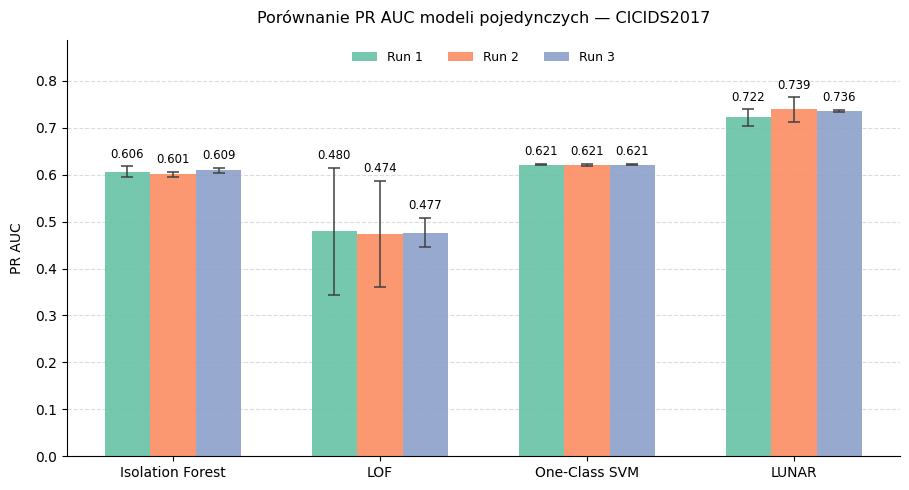

Zapisano: figsolo-prauc-final-unsw.pdf oraz figsolo-prauc-final-unsw.png


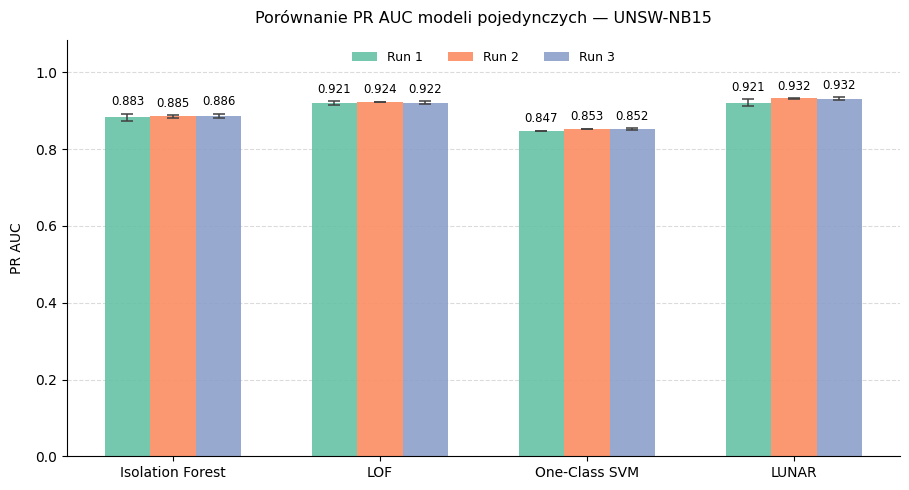

In [9]:
bar_per_dataset(SOLO, 'AUC_PR', 'figsolo-prauc-final', 'PR AUC', 'Porównanie PR AUC modeli pojedynczych')


#### Wykres: FP/FN modeli pojedynczych (figsolo-fpfn-ds)

Zapisano: figsolo-fpfn-cicids.pdf oraz figsolo-fpfn-cicids.png


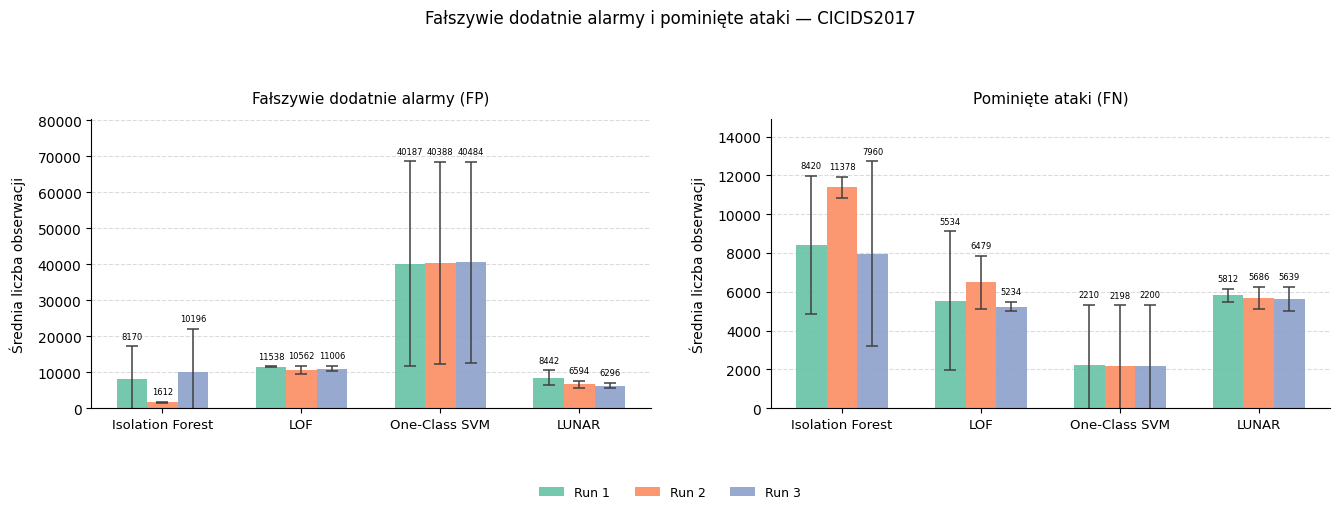

Zapisano: figsolo-fpfn-unsw.pdf oraz figsolo-fpfn-unsw.png


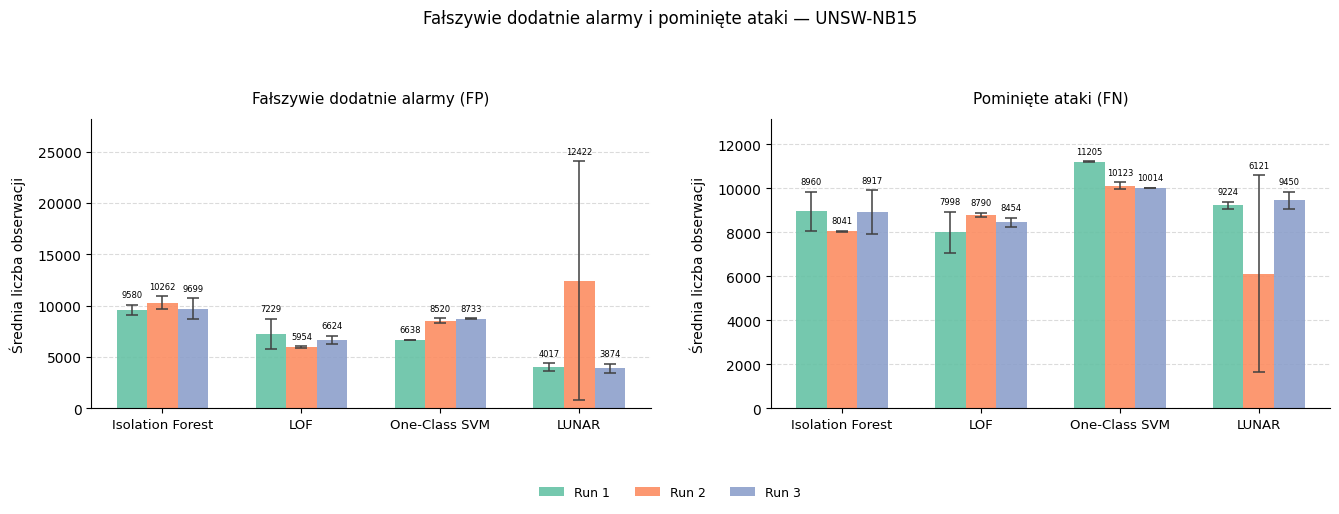

In [10]:
def bar_fp_fn_per_dataset(
    specs,
    stem='figsolo-fpfn',
    source=None,
    run_indices=(1, 2, 3),
):
    
    if source is None:
        source = df_std_clean

    required_columns = {
        'dataset_name',
        'model_type',
        'fusion_strategy',
        'seed',
        'run_index',
        'ConfusionMatrix_FP',
        'ConfusionMatrix_FN',
    }

    missing_columns = required_columns - set(source.columns)

    if missing_columns:
        raise KeyError(
            'Brakuje wymaganych kolumn: '
            + ', '.join(sorted(missing_columns))
        )

    run_indices = list(run_indices)
    n_runs = len(run_indices)

    bar_width = 0.22

    offsets = (
        np.arange(n_runs) - (n_runs - 1) / 2
    ) * bar_width

    run_colors = COLORS[:n_runs]

    error_metrics = [
        ('ConfusionMatrix_FP', 'Fałszywie dodatnie alarmy (FP)'),
        ('ConfusionMatrix_FN', 'Pominięte ataki (FN)'),
    ]

    for ds in DATASETS:
        labels = [
            label
            for _, _, label in specs
        ]

        x = np.arange(len(labels))

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(13.5, 4.8),
            sharex=True,
        )

        for ax, (metric, panel_title) in zip(
            axes,
            error_metrics,
        ):
            all_tops = []

            for run_position, run_index in enumerate(run_indices):
                means = []
                stds = []
                n_seeds_list = []

                for model, fusion, _ in specs:
                    sub = select(
                        source,
                        dataset=ds,
                        model=model,
                        fusion=fusion,
                    ).copy()

                    sub = sub[
                        sub['run_index'].eq(run_index)
                    ].copy()

                    if sub.empty:
                        means.append(np.nan)
                        stds.append(np.nan)
                        n_seeds_list.append(0)
                        continue

                    per_seed = (
                        sub
                        .groupby('seed')[metric]
                        .mean()
                        .dropna()
                    )

                    means.append(per_seed.mean())
                    stds.append(per_seed.std(ddof=1))
                    n_seeds_list.append(len(per_seed))

                stds_plot = [
                    0.0
                    if pd.isna(std)
                    else std
                    for std in stds
                ]

                positions = x + offsets[run_position]

                bars = ax.bar(
                    positions,
                    means,
                    width=bar_width,
                    yerr=stds_plot,
                    capsize=4,
                    color=run_colors[run_position],
                    ecolor='#404040',
                    alpha=0.90,
                    edgecolor='none',
                    error_kw={
                        'elinewidth': 1.1,
                        'capthick': 1.1,
                    },
                    label=f'Run {run_index}',
                )

                for bar, mean, std, n_seeds in zip(
                    bars,
                    means,
                    stds,
                    n_seeds_list,
                ):
                    if pd.isna(mean):
                        continue

                    std_for_label = (
                        0.0
                        if pd.isna(std)
                        else std
                    )

                    all_tops.append(mean + std_for_label)

                    ax.annotate(
                        f'{mean:.0f}',
                        xy=(
                            bar.get_x() + bar.get_width() / 2.0,
                            mean + std_for_label,
                        ),
                        xytext=(0, 4),
                        textcoords='offset points',
                        ha='center',
                        va='bottom',
                        fontsize=6,
                    )

            max_top = max(all_tops, default=1.0)

            ax.set_title(
                panel_title,
                fontsize=11,
                pad=12,
            )

            ax.set_xticks(x)

            ax.set_xticklabels(
                labels,
                rotation=0,
                fontsize=9.5,
            )

            ax.set_ylabel(
                'Średnia liczba obserwacji',
                fontsize=10,
                labelpad=8,
            )

            ax.set_ylim(0, max_top * 1.17)

            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(0.8)
            ax.spines['bottom'].set_linewidth(0.8)

            ax.yaxis.grid(
                True,
                linestyle='--',
                alpha=0.45,
                zorder=0,
            )

            ax.set_axisbelow(True)

        handles, labels_legend = axes[0].get_legend_handles_labels()

        fig.legend(
            handles,
            labels_legend,
            loc='upper center',
            bbox_to_anchor=(0.5, 0.02),
            ncol=3,
            frameon=False,
            facecolor='white',
            edgecolor='#D0D0D0',
            fontsize=9,
            title_fontsize=9,
        )

        fig.suptitle(
            (
                'Fałszywie dodatnie alarmy i pominięte ataki '
                f'— {DATASET_LABELS[ds]}'
            ),
            fontsize=12,
            y=0.99,
        )

        fig.tight_layout(
            rect=(0, 0.08, 1, 0.92),
            w_pad=2.8,
        )

        output_name = (
            f'{stem}-{DATASET_SUFFIX.get(ds, norm(ds))}'
        )

        savefig(fig, output_name)

        plt.show()

bar_fp_fn_per_dataset(
    SOLO,
    stem='figsolo-fpfn',
)

#### Tabela 4.3, 4.4 Self-ensemble LUNAR (bagging/boosting/stacking/voting)


In [5]:
SELF_ENSEMBLE = [
    ('LUNAR', None, 'LUNAR pojedynczy'),
    ('LUNAR_Self_Ensemble', 'bagging', 'Bagging'),
    ('LUNAR_Self_Ensemble', 'boosting', 'Boosting'),
    ('LUNAR_Self_Ensemble', 'stacking', 'Stacking'),
    ('LUNAR_Self_Ensemble', 'voting', 'Voting'),
]


SELF_ENSEMBLE_METRICS = [
    'AUC_ROC',
    'AUC_PR',
    'Precision',
    'Recall',
    'F1',
    'runtime_train',
    'runtime_inference',
]


for ds in DATASETS:
    rows = []

    for model, fusion, label in SELF_ENSEMBLE:
        summary = run_index_seed_summary(
            df_std_clean,
            dataset=ds,
            model=model,
            fusion=fusion,
            metrics=SELF_ENSEMBLE_METRICS,
        )

        if summary.empty:
            print(
                f'UWAGA: brak wyników dla '
                f'dataset={ds}, model={model}, fusion={fusion}'
            )
            continue

        summary.insert(
            0,
            'Wariant',
            label,
        )

        rows.extend(
            summary.to_dict('records')
        )

    export_table(
        rows,
        name=f'tab_self_ensemble_{DATASET_SUFFIX[ds]}',
        caption=(
            f'Porównanie pojedynczego LUNAR i~homogenicznych zespołów LUNAR '
            f'dla zbioru {DATASET_LABELS[ds]} przy standardowym progu '
            f'decyzyjnym. Dla każdego numeru runu wartości podano jako '
            f'średnia $\\pm$ odchylenie standardowe między seedami '
            f'$29$ i~$81$.'
        ),
        label=f'tab:self-ensemble-{DATASET_SUFFIX[ds]}',
    )

,Wariant,Run,AUC_ROC,AUC_PR,Precision,Recall,F1,runtime_train,runtime_inference
0,LUNAR pojedynczy,1,0.859 ± 0.010,0.722 ± 0.018,0.619 ± 0.053,0.700 ± 0.017,0.656 ± 0.022,232.7 ± 56.6,9.6 ± 2.9
1,LUNAR pojedynczy,2,0.869 ± 0.007,0.739 ± 0.026,0.664 ± 0.042,0.696 ± 0.014,0.679 ± 0.015,138.2 ± 38.4,9.0 ± 1.9
2,LUNAR pojedynczy,3,0.869 ± 0.002,0.736 ± 0.003,0.670 ± 0.011,0.694 ± 0.010,0.682 ± 0.011,240.5 ± 107.2,10.0 ± 0.1
3,Bagging,1,0.859 ± 0.010,0.721 ± 0.019,0.615 ± 0.054,0.701 ± 0.017,0.654 ± 0.023,1230.2 ± 210.7,47.4 ± 12.3
4,Bagging,2,0.856 ± 0.009,0.707 ± 0.039,0.590 ± 0.067,0.698 ± 0.010,0.638 ± 0.035,699.1 ± 207.6,44.1 ± 7.2
5,Bagging,3,0.859 ± 0.010,0.721 ± 0.022,0.651 ± 0.006,0.650 ± 0.055,0.650 ± 0.030,1243.7 ± 532.6,53.7 ± 1.1
6,Boosting,1,0.859 ± 0.011,0.721 ± 0.020,0.614 ± 0.057,0.702 ± 0.020,0.653 ± 0.023,1226.7 ± 214.7,47.2 ± 12.5
7,Boosting,2,0.863 ± 0.005,0.724 ± 0.016,0.621 ± 0.030,0.697 ± 0.012,0.657 ± 0.012,700.8 ± 207.5,44.2 ± 7.1
8,Boosting,3,0.867 ± 0.001,0.734 ± 0.005,0.660 ± 0.007,0.697 ± 0.014,0.678 ± 0.010,1243.6 ± 564.1,53.0 ± 4.6
9,Stacking,1,0.859 ± 0.010,0.720 ± 0.020,0.621 ± 0.046,0.698 ± 0.013,0.657 ± 0.020,1258.6 ± 169.3,47.5 ± 11.9


\begin{table}[H]
\centering
\caption{Porównanie pojedynczego LUNAR i~homogenicznych zespołów LUNAR dla zbioru CICIDS 2017 przy standardowym progu decyzyjnym. Dla każdego numeru runu wartości podano jako średnia $\pm$ odchylenie standardowe między seedami $29$ i~$81$.}
\label{tab:self-ensemble-cicids}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccccccc}
\hline
Wariant & Run & AUC_ROC & AUC_PR & Precision & Recall & F1 & runtime_train & runtime_inference \\
\hline
LUNAR pojedynczy & 1 & $0{,}859 \pm 0{,}010$ & $0{,}722 \pm 0{,}018$ & $0{,}619 \pm 0{,}053$ & $0{,}700 \pm 0{,}017$ & $0{,}656 \pm 0{,}022$ & $232{,}7 \pm 56{,}6$ & $9{,}6 \pm 2{,}9$ \\
LUNAR pojedynczy & 2 & $0{,}869 \pm 0{,}007$ & $0{,}739 \pm 0{,}026$ & $0{,}664 \pm 0{,}042$ & $0{,}696 \pm 0{,}014$ & $0{,}679 \pm 0{,}015$ & $138{,}2 \pm 38{,}4$ & $9{,}0 \pm 1{,}9$ \\
LUNAR pojedynczy & 3 & $0{,}869 \pm 0{,}002$ & $0{,}736 \pm 0{,}003$ & $0{,}670 \pm 0{,}011$ & $0{,}694 \pm 0{,}010$ & $0{,}682 \pm 0{,}011$ & $240{,}5 \pm 1

,Wariant,Run,AUC_ROC,AUC_PR,Precision,Recall,F1,runtime_train,runtime_inference
0,LUNAR pojedynczy,1,0.875 ± 0.013,0.921 ± 0.009,0.897 ± 0.008,0.791 ± 0.004,0.840 ± 0.001,252.5 ± 234.0,14.1 ± 0.8
1,LUNAR pojedynczy,2,0.894 ± 0.001,0.932 ± 0.000,0.779 ± 0.160,0.861 ± 0.102,0.807 ± 0.043,402.4 ± 3.8,11.9 ± 0.1
2,LUNAR pojedynczy,3,0.894 ± 0.005,0.932 ± 0.004,0.899 ± 0.009,0.785 ± 0.009,0.839 ± 0.001,489.8 ± 264.4,13.4 ± 2.8
3,Bagging,1,0.872 ± 0.016,0.923 ± 0.007,0.914 ± 0.014,0.782 ± 0.004,0.843 ± 0.003,1273.3 ± 1158.9,69.2 ± 6.0
4,Bagging,2,0.893 ± 0.000,0.932 ± 0.000,0.880 ± 0.026,0.791 ± 0.018,0.833 ± 0.001,1850.6 ± 235.5,57.0 ± 0.5
5,Bagging,3,0.891 ± 0.004,0.931 ± 0.002,0.906 ± 0.016,0.778 ± 0.019,0.837 ± 0.004,2452.2 ± 1310.6,67.0 ± 14.2
6,Boosting,1,0.875 ± 0.013,0.924 ± 0.006,0.889 ± 0.054,0.779 ± 0.003,0.830 ± 0.022,1268.4 ± 1152.2,69.1 ± 5.6
7,Boosting,2,0.893 ± 0.001,0.932 ± 0.000,0.901 ± 0.004,0.776 ± 0.002,0.834 ± 0.000,1844.2 ± 206.3,56.8 ± 0.5
8,Boosting,3,0.890 ± 0.005,0.929 ± 0.005,0.903 ± 0.003,0.782 ± 0.008,0.838 ± 0.003,2457.5 ± 1310.9,66.9 ± 14.0
9,Stacking,1,0.894 ± 0.002,0.933 ± 0.001,0.910 ± 0.017,0.784 ± 0.006,0.842 ± 0.004,1269.0 ± 1153.9,69.5 ± 5.1


\begin{table}[H]
\centering
\caption{Porównanie pojedynczego LUNAR i~homogenicznych zespołów LUNAR dla zbioru UNSW-NB15 przy standardowym progu decyzyjnym. Dla każdego numeru runu wartości podano jako średnia $\pm$ odchylenie standardowe między seedami $29$ i~$81$.}
\label{tab:self-ensemble-unsw}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccccccc}
\hline
Wariant & Run & AUC_ROC & AUC_PR & Precision & Recall & F1 & runtime_train & runtime_inference \\
\hline
LUNAR pojedynczy & 1 & $0{,}875 \pm 0{,}013$ & $0{,}921 \pm 0{,}009$ & $0{,}897 \pm 0{,}008$ & $0{,}791 \pm 0{,}004$ & $0{,}840 \pm 0{,}001$ & $252{,}5 \pm 234{,}0$ & $14{,}1 \pm 0{,}8$ \\
LUNAR pojedynczy & 2 & $0{,}894 \pm 0{,}001$ & $0{,}932 \pm 0{,}000$ & $0{,}779 \pm 0{,}160$ & $0{,}861 \pm 0{,}102$ & $0{,}807 \pm 0{,}043$ & $402{,}4 \pm 3{,}8$ & $11{,}9 \pm 0{,}1$ \\
LUNAR pojedynczy & 3 & $0{,}894 \pm 0{,}005$ & $0{,}932 \pm 0{,}004$ & $0{,}899 \pm 0{,}009$ & $0{,}785 \pm 0{,}009$ & $0{,}839 \pm 0{,}001$ & $489{,}8 \pm 264

#### Wykres: Self ensemble vs pojedynczy LUNAR (figlunar-self-ensemble-prauc-final-ds)

Zapisano: figlunar-self-ensemble-prauc-final-cicids.pdf oraz figlunar-self-ensemble-prauc-final-cicids.png


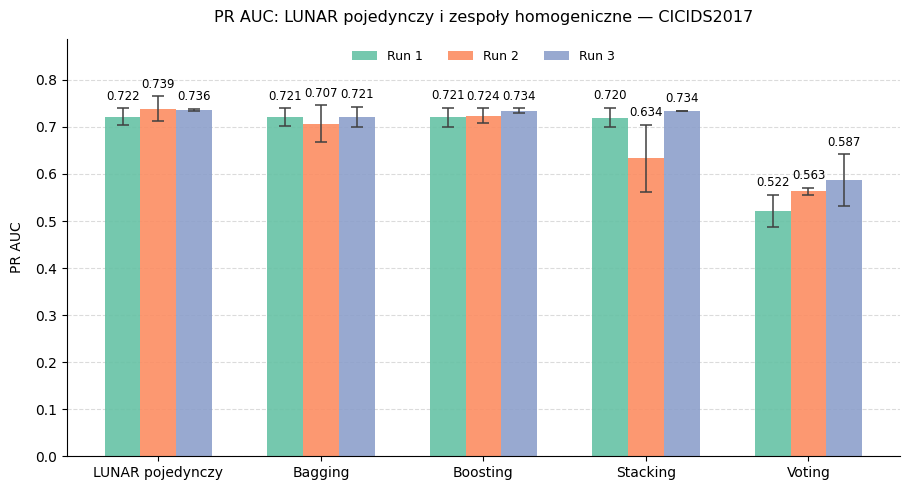

Zapisano: figlunar-self-ensemble-prauc-final-unsw.pdf oraz figlunar-self-ensemble-prauc-final-unsw.png


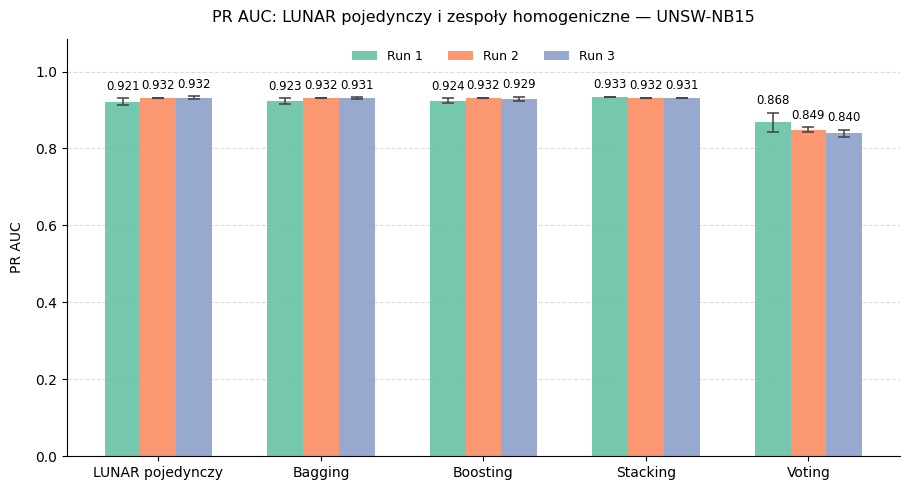

In [12]:
SELF_ENSEMBLE = [
    ('LUNAR', None, 'LUNAR pojedynczy'),
    ('LUNAR_Self_Ensemble', 'bagging', 'Bagging'),
    ('LUNAR_Self_Ensemble', 'boosting', 'Boosting'),
    ('LUNAR_Self_Ensemble', 'stacking', 'Stacking'),
    ('LUNAR_Self_Ensemble', 'voting', 'Voting'),
]


bar_per_dataset(
    specs=SELF_ENSEMBLE,
    metric='AUC_PR',
    stem='figlunar-self-ensemble-prauc-final',
    ylabel='PR AUC',
    title='PR AUC: LUNAR pojedynczy i zespoły homogeniczne',
    source=df_std_clean,
    run_indices=(1, 2, 3),
)

#### Wykres: koszt uczenia/wnioskowania self-ensemble (fig_lunar_self_ensemble_runtime_ds)
 

Zapisano: figlunar-self-ensemble-runtime-cicids.pdf oraz figlunar-self-ensemble-runtime-cicids.png


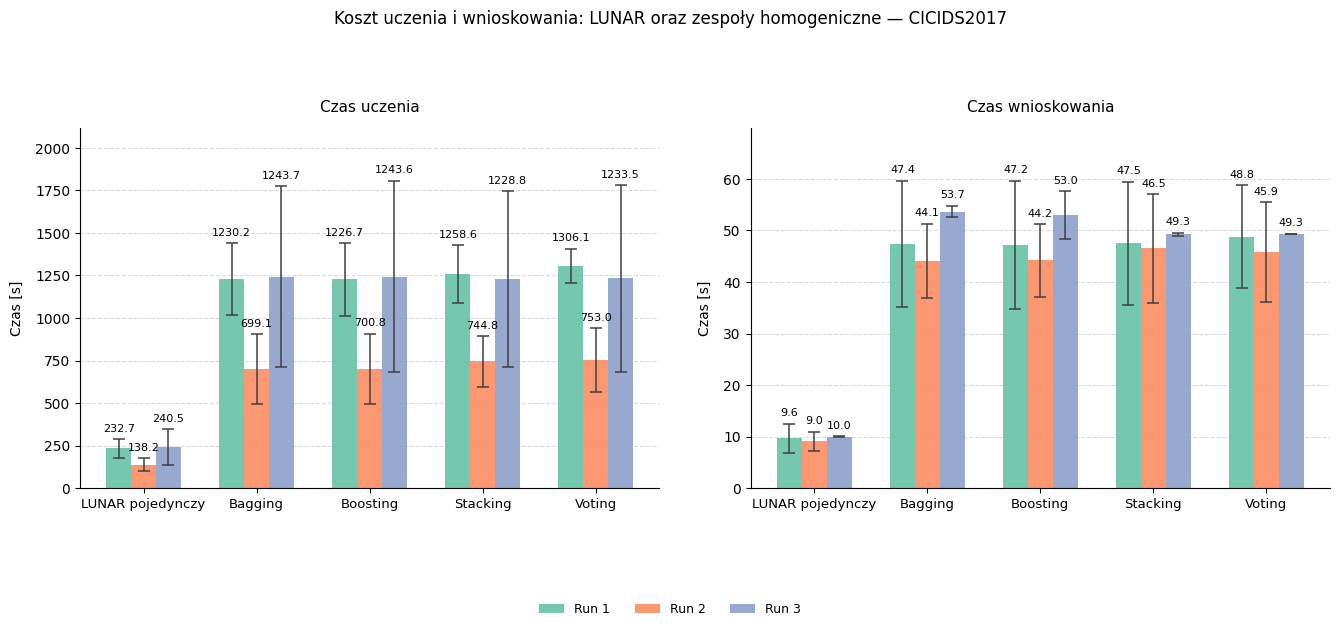

Zapisano: figlunar-self-ensemble-runtime-unsw.pdf oraz figlunar-self-ensemble-runtime-unsw.png


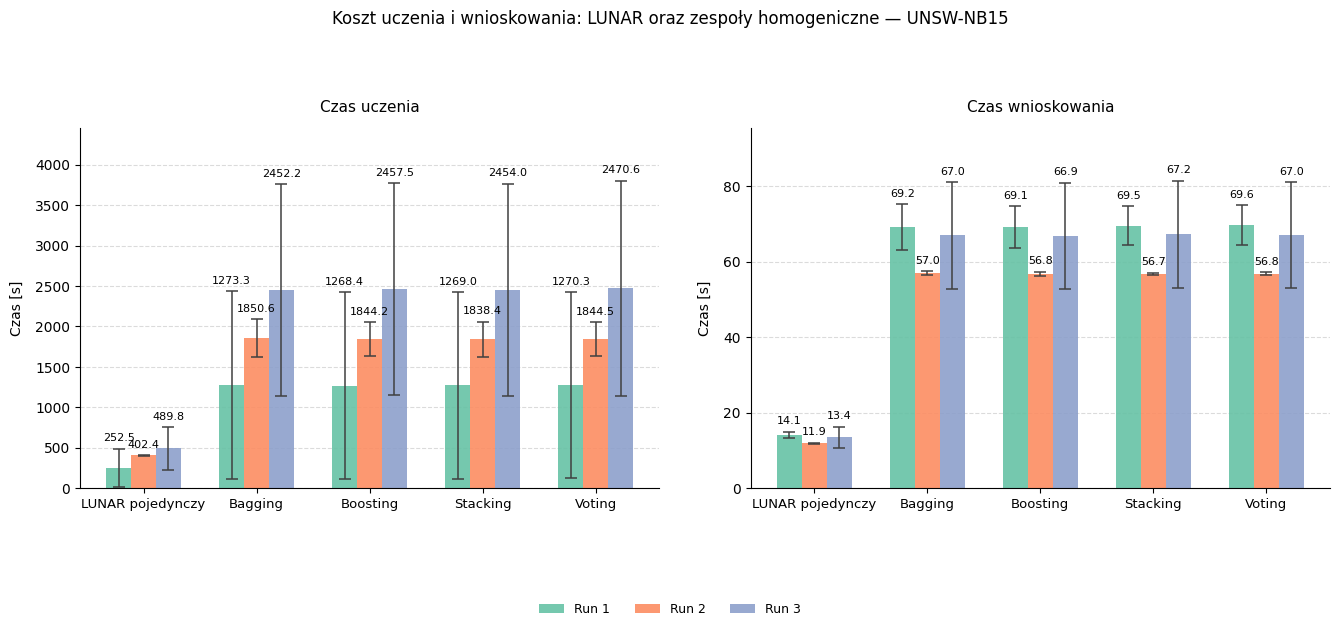

In [20]:
def bar_runtime_per_dataset(
    specs,
    stem='figlunar-self-ensemble-runtime-final',
    source=None,
    run_indices=(1, 2, 3),
):
    if source is None:
        source = df_std_clean

    required_columns = {
        'dataset_name',
        'model_type',
        'fusion_strategy',
        'seed',
        'run_index',
        'runtime_train',
        'runtime_inference',
    }

    missing_columns = required_columns - set(source.columns)

    if missing_columns:
        raise KeyError(
            'Brakuje wymaganych kolumn: '
            + ', '.join(sorted(missing_columns))
        )

    run_indices = list(run_indices)
    n_runs = len(run_indices)

    bar_width = 0.22

    offsets = (
        np.arange(n_runs) - (n_runs - 1) / 2
    ) * bar_width

    run_colors = COLORS[:n_runs]

    runtime_metrics = [
        (
            'runtime_train',
            'Czas uczenia',
        ),
        (
            'runtime_inference',
            'Czas wnioskowania',
        ),
    ]

    for ds in DATASETS:
        labels = [
            label
            for _, _, label in specs
        ]

        x = np.arange(len(labels))

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(13.5, 6),
            sharex=True,
        )

        for ax, (metric, panel_title) in zip(
            axes,
            runtime_metrics,
        ):
            all_tops = []

            for run_position, run_index in enumerate(run_indices):
                means = []
                stds = []
                n_seeds_list = []

                for model, fusion, _ in specs:
                    sub = select(
                        source,
                        dataset=ds,
                        model=model,
                        fusion=fusion,
                    ).copy()

                    sub = sub[
                        sub['run_index'].eq(run_index)
                    ].copy()

                    if sub.empty:
                        means.append(np.nan)
                        stds.append(np.nan)
                        n_seeds_list.append(0)
                        continue

                    per_seed = (
                        sub
                        .groupby('seed')[metric]
                        .mean()
                        .dropna()
                    )

                    means.append(per_seed.mean())
                    stds.append(per_seed.std(ddof=1))
                    n_seeds_list.append(len(per_seed))

                stds_plot = [
                    0.0
                    if pd.isna(std)
                    else std
                    for std in stds
                ]

                positions = x + offsets[run_position]

                bars = ax.bar(
                    positions,
                    means,
                    width=bar_width,
                    yerr=stds_plot,
                    capsize=4,
                    color=run_colors[run_position],
                    ecolor='#404040',
                    alpha=0.90,
                    edgecolor='none',
                    error_kw={
                        'elinewidth': 1.1,
                        'capthick': 1.1,
                    },
                    label=f'Run {run_index}',
                )

                for bar, mean, std, n_seeds in zip(
                    bars,
                    means,
                    stds,
                    n_seeds_list,
                ):
                    if pd.isna(mean):
                        continue

                    std_for_label = (
                        0.0
                        if pd.isna(std)
                        else std
                    )

                    all_tops.append(
                        mean + std_for_label
                    )

                    ax.annotate(
                        f'{mean:.1f}',
                        xy=(
                            bar.get_x() + bar.get_width() / 2.0,
                            mean + std_for_label,
                        ),
                        xytext=(0, 4),
                        textcoords='offset points',
                        ha='center',
                        va='bottom',
                        fontsize=8,
                    )

            max_top = max(all_tops, default=1.0)

            ax.set_title(
                panel_title,
                fontsize=11,
                pad=12,
            )

            ax.set_xticks(x)

            ax.set_xticklabels(
                labels,
                rotation=0,
                fontsize=9.5,
            )

            ax.set_ylabel(
                'Czas [s]',
                fontsize=10,
                labelpad=8,
            )

            ax.set_ylim(0, max_top * 1.17)

            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(0.8)
            ax.spines['bottom'].set_linewidth(0.8)

            ax.yaxis.grid(
                True,
                linestyle='--',
                alpha=0.45,
                zorder=0,
            )

            ax.set_axisbelow(True)

        handles, legend_labels = axes[0].get_legend_handles_labels()

        fig.legend(
            handles,
            legend_labels,
            loc='upper center',
            bbox_to_anchor=(0.5, 0.02),
            ncol=3,
            frameon=False,
            facecolor='white',
            fontsize=9,
            title_fontsize=9,
        )

        fig.suptitle(
            (
                'Koszt uczenia i wnioskowania: '
                f'LUNAR oraz zespoły homogeniczne '
                f'— {DATASET_LABELS[ds]}'
            ),
            fontsize=12,
            y=0.99,
        )

        fig.tight_layout(
            rect=(0, 0.13, 1, 0.92),
            w_pad=2.8,
        )

        output_name = (
            f'{stem}-{DATASET_SUFFIX.get(ds, norm(ds))}'
        )

        savefig(fig, output_name)

        plt.show()

bar_runtime_per_dataset(
    SELF_ENSEMBLE,
    stem='figlunar-self-ensemble-runtime',
)

#### Wykres: F1 self-ensemble vs LUNAR pojedynczy (fig_self_ensemble_f1_final_ds)


Zapisano: fig_self_ensemble_f1_final-cicids.pdf oraz fig_self_ensemble_f1_final-cicids.png


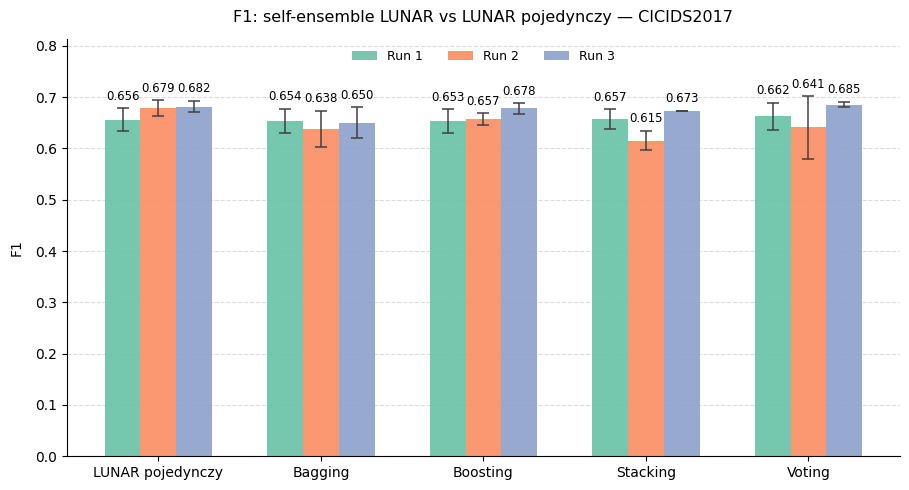

Zapisano: fig_self_ensemble_f1_final-unsw.pdf oraz fig_self_ensemble_f1_final-unsw.png


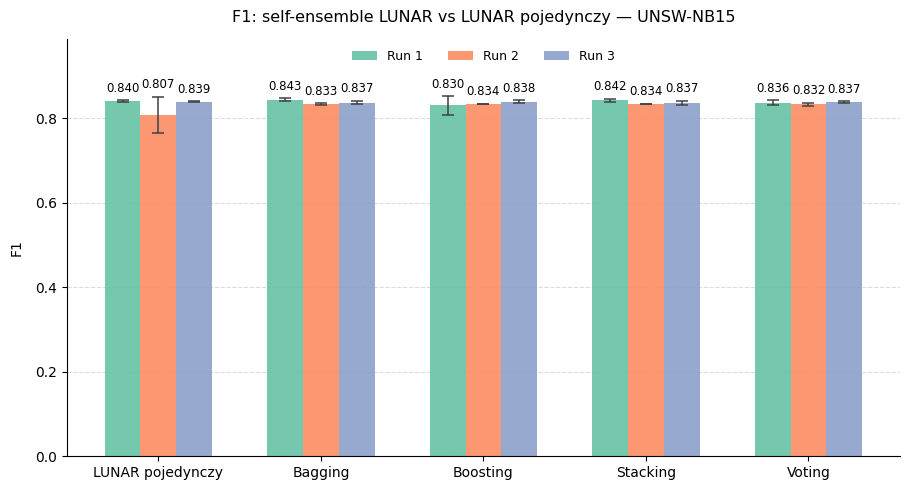

In [22]:
bar_per_dataset(SELF_ENSEMBLE, 'F1', 'fig_self_ensemble_f1_final', 'F1', 'F1: self-ensemble LUNAR vs LUNAR pojedynczy')


#### Tabela 4.5, 4.6 Wkład LUNAR w zespole: LUNAR vs zespół klasyczny vs zespół z LUNAR (classical-ensemble-final-ds)


In [23]:
CLASSICAL_SPECS = [
    (
        'IsolationForest',
        'none',
        'Isolation Forest',
    ),
    (
        'LOF',
        'none',
        'LOF',
    ),
    (
        'OneClassSVM',
        'none',
        'One-Class SVM',
    ),
    (
        'Ensemble_without_LUNAR',
        'rank_mean',
        'Zespół klasyczny',
    ),
]


CLASSICAL_METRICS = [
    'AUC_ROC',
    'AUC_PR',
    'Precision',
    'Recall',
    'F1',
]


for ds in DATASETS:
    rows = []

    for model, fusion, label in CLASSICAL_SPECS:
        summary = run_index_seed_summary(
            df_std_clean,
            dataset=ds,
            model=model,
            fusion=fusion,
            metrics=CLASSICAL_METRICS,
        )

        if summary.empty:
            print(
                f'UWAGA: brak wyników dla '
                f'dataset={ds}, '
                f'model={model}, '
                f'fusion={fusion}'
            )
            continue

        summary.insert(
            0,
            'Model',
            label,
        )

        rows.extend(
            summary.to_dict('records')
        )

    export_table(
        rows,
        name=(
            f'tab_classical_ensemble_'
            f'{DATASET_SUFFIX[ds]}'
        ),
        caption=(
            f'Porównanie zespołu klasycznego z~modelami pojedynczymi '
            f'dla zbioru {DATASET_LABELS[ds]} przy standardowym progu '
            f'decyzyjnym. Dla każdego numeru runu wartości podano jako '
            f'średnia $\\pm$ odchylenie standardowe między seedami '
            f'$29$ i~$81$.'
        ),
        label=(
            f'tab:classical-ensemble-'
            f'{DATASET_SUFFIX[ds]}'
        ),
    )


,Model,Run,AUC_ROC,AUC_PR,Precision,Recall,F1
0,Isolation Forest,1,0.818 ± 0.016,0.606 ± 0.012,0.653 ± 0.244,0.565 ± 0.183,0.569 ± 0.002
1,Isolation Forest,2,0.811 ± 0.001,0.601 ± 0.006,0.833 ± 0.009,0.413 ± 0.028,0.551 ± 0.023
2,Isolation Forest,3,0.817 ± 0.000,0.609 ± 0.005,0.629 ± 0.264,0.589 ± 0.246,0.556 ± 0.007
3,LOF,1,0.791 ± 0.094,0.480 ± 0.135,0.541 ± 0.063,0.714 ± 0.185,0.614 ± 0.110
4,LOF,2,0.788 ± 0.081,0.474 ± 0.113,0.549 ± 0.053,0.666 ± 0.070,0.602 ± 0.060
5,LOF,3,0.826 ± 0.023,0.477 ± 0.032,0.562 ± 0.021,0.730 ± 0.013,0.635 ± 0.018
6,One-Class SVM,1,0.768 ± 0.000,0.621 ± 0.002,0.335 ± 0.129,0.886 ± 0.161,0.470 ± 0.112
7,One-Class SVM,2,0.768 ± 0.000,0.621 ± 0.002,0.333 ± 0.126,0.887 ± 0.160,0.469 ± 0.109
8,One-Class SVM,3,0.767 ± 0.000,0.621 ± 0.002,0.331 ± 0.125,0.886 ± 0.161,0.468 ± 0.108
9,Zespół klasyczny,1,0.850 ± 0.048,0.687 ± 0.074,0.685 ± 0.038,0.625 ± 0.162,0.650 ± 0.107


\begin{table}[H]
\centering
\caption{Porównanie zespołu klasycznego z~modelami pojedynczymi dla zbioru CICIDS2017 przy standardowym progu decyzyjnym. Dla każdego numeru runu wartości podano jako średnia $\pm$ odchylenie standardowe między seedami $29$ i~$81$.}
\label{tab:classical-ensemble-cicids}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccccc}
\hline
Model & Run & AUC_ROC & AUC_PR & Precision & Recall & F1 \\
\hline
Isolation Forest & 1 & $0{,}818 \pm 0{,}016$ & $0{,}606 \pm 0{,}012$ & $0{,}653 \pm 0{,}244$ & $0{,}565 \pm 0{,}183$ & $0{,}569 \pm 0{,}002$ \\
Isolation Forest & 2 & $0{,}811 \pm 0{,}001$ & $0{,}601 \pm 0{,}006$ & $0{,}833 \pm 0{,}009$ & $0{,}413 \pm 0{,}028$ & $0{,}551 \pm 0{,}023$ \\
Isolation Forest & 3 & $0{,}817 \pm 0{,}000$ & $0{,}609 \pm 0{,}005$ & $0{,}629 \pm 0{,}264$ & $0{,}589 \pm 0{,}246$ & $0{,}556 \pm 0{,}007$ \\
LOF & 1 & $0{,}791 \pm 0{,}094$ & $0{,}480 \pm 0{,}135$ & $0{,}541 \pm 0{,}063$ & $0{,}714 \pm 0{,}185$ & $0{,}614 \pm 0{,}110$ \\
LOF & 2 & $

,Model,Run,AUC_ROC,AUC_PR,Precision,Recall,F1
0,Isolation Forest,1,0.838 ± 0.009,0.883 ± 0.010,0.786 ± 0.005,0.797 ± 0.020,0.791 ± 0.008
1,Isolation Forest,2,0.846 ± 0.000,0.885 ± 0.003,0.778 ± 0.010,0.817 ± 0.001,0.797 ± 0.005
2,Isolation Forest,3,0.846 ± 0.000,0.886 ± 0.006,0.784 ± 0.013,0.798 ± 0.022,0.790 ± 0.005
3,LOF,1,0.888 ± 0.005,0.921 ± 0.005,0.834 ± 0.025,0.818 ± 0.021,0.826 ± 0.002
4,LOF,2,0.890 ± 0.000,0.924 ± 0.000,0.856 ± 0.001,0.800 ± 0.003,0.827 ± 0.001
5,LOF,3,0.891 ± 0.001,0.922 ± 0.003,0.843 ± 0.007,0.808 ± 0.005,0.825 ± 0.001
6,One-Class SVM,1,0.816 ± 0.000,0.847 ± 0.001,0.832 ± 0.000,0.746 ± 0.001,0.786 ± 0.000
7,One-Class SVM,2,0.819 ± 0.000,0.853 ± 0.000,0.799 ± 0.004,0.770 ± 0.004,0.784 ± 0.000
8,One-Class SVM,3,0.819 ± 0.001,0.852 ± 0.002,0.796 ± 0.001,0.773 ± 0.000,0.784 ± 0.000
9,Zespół klasyczny,1,0.872 ± 0.002,0.908 ± 0.002,0.820 ± 0.012,0.787 ± 0.005,0.803 ± 0.003


\begin{table}[H]
\centering
\caption{Porównanie zespołu klasycznego z~modelami pojedynczymi dla zbioru UNSW-NB15 przy standardowym progu decyzyjnym. Dla każdego numeru runu wartości podano jako średnia $\pm$ odchylenie standardowe między seedami $29$ i~$81$.}
\label{tab:classical-ensemble-unsw}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccccc}
\hline
Model & Run & AUC_ROC & AUC_PR & Precision & Recall & F1 \\
\hline
Isolation Forest & 1 & $0{,}838 \pm 0{,}009$ & $0{,}883 \pm 0{,}010$ & $0{,}786 \pm 0{,}005$ & $0{,}797 \pm 0{,}020$ & $0{,}791 \pm 0{,}008$ \\
Isolation Forest & 2 & $0{,}846 \pm 0{,}000$ & $0{,}885 \pm 0{,}003$ & $0{,}778 \pm 0{,}010$ & $0{,}817 \pm 0{,}001$ & $0{,}797 \pm 0{,}005$ \\
Isolation Forest & 3 & $0{,}846 \pm 0{,}000$ & $0{,}886 \pm 0{,}006$ & $0{,}784 \pm 0{,}013$ & $0{,}798 \pm 0{,}022$ & $0{,}790 \pm 0{,}005$ \\
LOF & 1 & $0{,}888 \pm 0{,}005$ & $0{,}921 \pm 0{,}005$ & $0{,}834 \pm 0{,}025$ & $0{,}818 \pm 0{,}021$ & $0{,}826 \pm 0{,}002$ \\
LOF & 2 & $0{,

#### Wykres: PR AUC modeli klasycznych i zespołu klasycznego figclassical-ensemble-prauc-final-ds

Zapisano: figclassical-ensemble-prauc-final-cicids.pdf oraz figclassical-ensemble-prauc-final-cicids.png


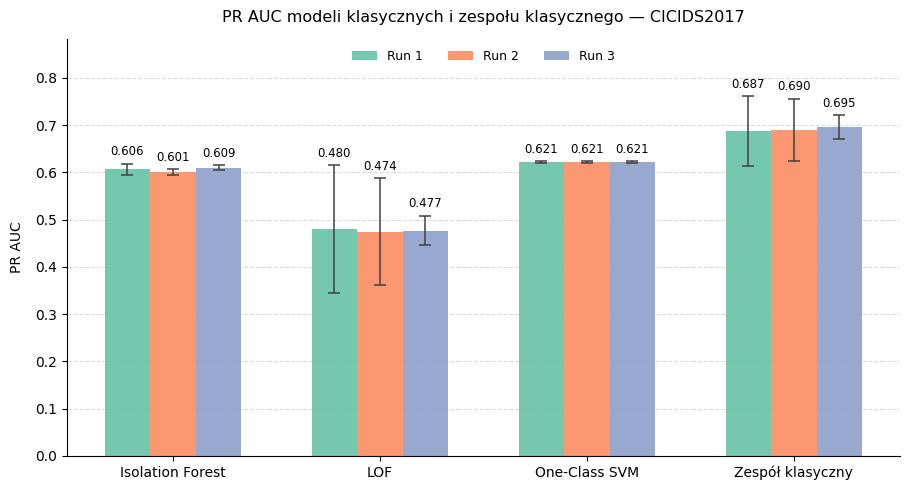

Zapisano: figclassical-ensemble-prauc-final-unsw.pdf oraz figclassical-ensemble-prauc-final-unsw.png


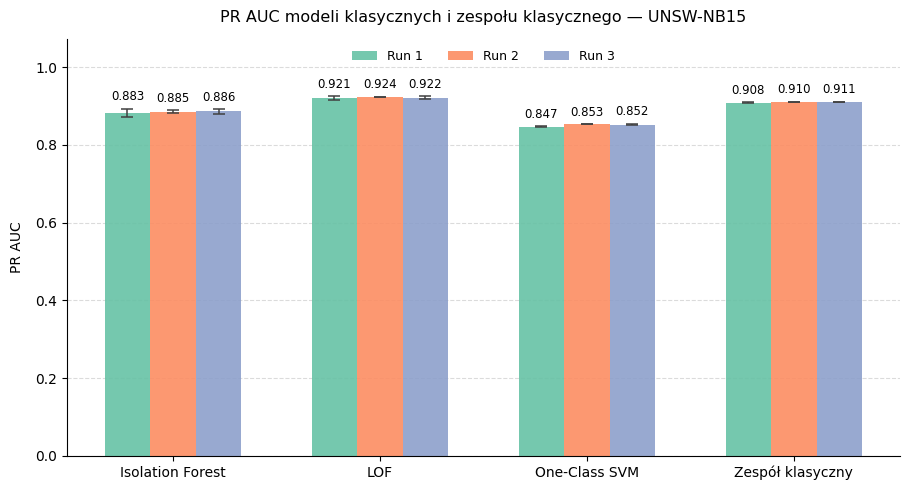

In [27]:
CLASSICAL = [('IsolationForest', None, 'Isolation Forest'), ('LOF', None, 'LOF'),
             ('OneClassSVM', None, 'One-Class SVM'), ('Ensemble_without_LUNAR', 'rank_mean', 'Zespół klasyczny')]

bar_per_dataset(
    CLASSICAL,
    metric="AUC_PR",
    stem="figclassical-ensemble-prauc-final",
    ylabel="PR AUC",
    title="PR AUC modeli klasycznych i zespołu klasycznego"
)

#### Tabela: wkład LUNAR w zespole lunar_contribution_final

In [28]:
LUNAR_CONTRIBUTION_SPECS = [
    (
        'LUNAR',
        None,
        'LUNAR',
    ),
    (
        'Ensemble_without_LUNAR',
        'rank_mean',
        'Zespół klasyczny',
    ),
    (
        'Ensemble_with_LUNAR',
        'rank_mean',
        'Zespół z LUNAR',
    ),
]


LUNAR_CONTRIBUTION_METRICS = [
    'AUC_ROC',
    'AUC_PR',
    'Precision',
    'Recall',
    'F1',
    'runtime_train',
    'runtime_inference',
]


COLUMN_RENAMES = {
    'AUC_ROC': 'ROC AUC',
    'AUC_PR': 'PR AUC',
    'Precision': 'Precision',
    'Recall': 'Recall',
    'F1': '$F_1$',
    'runtime_train': 'Czas uczenia [s]',
    'runtime_inference': 'Czas wnioskowania [s]',
}


for ds in DATASETS:
    rows = []

    for model, fusion, label in LUNAR_CONTRIBUTION_SPECS:
        summary = run_index_seed_summary(
            df_std_clean,
            dataset=ds,
            model=model,
            fusion=fusion,
            metrics=LUNAR_CONTRIBUTION_METRICS,
        )

        if summary.empty:
            print(
                f'UWAGA: brak wyników dla '
                f'dataset={ds}, '
                f'model={model}, '
                f'fusion={fusion}'
            )
            continue

        summary = summary.rename(
            columns=COLUMN_RENAMES
        )

        summary.insert(
            0,
            'Wariant',
            label,
        )

        rows.extend(
            summary.to_dict('records')
        )

    export_table(
        rows,
        name=(
            f'tab_lunar_contribution_'
            f'{DATASET_SUFFIX[ds]}'
        ),
        caption=(
            f'Wkład LUNAR w~zespole dla zbioru '
            f'{DATASET_LABELS[ds]}. '
            f'Dla każdego numeru runu wartości podano jako średnia '
            f'$\\pm$ odchylenie standardowe między seedami '
            f'$29$ i~$81$.'
        ),
        label=(
            f'tab:lunar-contribution-'
            f'{DATASET_SUFFIX[ds]}'
        ),
    )

,Wariant,Run,ROC AUC,PR AUC,Precision,Recall,$F_1$,Czas uczenia [s],Czas wnioskowania [s]
0,LUNAR,1,0.859 ± 0.010,0.722 ± 0.018,0.619 ± 0.053,0.700 ± 0.017,0.656 ± 0.022,232.7 ± 56.6,9.6 ± 2.9
1,LUNAR,2,0.869 ± 0.007,0.739 ± 0.026,0.664 ± 0.042,0.696 ± 0.014,0.679 ± 0.015,138.2 ± 38.4,9.0 ± 1.9
2,LUNAR,3,0.869 ± 0.002,0.736 ± 0.003,0.670 ± 0.011,0.694 ± 0.010,0.682 ± 0.011,240.5 ± 107.2,10.0 ± 0.1
3,Zespół klasyczny,1,0.850 ± 0.048,0.687 ± 0.074,0.685 ± 0.038,0.625 ± 0.162,0.650 ± 0.107,9.3 ± 6.3,15.9 ± 14.0
4,Zespół klasyczny,2,0.848 ± 0.046,0.690 ± 0.066,0.585 ± 0.205,0.762 ± 0.073,0.645 ± 0.105,13.3 ± 0.5,25.9 ± 1.1
5,Zespół klasyczny,3,0.866 ± 0.020,0.695 ± 0.025,0.582 ± 0.151,0.822 ± 0.092,0.670 ± 0.072,9.6 ± 6.5,15.8 ± 13.0
6,Zespół z LUNAR,1,0.862 ± 0.039,0.709 ± 0.060,0.613 ± 0.097,0.689 ± 0.069,0.649 ± 0.085,252.9 ± 50.3,25.5 ± 16.7
7,Zespół z LUNAR,2,0.887,0.755,0.672,0.744,0.706,181.5,32.8
8,Zespół z LUNAR,3,0.876 ± 0.014,0.723 ± 0.016,0.563 ± 0.115,0.835 ± 0.117,0.663 ± 0.044,251.4 ± 117.3,25.6 ± 13.8


\begin{table}[H]
\centering
\caption{Wkład LUNAR w~zespole dla zbioru CICIDS2017. Dla każdego numeru runu wartości podano jako średnia $\pm$ odchylenie standardowe między seedami $29$ i~$81$.}
\label{tab:lunar-contribution-cicids}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccccccc}
\hline
Wariant & Run & ROC AUC & PR AUC & Precision & Recall & $F_1$ & Czas uczenia [s] & Czas wnioskowania [s] \\
\hline
LUNAR & 1 & $0{,}859 \pm 0{,}010$ & $0{,}722 \pm 0{,}018$ & $0{,}619 \pm 0{,}053$ & $0{,}700 \pm 0{,}017$ & $0{,}656 \pm 0{,}022$ & $232{,}7 \pm 56{,}6$ & $9{,}6 \pm 2{,}9$ \\
LUNAR & 2 & $0{,}869 \pm 0{,}007$ & $0{,}739 \pm 0{,}026$ & $0{,}664 \pm 0{,}042$ & $0{,}696 \pm 0{,}014$ & $0{,}679 \pm 0{,}015$ & $138{,}2 \pm 38{,}4$ & $9{,}0 \pm 1{,}9$ \\
LUNAR & 3 & $0{,}869 \pm 0{,}002$ & $0{,}736 \pm 0{,}003$ & $0{,}670 \pm 0{,}011$ & $0{,}694 \pm 0{,}010$ & $0{,}682 \pm 0{,}011$ & $240{,}5 \pm 107{,}2$ & $10{,}0 \pm 0{,}1$ \\
Zespół klasyczny & 1 & $0{,}850 \pm 0{,}048$ & $0{,}687 \pm 0{

,Wariant,Run,ROC AUC,PR AUC,Precision,Recall,$F_1$,Czas uczenia [s],Czas wnioskowania [s]
0,LUNAR,1,0.875 ± 0.013,0.921 ± 0.009,0.897 ± 0.008,0.791 ± 0.004,0.840 ± 0.001,252.5 ± 234.0,14.1 ± 0.8
1,LUNAR,2,0.894 ± 0.001,0.932 ± 0.000,0.779 ± 0.160,0.861 ± 0.102,0.807 ± 0.043,402.4 ± 3.8,11.9 ± 0.1
2,LUNAR,3,0.894 ± 0.005,0.932 ± 0.004,0.899 ± 0.009,0.785 ± 0.009,0.839 ± 0.001,489.8 ± 264.4,13.4 ± 2.8
3,Zespół klasyczny,1,0.872 ± 0.002,0.908 ± 0.002,0.820 ± 0.012,0.787 ± 0.005,0.803 ± 0.003,111.1 ± 7.1,144.8 ± 7.9
4,Zespół klasyczny,2,0.875 ± 0.001,0.910 ± 0.001,0.834 ± 0.006,0.784 ± 0.013,0.808 ± 0.004,111.7 ± 14.5,144.7 ± 9.9
5,Zespół klasyczny,3,0.875 ± 0.001,0.911 ± 0.000,0.836 ± 0.010,0.772 ± 0.009,0.803 ± 0.000,101.6 ± 0.3,131.2 ± 1.5
6,Zespół z LUNAR,1,0.879,0.920,0.828,0.808,0.818,226.0,169.2
7,Zespół z LUNAR,2,0.892 ± 0.000,0.926 ± 0.000,0.802 ± 0.002,0.842 ± 0.001,0.821 ± 0.000,533.6 ± 133.5,153.6 ± 15.6
8,Zespół z LUNAR,3,0.893 ± 0.001,0.925 ± 0.002,0.805 ± 0.001,0.837 ± 0.004,0.821 ± 0.002,591.8 ± 259.1,158.3 ± 16.4


\begin{table}[H]
\centering
\caption{Wkład LUNAR w~zespole dla zbioru UNSW-NB15. Dla każdego numeru runu wartości podano jako średnia $\pm$ odchylenie standardowe między seedami $29$ i~$81$.}
\label{tab:lunar-contribution-unsw}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccccccc}
\hline
Wariant & Run & ROC AUC & PR AUC & Precision & Recall & $F_1$ & Czas uczenia [s] & Czas wnioskowania [s] \\
\hline
LUNAR & 1 & $0{,}875 \pm 0{,}013$ & $0{,}921 \pm 0{,}009$ & $0{,}897 \pm 0{,}008$ & $0{,}791 \pm 0{,}004$ & $0{,}840 \pm 0{,}001$ & $252{,}5 \pm 234{,}0$ & $14{,}1 \pm 0{,}8$ \\
LUNAR & 2 & $0{,}894 \pm 0{,}001$ & $0{,}932 \pm 0{,}000$ & $0{,}779 \pm 0{,}160$ & $0{,}861 \pm 0{,}102$ & $0{,}807 \pm 0{,}043$ & $402{,}4 \pm 3{,}8$ & $11{,}9 \pm 0{,}1$ \\
LUNAR & 3 & $0{,}894 \pm 0{,}005$ & $0{,}932 \pm 0{,}004$ & $0{,}899 \pm 0{,}009$ & $0{,}785 \pm 0{,}009$ & $0{,}839 \pm 0{,}001$ & $489{,}8 \pm 264{,}4$ & $13{,}4 \pm 2{,}8$ \\
Zespół klasyczny & 1 & $0{,}872 \pm 0{,}002$ & $0{,}908 \pm 0{,

#### Wykres: PR-AUC - wklad LUNAR w zespole (fig_lunar_contribution_prauc_final)


Zapisano: figlunar-contribution-prauc-final-cicids.pdf oraz figlunar-contribution-prauc-final-cicids.png


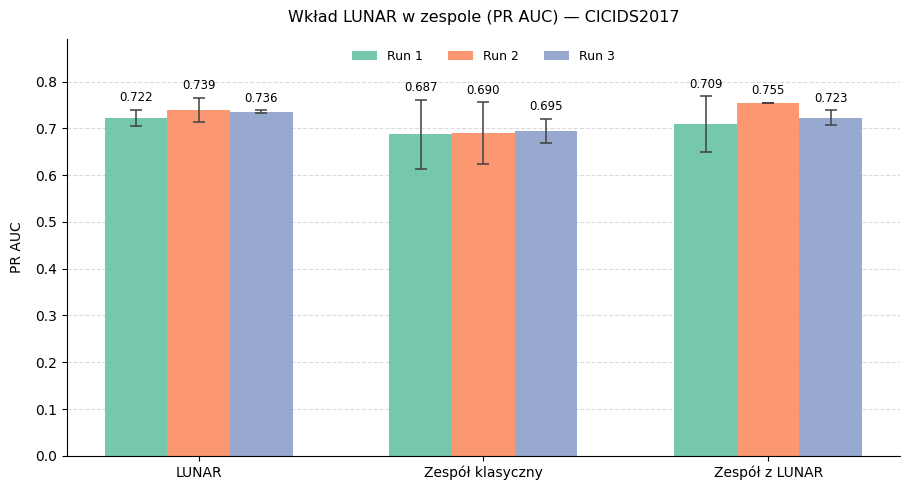

Zapisano: figlunar-contribution-prauc-final-unsw.pdf oraz figlunar-contribution-prauc-final-unsw.png


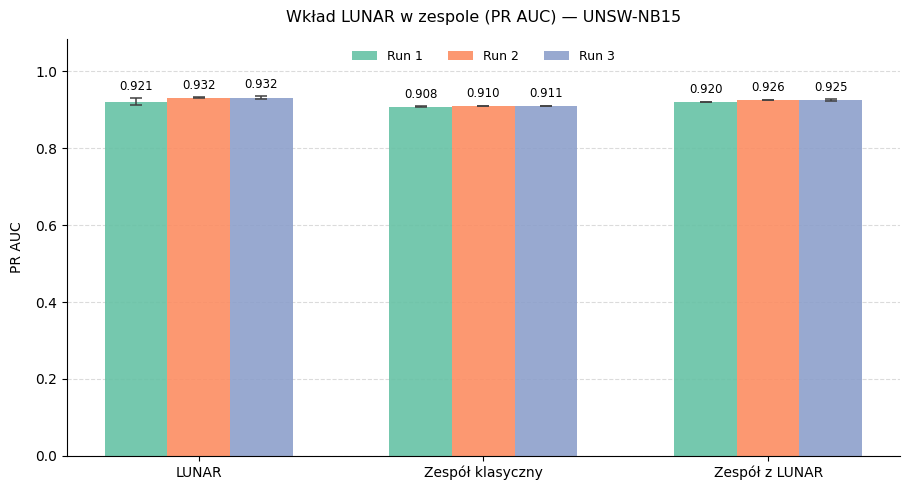

In [30]:
CONTRIBUTION = [('LUNAR', None, 'LUNAR'), ('Ensemble_without_LUNAR', 'rank_mean', 'Zespół klasyczny'),
                ('Ensemble_with_LUNAR', 'rank_mean', 'Zespół z LUNAR')]

bar_per_dataset(CONTRIBUTION, 'AUC_PR', 'figlunar-contribution-prauc-final', 'PR AUC', 'Wkład LUNAR w zespole (PR AUC)')


#### Wykres Liczba fałszywych alarmów (FP) i pominiętych ataków (FN) figoperational-fpfn-ds

Zapisano: figoperational-fpfn-cicids.pdf oraz figoperational-fpfn-cicids.png


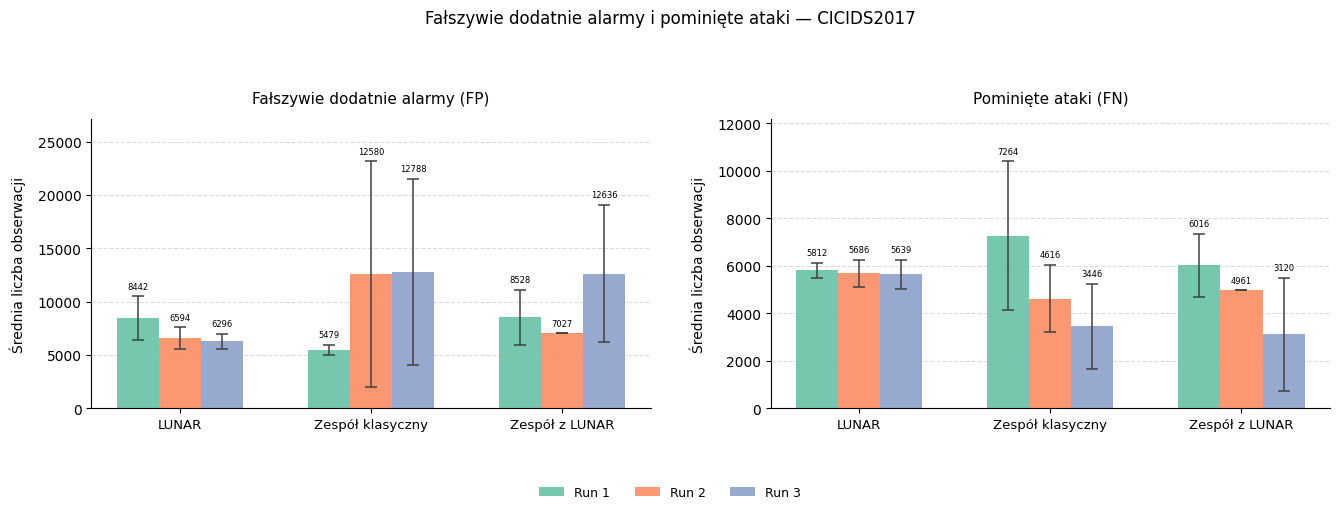

Zapisano: figoperational-fpfn-unsw.pdf oraz figoperational-fpfn-unsw.png


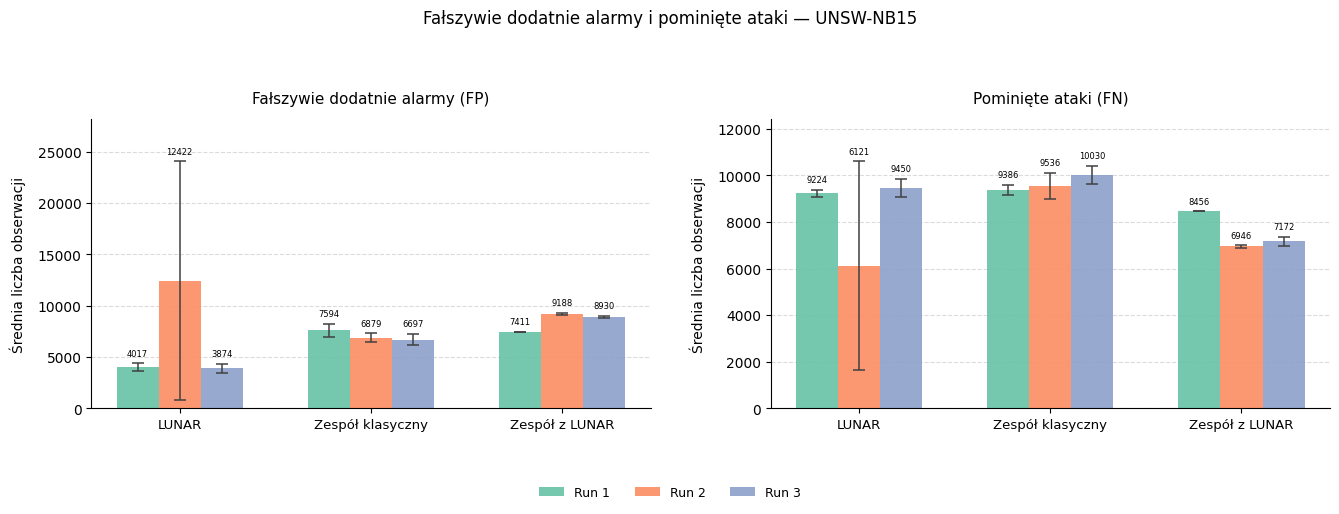

In [31]:
bar_fp_fn_per_dataset(
    specs=CONTRIBUTION,
    stem='figoperational-fpfn',
    source=df_std_clean,
    run_indices=(1, 2, 3),
)

#### Tabela 4.9, 4.10: Porównanie poziomów fuzji LUNAR i LOF przy standardowym progu decyzyjnym

In [32]:
FUSION_CONTINUOUS = [
    (
        'Fusion_Level_Comparison',
        'feature_level_X_only',
        'LR(X)',
    ),
    (
        'Fusion_Level_Comparison',
        'feature_level_X_plus_lunar',
        'LR(X + LUNAR)',
    ),
    (
        'Fusion_Level_Comparison',
        'feature_level_X_plus_lunar_plus_baseline',
        'LR(X + LUNAR + baseline)',
    ),
    (
        'Fusion_Level_Comparison',
        'score_level',
        'Fuzja wyników',
    ),
]


FUSION_CONTINUOUS_METRICS = [
    'AUC_ROC',
    'AUC_PR',
    'Precision',
    'Recall',
    'F1',
]


FUSION_CONTINUOUS_RENAMES = {
    'AUC_ROC': 'ROC AUC',
    'AUC_PR': 'PR AUC',
    'Precision': 'Precision',
    'Recall': 'Recall',
    'F1': 'F1',
}


for ds in DATASETS:
    rows = []

    for model, fusion, label in FUSION_CONTINUOUS:
        summary = run_index_seed_summary(
            df_std_clean,
            dataset=ds,
            model=model,
            fusion=fusion,
            metrics=FUSION_CONTINUOUS_METRICS,
        )

        if summary.empty:
            print(
                f'UWAGA: brak wyników dla '
                f'dataset={ds}, '
                f'model={model}, '
                f'fusion={fusion}'
            )
            continue

        summary = summary.rename(
            columns=FUSION_CONTINUOUS_RENAMES
        )

        summary.insert(
            0,
            'Wariant',
            label,
        )

        rows.extend(
            summary.to_dict('records')
        )

    export_table(
        rows,
        name=(
            f'tab_fusion_continuous_'
            f'{DATASET_SUFFIX[ds]}'
        ),
        caption=(
            f'Porównanie wariantów fuzji zachowujących ciągły wynik '
            f'anomalii dla zbioru {DATASET_LABELS[ds]}. '
            f'Dla każdego numeru runu wartości podano jako średnia '
            f'$\\pm$ odchylenie standardowe między seedami '
            f'$29$ i~$81$.'
        ),
        label=(
            f'tab:fusion-continuous-'
            f'{DATASET_SUFFIX[ds]}'
        ),
    )


,Wariant,Run,ROC AUC,PR AUC,Precision,Recall,F1
0,LR(X),1,0.954 ± 0.001,0.874 ± 0.000,0.772 ± 0.005,0.864 ± 0.035,0.816 ± 0.013
1,LR(X),2,0.954 ± 0.001,0.873 ± 0.000,0.772 ± 0.006,0.864 ± 0.034,0.815 ± 0.012
2,LR(X),3,0.954 ± 0.001,0.873 ± 0.000,0.772 ± 0.006,0.864 ± 0.034,0.815 ± 0.012
3,LR(X + LUNAR),1,0.961 ± 0.001,0.879 ± 0.002,0.773 ± 0.032,0.895 ± 0.057,0.828 ± 0.006
4,LR(X + LUNAR),2,0.960 ± 0.000,0.882 ± 0.002,0.762 ± 0.046,0.895 ± 0.080,0.821 ± 0.007
5,LR(X + LUNAR),3,0.959 ± 0.001,0.880 ± 0.003,0.764 ± 0.041,0.886 ± 0.074,0.818 ± 0.008
6,LR(X + LUNAR + baseline),1,0.964 ± 0.005,0.889 ± 0.012,0.811 ± 0.025,0.870 ± 0.024,0.840 ± 0.025
7,LR(X + LUNAR + baseline),2,0.964 ± 0.004,0.891 ± 0.011,0.786 ± 0.013,0.896 ± 0.080,0.836 ± 0.028
8,LR(X + LUNAR + baseline),3,0.959 ± 0.001,0.879 ± 0.003,0.764 ± 0.041,0.886 ± 0.073,0.818 ± 0.008
9,Fuzja wyników,1,0.877 ± 0.030,0.688 ± 0.019,0.648 ± 0.109,0.762 ± 0.078,0.700 ± 0.096


\begin{table}[H]
\centering
\caption{Porównanie wariantów fuzji zachowujących ciągły wynik anomalii dla zbioru CICIDS2017. Dla każdego numeru runu wartości podano jako średnia $\pm$ odchylenie standardowe między seedami $29$ i~$81$.}
\label{tab:fusion-continuous-cicids}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccccc}
\hline
Wariant & Run & ROC AUC & PR AUC & Precision & Recall & F1 \\
\hline
LR(X) & 1 & $0{,}954 \pm 0{,}001$ & $0{,}874 \pm 0{,}000$ & $0{,}772 \pm 0{,}005$ & $0{,}864 \pm 0{,}035$ & $0{,}816 \pm 0{,}013$ \\
LR(X) & 2 & $0{,}954 \pm 0{,}001$ & $0{,}873 \pm 0{,}000$ & $0{,}772 \pm 0{,}006$ & $0{,}864 \pm 0{,}034$ & $0{,}815 \pm 0{,}012$ \\
LR(X) & 3 & $0{,}954 \pm 0{,}001$ & $0{,}873 \pm 0{,}000$ & $0{,}772 \pm 0{,}006$ & $0{,}864 \pm 0{,}034$ & $0{,}815 \pm 0{,}012$ \\
LR(X + LUNAR) & 1 & $0{,}961 \pm 0{,}001$ & $0{,}879 \pm 0{,}002$ & $0{,}773 \pm 0{,}032$ & $0{,}895 \pm 0{,}057$ & $0{,}828 \pm 0{,}006$ \\
LR(X + LUNAR) & 2 & $0{,}960 \pm 0{,}000$ & $0{,}882 \pm 0{,

,Wariant,Run,ROC AUC,PR AUC,Precision,Recall,F1
0,LR(X),1,0.946 ± 0.000,0.961 ± 0.000,0.815 ± 0.006,0.905 ± 0.005,0.858 ± 0.001
1,LR(X),2,0.946 ± 0.000,0.961 ± 0.000,0.815 ± 0.006,0.905 ± 0.005,0.858 ± 0.001
2,LR(X),3,0.946 ± 0.000,0.961 ± 0.000,0.815 ± 0.006,0.905 ± 0.005,0.858 ± 0.001
3,LR(X + LUNAR),1,0.952 ± 0.006,0.964 ± 0.003,0.814 ± 0.002,0.926 ± 0.022,0.866 ± 0.011
4,LR(X + LUNAR),2,0.948 ± 0.002,0.962 ± 0.001,0.812 ± 0.002,0.911 ± 0.001,0.859 ± 0.002
5,LR(X + LUNAR),3,0.954 ± 0.001,0.966 ± 0.000,0.816 ± 0.007,0.931 ± 0.017,0.870 ± 0.004
6,LR(X + LUNAR + baseline),1,0.951 ± 0.007,0.964 ± 0.004,0.815 ± 0.002,0.925 ± 0.023,0.866 ± 0.011
7,LR(X + LUNAR + baseline),2,0.948 ± 0.001,0.962 ± 0.001,0.808 ± 0.002,0.915 ± 0.004,0.858 ± 0.001
8,LR(X + LUNAR + baseline),3,0.954 ± 0.001,0.966 ± 0.000,0.817 ± 0.008,0.930 ± 0.018,0.870 ± 0.003
9,Fuzja wyników,1,0.897 ± 0.003,0.931 ± 0.001,0.893 ± 0.035,0.763 ± 0.025,0.822 ± 0.000


\begin{table}[H]
\centering
\caption{Porównanie wariantów fuzji zachowujących ciągły wynik anomalii dla zbioru UNSW-NB15. Dla każdego numeru runu wartości podano jako średnia $\pm$ odchylenie standardowe między seedami $29$ i~$81$.}
\label{tab:fusion-continuous-unsw}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccccc}
\hline
Wariant & Run & ROC AUC & PR AUC & Precision & Recall & F1 \\
\hline
LR(X) & 1 & $0{,}946 \pm 0{,}000$ & $0{,}961 \pm 0{,}000$ & $0{,}815 \pm 0{,}006$ & $0{,}905 \pm 0{,}005$ & $0{,}858 \pm 0{,}001$ \\
LR(X) & 2 & $0{,}946 \pm 0{,}000$ & $0{,}961 \pm 0{,}000$ & $0{,}815 \pm 0{,}006$ & $0{,}905 \pm 0{,}005$ & $0{,}858 \pm 0{,}001$ \\
LR(X) & 3 & $0{,}946 \pm 0{,}000$ & $0{,}961 \pm 0{,}000$ & $0{,}815 \pm 0{,}006$ & $0{,}905 \pm 0{,}005$ & $0{,}858 \pm 0{,}001$ \\
LR(X + LUNAR) & 1 & $0{,}952 \pm 0{,}006$ & $0{,}964 \pm 0{,}003$ & $0{,}814 \pm 0{,}002$ & $0{,}926 \pm 0{,}022$ & $0{,}866 \pm 0{,}011$ \\
LR(X + LUNAR) & 2 & $0{,}948 \pm 0{,}002$ & $0{,}962 \pm 0{,}00

#### Tabela 4.11, 4.12 dla fuzji decyzji

In [33]:
FUSION_DECISION = [
    (
        'Fusion_Level_Comparison',
        'decision_level_AND',
        'Decyzja AND',
    ),
    (
        'Fusion_Level_Comparison',
        'decision_level_OR',
        'Decyzja OR',
    ),
]


FUSION_DECISION_METRICS = [
    'Precision',
    'Recall',
    'F1',
    'ConfusionMatrix_FP',
    'ConfusionMatrix_FN',
]


FUSION_DECISION_RENAMES = {
    'Precision': 'Precision',
    'Recall': 'Recall',
    'F1': 'F1',
    'ConfusionMatrix_FP': 'FP',
    'ConfusionMatrix_FN': 'FN',
}


for ds in DATASETS:
    rows = []

    for model, fusion, label in FUSION_DECISION:
        summary = run_index_seed_summary(
            df_std_clean,
            dataset=ds,
            model=model,
            fusion=fusion,
            metrics=FUSION_DECISION_METRICS,
        )

        if summary.empty:
            print(
                f'UWAGA: brak wyników dla '
                f'dataset={ds}, '
                f'model={model}, '
                f'fusion={fusion}'
            )
            continue

        summary = summary.rename(
            columns=FUSION_DECISION_RENAMES
        )

        summary.insert(
            0,
            'Wariant',
            label,
        )

        rows.extend(
            summary.to_dict('records')
        )

    export_table(
        rows,
        name=(
            f'tab_fusion_decision_'
            f'{DATASET_SUFFIX[ds]}'
        ),
        caption=(
            f'Porównanie wariantów fuzji decyzji dla zbioru '
            f'{DATASET_LABELS[ds]} przy standardowych progach '
            f'modeli składowych. Dla każdego numeru runu wartości '
            f'podano jako średnia $\\pm$ odchylenie standardowe '
            f'między seedami $29$ i~$81$. '
            f'Warianty \\textit{{AND}} i~\\textit{{OR}} zwracają '
            f'decyzje binarne, dlatego nie raportowano dla nich '
            f'ROC AUC ani~PR AUC.'
        ),
        label=(
            f'tab:fusion-decision-'
            f'{DATASET_SUFFIX[ds]}'
        ),
    )

,Wariant,Run,Precision,Recall,F1,FP,FN
0,Decyzja AND,1,0.799 ± 0.061,0.547 ± 0.157,0.639 ± 0.091,2854.0 ± 1797.5,8780.0 ± 3037.7
1,Decyzja AND,2,0.788 ± 0.085,0.487 ± 0.064,0.598 ± 0.024,2633.0 ± 1716.9,9538.5 ± 676.7
2,Decyzja AND,3,0.715 ± 0.024,0.546 ± 0.038,0.619 ± 0.034,3996.0 ± 496.4,8381.5 ± 1330.1
3,Decyzja OR,1,0.559 ± 0.026,0.794 ± 0.116,0.653 ± 0.022,12277.5 ± 3065.3,3996.0 ± 2242.9
4,Decyzja OR,2,0.600 ± 0.017,0.787 ± 0.116,0.678 ± 0.032,9900.5 ± 2689.1,3912.5 ± 1945.3
5,Decyzja OR,3,0.558 ± 0.025,0.877 ± 0.041,0.682 ± 0.031,12735.0 ± 260.2,2228.0 ± 592.6


\begin{table}[H]
\centering
\caption{Porównanie wariantów fuzji decyzji dla zbioru CICIDS2017 przy standardowych progach modeli składowych. Dla każdego numeru runu wartości podano jako średnia $\pm$ odchylenie standardowe między seedami $29$ i~$81$. Warianty \textit{AND} i~\textit{OR} zwracają decyzje binarne, dlatego nie raportowano dla nich ROC AUC ani~PR AUC.}
\label{tab:fusion-decision-cicids}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccccc}
\hline
Wariant & Run & Precision & Recall & F1 & FP & FN \\
\hline
Decyzja AND & 1 & $0{,}799 \pm 0{,}061$ & $0{,}547 \pm 0{,}157$ & $0{,}639 \pm 0{,}091$ & $2854{,}0 \pm 1797{,}5$ & $8780{,}0 \pm 3037{,}7$ \\
Decyzja AND & 2 & $0{,}788 \pm 0{,}085$ & $0{,}487 \pm 0{,}064$ & $0{,}598 \pm 0{,}024$ & $2633{,}0 \pm 1716{,}9$ & $9538{,}5 \pm 676{,}7$ \\
Decyzja AND & 3 & $0{,}715 \pm 0{,}024$ & $0{,}546 \pm 0{,}038$ & $0{,}619 \pm 0{,}034$ & $3996{,}0 \pm 496{,}4$ & $8381{,}5 \pm 1330{,}1$ \\
Decyzja OR & 1 & $0{,}559 \pm 0{,}026$ & $0{,}794 \p

,Wariant,Run,Precision,Recall,F1,FP,FN
0,Decyzja AND,1,0.922 ± 0.010,0.745 ± 0.006,0.824 ± 0.000,2782.5 ± 399.5,11236.0 ± 278.6
1,Decyzja AND,2,0.897 ± 0.032,0.763 ± 0.023,0.824 ± 0.000,3891.5 ± 1454.5,10453.0 ± 1011.2
2,Decyzja AND,3,0.919 ± 0.006,0.746 ± 0.003,0.824 ± 0.001,2906.0 ± 244.7,11174.5 ± 112.4
3,Decyzja OR,1,0.819 ± 0.022,0.864 ± 0.018,0.841 ± 0.003,8463.5 ± 1443.2,5986.0 ± 800.4
4,Decyzja OR,2,0.748 ± 0.125,0.899 ± 0.081,0.810 ± 0.041,14485.5 ± 10262.2,4458.0 ± 3578.0
5,Decyzja OR,3,0.831 ± 0.009,0.847 ± 0.011,0.839 ± 0.001,7592.0 ± 572.8,6729.5 ± 484.4


\begin{table}[H]
\centering
\caption{Porównanie wariantów fuzji decyzji dla zbioru UNSW-NB15 przy standardowych progach modeli składowych. Dla każdego numeru runu wartości podano jako średnia $\pm$ odchylenie standardowe między seedami $29$ i~$81$. Warianty \textit{AND} i~\textit{OR} zwracają decyzje binarne, dlatego nie raportowano dla nich ROC AUC ani~PR AUC.}
\label{tab:fusion-decision-unsw}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccccc}
\hline
Wariant & Run & Precision & Recall & F1 & FP & FN \\
\hline
Decyzja AND & 1 & $0{,}922 \pm 0{,}010$ & $0{,}745 \pm 0{,}006$ & $0{,}824 \pm 0{,}000$ & $2782{,}5 \pm 399{,}5$ & $11236{,}0 \pm 278{,}6$ \\
Decyzja AND & 2 & $0{,}897 \pm 0{,}032$ & $0{,}763 \pm 0{,}023$ & $0{,}824 \pm 0{,}000$ & $3891{,}5 \pm 1454{,}5$ & $10453{,}0 \pm 1011{,}2$ \\
Decyzja AND & 3 & $0{,}919 \pm 0{,}006$ & $0{,}746 \pm 0{,}003$ & $0{,}824 \pm 0{,}001$ & $2906{,}0 \pm 244{,}7$ & $11174{,}5 \pm 112{,}4$ \\
Decyzja OR & 1 & $0{,}819 \pm 0{,}022$ & $0{,}864 \pm 

#### Wykres: PR-AUC dla poziomow fuzji -- TYLKO warianty z ciaglym wynikiem (POPRAWKA, wczesniej pominiete)


Zapisano: figfusion-levels-prauc-final-cicids.pdf oraz figfusion-levels-prauc-final-cicids.png


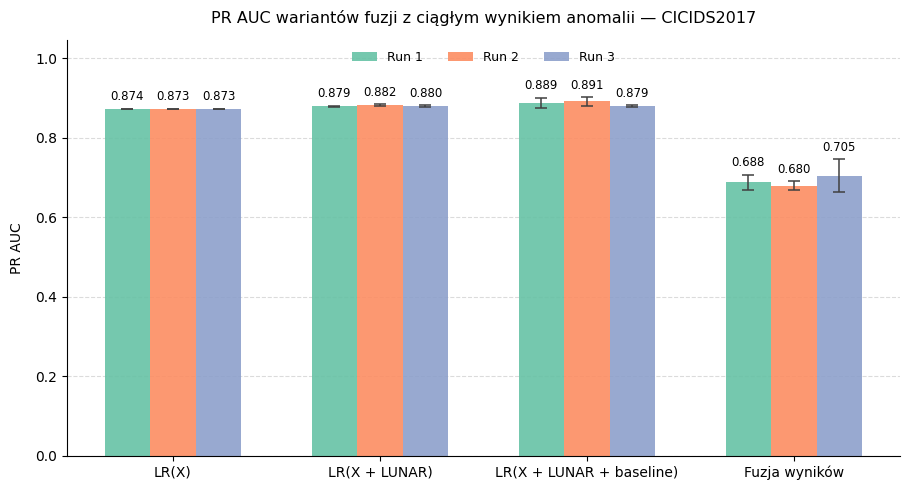

Zapisano: figfusion-levels-prauc-final-unsw.pdf oraz figfusion-levels-prauc-final-unsw.png


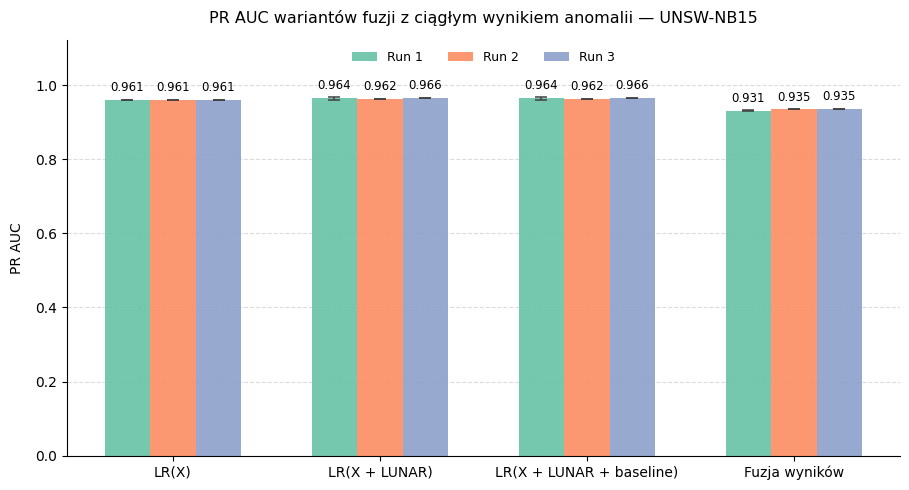

In [34]:
bar_per_dataset(
    specs=FUSION_CONTINUOUS,
    metric='AUC_PR',
    stem='figfusion-levels-prauc-final',
    ylabel='PR AUC',
    title='PR AUC wariantów fuzji z ciągłym wynikiem anomalii',
    source=df_std_clean,
    run_indices=(1, 2, 3),
)


#### Wykres: F1 dla poziomow fuzji


Zapisano: figfusion-levels-f1-final-cicids.pdf oraz figfusion-levels-f1-final-cicids.png


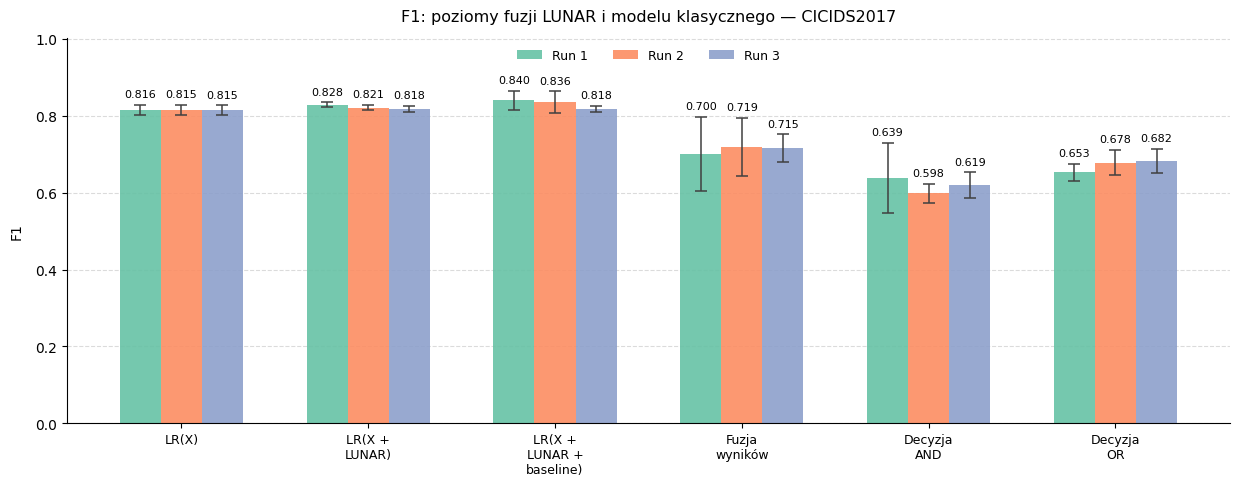

Zapisano: figfusion-levels-f1-final-unsw.pdf oraz figfusion-levels-f1-final-unsw.png


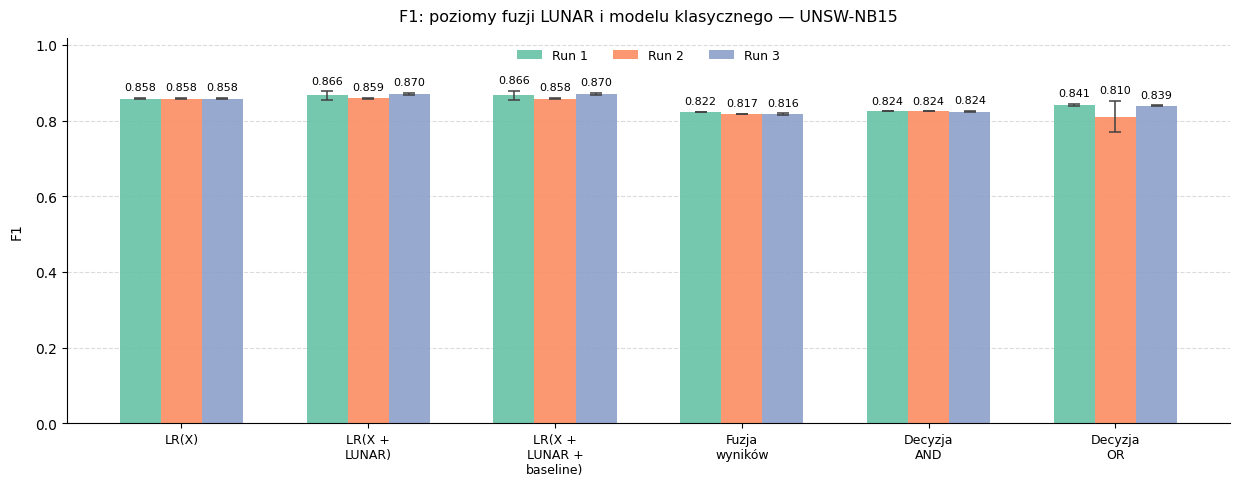

In [37]:
FUSION_ALL = [
    (
        'Fusion_Level_Comparison',
        'feature_level_X_only',
        'LR(X)',
    ),
    (
        'Fusion_Level_Comparison',
        'feature_level_X_plus_lunar',
        'LR(X +\nLUNAR)',
    ),
    (
        'Fusion_Level_Comparison',
        'feature_level_X_plus_lunar_plus_baseline',
        'LR(X +\nLUNAR +\nbaseline)',
    ),
    (
        'Fusion_Level_Comparison',
        'score_level',
        'Fuzja\nwyników',
    ),
    (
        'Fusion_Level_Comparison',
        'decision_level_AND',
        'Decyzja\nAND',
    ),
    (
        'Fusion_Level_Comparison',
        'decision_level_OR',
        'Decyzja\nOR',
    ),
]


def bar_fusion_f1_per_dataset(
    specs,
    stem='figfusion-levels-f1-final',
    source=None,
    run_indices=(1, 2, 3),
):
    if source is None:
        source = df_std_clean

    required_columns = {
        'dataset_name',
        'model_type',
        'fusion_strategy',
        'seed',
        'run_index',
        'F1',
    }

    missing_columns = required_columns - set(source.columns)

    if missing_columns:
        raise KeyError(
            'Brakuje wymaganych kolumn: '
            + ', '.join(sorted(missing_columns))
        )

    run_indices = list(run_indices)
    n_runs = len(run_indices)

    bar_width = 0.22

    offsets = (
        np.arange(n_runs) - (n_runs - 1) / 2
    ) * bar_width

    run_colors = COLORS[:n_runs]

    for ds in DATASETS:
        labels = [
            label
            for _, _, label in specs
        ]

        x = np.arange(len(labels))

        fig, ax = plt.subplots(
            figsize=(12.5, 5.4),
        )

        all_tops = []

        for run_position, run_index in enumerate(run_indices):
            means = []
            stds = []
            n_seeds_list = []

            for model, fusion, _ in specs:
                sub = select(
                    source,
                    dataset=ds,
                    model=model,
                    fusion=fusion,
                ).copy()

                sub = sub[
                    sub['run_index'].eq(run_index)
                ].copy()

                if sub.empty:
                    means.append(np.nan)
                    stds.append(np.nan)
                    n_seeds_list.append(0)
                    continue

                per_seed = (
                    sub
                    .groupby('seed')['F1']
                    .mean()
                    .dropna()
                )

                means.append(per_seed.mean())
                stds.append(per_seed.std(ddof=1))
                n_seeds_list.append(len(per_seed))

            stds_plot = [
                0.0
                if pd.isna(std)
                else std
                for std in stds
            ]

            positions = x + offsets[run_position]

            bars = ax.bar(
                positions,
                means,
                width=bar_width,
                yerr=stds_plot,
                capsize=4,
                color=run_colors[run_position],
                ecolor='#404040',
                alpha=0.90,
                edgecolor='none',
                error_kw={
                    'elinewidth': 1.1,
                    'capthick': 1.1,
                },
                label=f'Run {run_index}',
            )

            for bar, mean, std, n_seeds in zip(
                bars,
                means,
                stds,
                n_seeds_list,
            ):
                if pd.isna(mean):
                    continue

                std_for_label = (
                    0.0
                    if pd.isna(std)
                    else std
                )

                all_tops.append(mean + std_for_label)

                ax.annotate(
                    f'{mean:.3f}',
                    xy=(
                        bar.get_x() + bar.get_width() / 2.0,
                        mean + std_for_label,
                    ),
                    xytext=(0, 4),
                    textcoords='offset points',
                    ha='center',
                    va='bottom',
                    fontsize=8,
                )

        max_top = max(all_tops, default=1.0)

        ax.set_xticks(x)

        ax.set_xticklabels(
            labels,
            rotation=0,
            fontsize=9,
        )

        ax.set_ylabel(
            'F1',
            fontsize=10,
            labelpad=8,
        )

        ax.set_title(
            (
                'F1: poziomy fuzji LUNAR '
                f'i modelu klasycznego — {DATASET_LABELS[ds]}'
            ),
            fontsize=11.5,
            pad=12,
        )

        ax.set_ylim(0, max_top * 1.16)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)

        ax.yaxis.grid(
            True,
            linestyle='--',
            alpha=0.45,
            zorder=0,
        )

        ax.set_axisbelow(True)

        ax.legend(
            loc='upper center',
            ncols=3,
            frameon=False,
            facecolor='white',
            edgecolor='#D0D0D0',
            fontsize=9,
            title_fontsize=9,
        )

        fig.tight_layout(
            rect=(0, 0.08, 1, 1),
        )

        output_name = (
            f'{stem}-{DATASET_SUFFIX.get(ds, norm(ds))}'
        )

        savefig(fig, output_name)

        plt.show()


bar_fusion_f1_per_dataset(
    FUSION_ALL,
    stem='figfusion-levels-f1-final',
)

#### wykres: Krzywa precision-recall

In [52]:
def get_curve_from_record(record):
    if 'pr_curve' not in record.index:
        return None

    curve_data = record.get('pr_curve')

    if curve_data is None:
        return None

    if isinstance(curve_data, float) and pd.isna(curve_data):
        return None

    try:
        if isinstance(curve_data, str):
            curve_data = json.loads(curve_data)

        curve = pd.DataFrame(curve_data)

    except (
        ValueError,
        TypeError,
        KeyError,
        json.JSONDecodeError,
    ):
        return None

    required_columns = {
        'recall',
        'precision',
    }

    if not required_columns.issubset(curve.columns):
        return None

    curve = curve[
        ['recall', 'precision']
    ].copy()

    curve['recall'] = pd.to_numeric(
        curve['recall'],
        errors='coerce',
    )

    curve['precision'] = pd.to_numeric(
        curve['precision'],
        errors='coerce',
    )

    curve = curve.dropna()

    if curve.empty:
        return None

    return curve


def prepare_pr_curve_for_interpolation(curve):
    curve = curve.copy()

    curve['recall'] = curve['recall'].clip(0, 1)
    curve['precision'] = curve['precision'].clip(0, 1)

    curve = (
        curve
        .groupby('recall', as_index=False)['precision']
        .max()
        .sort_values('recall')
    )

    if curve.empty:
        return None, None

    if curve['recall'].iloc[0] > 0:
        curve = pd.concat(
            [
                pd.DataFrame({
                    'recall': [0.0],
                    'precision': [
                        curve['precision'].iloc[0]
                    ],
                }),
                curve,
            ],
            ignore_index=True,
        )

    if curve['recall'].iloc[-1] < 1:
        curve = pd.concat(
            [
                curve,
                pd.DataFrame({
                    'recall': [1.0],
                    'precision': [
                        curve['precision'].iloc[-1]
                    ],
                }),
            ],
            ignore_index=True,
        )

    return (
        curve['recall'].to_numpy(),
        curve['precision'].to_numpy(),
    )


def aggregate_pr_curves_between_seeds(
    frame,
    recall_grid=None,
):

    if recall_grid is None:
        recall_grid = np.linspace(0, 1, 201)

    if frame.empty or 'seed' not in frame.columns:
        return None

    if 'pr_curve' not in frame.columns:
        return None

    seed_curves = []
    seed_auc_values = []

    for seed, seed_frame in frame.groupby('seed'):
        valid = seed_frame[
            seed_frame['pr_curve'].notna()
        ].copy()

        if valid.empty:
            continue

        if 'AUC_PR' in valid.columns:
            valid = valid.dropna(
                subset=['AUC_PR']
            )

            if valid.empty:
                continue

            selected_row = valid.loc[
                valid['AUC_PR'].idxmax()
            ]

        else:
            selected_row = valid.iloc[0]

        curve = get_curve_from_record(selected_row)

        if curve is None:
            continue

        recall, precision = prepare_pr_curve_for_interpolation(
            curve
        )

        if recall is None:
            continue

        interpolated_precision = np.interp(
            recall_grid,
            recall,
            precision,
        )

        seed_curves.append(interpolated_precision)

        if (
            'AUC_PR' in selected_row.index
            and pd.notna(selected_row['AUC_PR'])
        ):
            seed_auc_values.append(
                selected_row['AUC_PR']
            )

    if not seed_curves:
        return None

    precision_matrix = np.vstack(seed_curves)

    precision_mean = precision_matrix.mean(axis=0)

    if precision_matrix.shape[0] > 1:
        precision_std = precision_matrix.std(
            axis=0,
            ddof=1,
        )
    else:
        precision_std = np.zeros_like(
            precision_mean
        )

    auc_mean = (
        np.mean(seed_auc_values)
        if seed_auc_values
        else np.nan
    )

    auc_std = (
        np.std(
            seed_auc_values,
            ddof=1,
        )
        if len(seed_auc_values) > 1
        else np.nan
    )

    return {
        'recall_grid': recall_grid,
        'precision_mean': precision_mean,
        'precision_std': precision_std,
        'auc_mean': auc_mean,
        'auc_std': auc_std,
        'n_seedów': precision_matrix.shape[0],
    }


PR_SPECS = [
    (
        'LUNAR',
        None,
        'LUNAR',
    ),
    (
        'LOF',
        None,
        'LOF',
    ),
    (
        'Fusion_Level_Comparison',
        'feature_level_X_plus_lunar_plus_baseline',
        'Fuzja cech',
    ),
    (
        'Fusion_Level_Comparison',
        'score_level',
        'Fuzja wyników',
    ),
]


def plot_pr_curves_by_run_and_seed(
    specs,
    stem='figfusion-pr-curves-final',
    source=None,
    run_indices=(1, 2, 3),
    show_std_band=False,
):

    if source is None:
        source = df_std_clean

    required_columns = {
        'dataset_name',
        'model_type',
        'fusion_strategy',
        'seed',
        'run_index',
        'AUC_PR',
        'pr_curve',
    }

    missing_columns = required_columns - set(
        source.columns
    )

    if missing_columns:
        raise KeyError(
            'Brakuje wymaganych kolumn: '
            + ', '.join(sorted(missing_columns))
        )

    run_indices = list(run_indices)

    for ds in DATASETS:
        fig, axes = plt.subplots(
            1,
            len(run_indices),
            figsize=(15.0, 6),
            sharex=True,
            sharey=True,
        )

        if len(run_indices) == 1:
            axes = [axes]

        legend_handles = []
        legend_labels = []

        for ax, run_index in zip(
            axes,
            run_indices,
        ):
            plotted_any_curve = False

            for idx, (
                model,
                fusion,
                label,
            ) in enumerate(specs):
                sub = select(
                    source,
                    dataset=ds,
                    model=model,
                    fusion=fusion,
                ).copy()

                sub = sub[
                    sub['run_index'].eq(run_index)
                ].copy()

                if sub.empty:
                    continue

                result = aggregate_pr_curves_between_seeds(
                    sub
                )

                if result is None:
                    continue

                recall_grid = result['recall_grid']
                precision_mean = result['precision_mean']
                precision_std = result['precision_std']
                n_seeds = result['n_seedów']

                line = ax.plot(
                    recall_grid,
                    precision_mean,
                    color=COLORS[idx],
                    linewidth=2.0,
                    label=label,
                )[0]

                if label not in legend_labels:
                    legend_handles.append(line)
                    legend_labels.append(label)


                if show_std_band and n_seeds > 1:
                    lower_band = np.clip(
                        precision_mean - precision_std,
                        0,
                        1,
                    )

                    upper_band = np.clip(
                        precision_mean + precision_std,
                        0,
                        1,
                    )

                    ax.fill_between(
                        recall_grid,
                        lower_band,
                        upper_band,
                        color=COLORS[idx],
                        alpha=0.07,
                        linewidth=0,
                    )

                plotted_any_curve = True

            ax.set_title(
                f'Run {run_index}',
                fontsize=11,
                pad=10,
            )

            ax.set_xlabel(
                'Recall (czułość)',
                fontsize=10,
                labelpad=8,
            )

            ax.set_xlim(-0.02, 1.02)
            ax.set_ylim(-0.02, 1.05)

            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(0.8)
            ax.spines['bottom'].set_linewidth(0.8)

            ax.grid(
                True,
                linestyle='--',
                alpha=0.45,
                zorder=0,
            )

            ax.set_axisbelow(True)

        axes[0].set_ylabel(
            'Precision (precyzja)',
            fontsize=10,
            labelpad=8,
        )

        fig.suptitle(
            (
                'Krzywe precision-recall: modele bazowe '
                f'i warianty fuzji — {DATASET_LABELS[ds]}'
            ),
            fontsize=12,
            y=0.99,
        )

        fig.legend(
            legend_handles,
            legend_labels,
            loc='upper center',
            bbox_to_anchor=(0.5, 0.935),
            ncol=len(legend_labels),
            frameon=False,
            facecolor='white',
            edgecolor='#D0D0D0',
            fontsize=9,
        )


        fig.tight_layout(
            rect=(0.02, 0.07, 1, 0.84),
            w_pad=2.3,
        )

        output_name = (
            f'{stem}-'
            f'{DATASET_SUFFIX.get(ds, norm(ds))}'
        )

        savefig(
            fig,
            output_name,
        )

        plt.show()

Zapisano: figfusion-pr-curves-final-cicids.pdf oraz figfusion-pr-curves-final-cicids.png


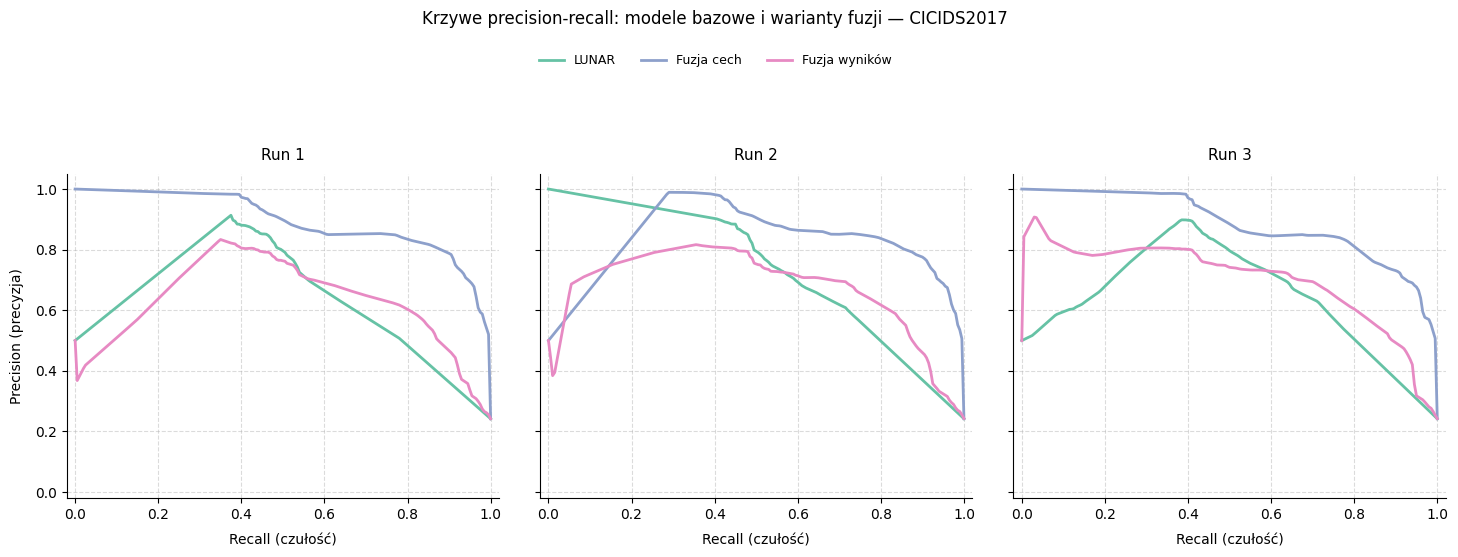

Zapisano: figfusion-pr-curves-final-unsw.pdf oraz figfusion-pr-curves-final-unsw.png


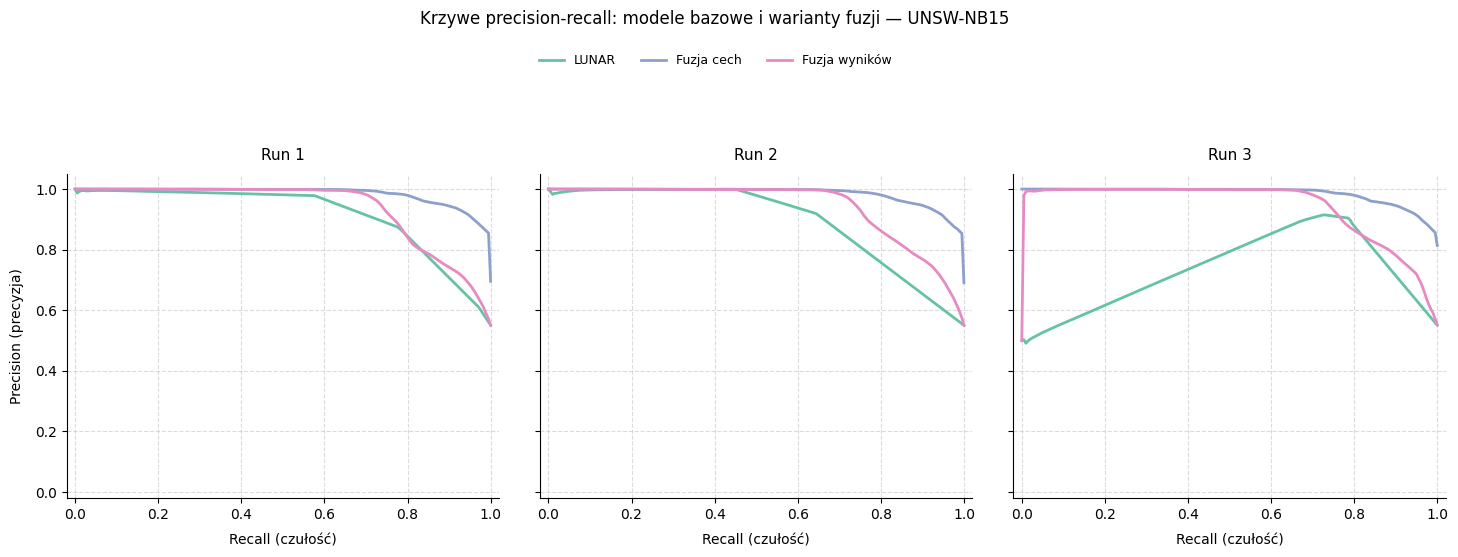

In [53]:
plot_pr_curves_by_run_and_seed(
    PR_SPECS,
    stem='figfusion-pr-curves-final',
    source=df_std_clean,
    run_indices=(1, 2, 3),
)

#### Tabela 4.13 i 4.14 - wrażliwość na liczbę epok

In [56]:
EPOCHS_MODEL_TYPE = 'LUNAR_Epochs_v2'

EPOCHS_METRICS = [
    'AUC_PR',
    'F1',
    'runtime_train',
]


EPOCHS_RENAMES = {
    'AUC_PR': 'PR AUC',
    'F1': 'F1',
    'runtime_train': 'Czas uczenia [s]',
}


epochs = df_std[
    df_std['model_type']
    .map(norm)
    .eq(norm(EPOCHS_MODEL_TYPE))
].copy()


if epochs.empty:
    print(
        'UWAGA: nie znaleziono rekordów '
        f'dla model_type={EPOCHS_MODEL_TYPE}'
    )

else:
    epoch_col = None

    for candidate in [
        'hyperparameters.n_epochs',
        'hyperparameters.epochs',
    ]:
        if candidate in epochs.columns:
            epoch_col = candidate
            break

    if epoch_col is None:
        raise KeyError(
            'Nie znaleziono kolumny z liczbą epok. '
            'Sprawdzono: hyperparameters.n_epochs oraz '
            'hyperparameters.epochs.'
        )

    epochs[epoch_col] = pd.to_numeric(
        epochs[epoch_col],
        errors='coerce',
    )

    epochs = epochs[
        epochs[epoch_col].notna()
    ].copy()

    epochs['Liczba epok'] = (
        epochs[epoch_col]
        .astype(int)
    )

    print(
        f'Używana kolumna z liczbą epok: {epoch_col}'
    )

    print('\nKontrola liczby rekordów:')
    display(
        epochs.groupby(
            [
                'dataset_name',
                'Liczba epok',
                'run_index',
                'seed',
            ],
            dropna=False,
        )
        .size()
        .reset_index(name='liczba rekordów')
        .sort_values(
            [
                'dataset_name',
                'Liczba epok',
                'run_index',
                'seed',
            ]
        )
    )

    for ds in DATASETS:
        dataset_epochs = epochs[
            epochs['dataset_name'].eq(ds)
        ].copy()

        if dataset_epochs.empty:
            print(
                f'UWAGA: brak wyników liczby epok '
                f'dla zbioru {DATASET_LABELS[ds]}'
            )
            continue

        rows = []

        available_epochs = sorted(
            dataset_epochs['Liczba epok'].unique()
        )

        for epoch in available_epochs:
            epoch_data = dataset_epochs[
                dataset_epochs['Liczba epok'].eq(epoch)
            ].copy()

            for run_index in sorted(
                epoch_data['run_index']
                .dropna()
                .astype(int)
                .unique()
            ):
                run_data = epoch_data[
                    epoch_data['run_index'].eq(run_index)
                ].copy()

                if run_data.empty:
                    continue

                stats = seed_stats_for_run(
                    run_data,
                    metrics=EPOCHS_METRICS,
                )

                row = {
                    'Liczba epok': int(epoch),
                    'Run': int(run_index),
                }

                for metric in EPOCHS_METRICS:
                    decimals = (
                        1
                        if metric == 'runtime_train'
                        else 3
                    )

                    output_name = EPOCHS_RENAMES[metric]

                    row[output_name] = pm_n(
                        stats[f'{metric}_mean'],
                        stats[f'{metric}_std'],
                        stats['n_seedów'],
                        nd=decimals,
                    )

                rows.append(row)

        table_name = (
            f'tab_lunar_epochs_'
            f'{DATASET_SUFFIX[ds]}'
        )

        table_caption = (
            f'Wpływ liczby epok na~wyniki pojedynczego modelu LUNAR '
            f'dla zbioru {DATASET_LABELS[ds]}. '
            f'Dla każdego numeru runu wartości podano jako średnia '
            f'$\\pm$ odchylenie standardowe między seedami '
            f'$29$ i~$81$.'
        )

        table_label = (
            f'tab:lunar-epochs-'
            f'{DATASET_SUFFIX[ds]}'
        )

        export_table(
            rows,
            name=table_name,
            caption=table_caption,
            label=table_label,
        )

Używana kolumna z liczbą epok: hyperparameters.n_epochs

Kontrola liczby rekordów:


,dataset_name,Liczba epok,run_index,seed,liczba rekordów
0,CICIDS,25,1,29,1
1,CICIDS,25,1,81,1
2,CICIDS,25,2,29,1
3,CICIDS,25,2,81,1
4,CICIDS,25,3,29,1
...,...,...,...,...,...
91,UNSW_NB15,300,1,81,1
92,UNSW_NB15,300,2,29,1
93,UNSW_NB15,300,2,81,1
94,UNSW_NB15,300,3,29,1


,Liczba epok,Run,PR AUC,F1,Czas uczenia [s]
0,25,1,0.717 ± 0.018,0.648 ± 0.025,42.3 ± 28.2
1,25,2,0.711 ± 0.019,0.641 ± 0.026,46.1 ± 31.7
2,25,3,0.731 ± 0.003,0.678 ± 0.016,46.2 ± 19.2
3,50,1,0.719 ± 0.014,0.653 ± 0.018,77.9 ± 53.8
4,50,2,0.711 ± 0.019,0.641 ± 0.026,84.9 ± 60.4
5,50,3,0.731 ± 0.003,0.678 ± 0.016,85.0 ± 39.0
6,75,1,0.719 ± 0.014,0.653 ± 0.018,112.4 ± 79.2
7,75,2,0.691 ± 0.047,0.650 ± 0.013,124.2 ± 90.5
8,75,3,0.732 ± 0.003,0.678 ± 0.015,124.2 ± 57.9
9,100,1,0.719 ± 0.014,0.654 ± 0.019,147.9 ± 103.8


\begin{table}[H]
\centering
\caption{Wpływ liczby epok na~wyniki pojedynczego modelu LUNAR dla zbioru CICIDS2017. Dla każdego numeru runu wartości podano jako średnia $\pm$ odchylenie standardowe między seedami $29$ i~$81$.}
\label{tab:lunar-epochs-cicids}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccc}
\hline
Liczba epok & Run & PR AUC & F1 & Czas uczenia [s] \\
\hline
25 & 1 & $0{,}717 \pm 0{,}018$ & $0{,}648 \pm 0{,}025$ & $42{,}3 \pm 28{,}2$ \\
25 & 2 & $0{,}711 \pm 0{,}019$ & $0{,}641 \pm 0{,}026$ & $46{,}1 \pm 31{,}7$ \\
25 & 3 & $0{,}731 \pm 0{,}003$ & $0{,}678 \pm 0{,}016$ & $46{,}2 \pm 19{,}2$ \\
50 & 1 & $0{,}719 \pm 0{,}014$ & $0{,}653 \pm 0{,}018$ & $77{,}9 \pm 53{,}8$ \\
50 & 2 & $0{,}711 \pm 0{,}019$ & $0{,}641 \pm 0{,}026$ & $84{,}9 \pm 60{,}4$ \\
50 & 3 & $0{,}731 \pm 0{,}003$ & $0{,}678 \pm 0{,}016$ & $85{,}0 \pm 39{,}0$ \\
75 & 1 & $0{,}719 \pm 0{,}014$ & $0{,}653 \pm 0{,}018$ & $112{,}4 \pm 79{,}2$ \\
75 & 2 & $0{,}691 \pm 0{,}047$ & $0{,}650 \pm 0{,}013$ & $124{,

,Liczba epok,Run,PR AUC,F1,Czas uczenia [s]
0,25,1,0.921 ± 0.010,0.841 ± 0.002,64.3 ± 18.6
1,25,2,0.930 ± 0.000,0.839 ± 0.002,37.7 ± 3.3
2,25,3,0.929 ± 0.001,0.840 ± 0.001,54.2 ± 18.7
3,50,1,0.921 ± 0.011,0.841 ± 0.003,118.9 ± 40.0
4,50,2,0.931 ± 0.001,0.838 ± 0.002,70.1 ± 7.3
5,50,3,0.930 ± 0.001,0.840 ± 0.001,98.5 ± 34.7
6,75,1,0.921 ± 0.010,0.840 ± 0.002,173.4 ± 60.5
7,75,2,0.932 ± 0.001,0.838 ± 0.002,99.9 ± 10.0
8,75,3,0.930 ± 0.002,0.841 ± 0.002,142.7 ± 50.3
9,100,1,0.921 ± 0.011,0.840 ± 0.002,228.0 ± 80.5


\begin{table}[H]
\centering
\caption{Wpływ liczby epok na~wyniki pojedynczego modelu LUNAR dla zbioru UNSW-NB15. Dla każdego numeru runu wartości podano jako średnia $\pm$ odchylenie standardowe między seedami $29$ i~$81$.}
\label{tab:lunar-epochs-unsw}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccc}
\hline
Liczba epok & Run & PR AUC & F1 & Czas uczenia [s] \\
\hline
25 & 1 & $0{,}921 \pm 0{,}010$ & $0{,}841 \pm 0{,}002$ & $64{,}3 \pm 18{,}6$ \\
25 & 2 & $0{,}930 \pm 0{,}000$ & $0{,}839 \pm 0{,}002$ & $37{,}7 \pm 3{,}3$ \\
25 & 3 & $0{,}929 \pm 0{,}001$ & $0{,}840 \pm 0{,}001$ & $54{,}2 \pm 18{,}7$ \\
50 & 1 & $0{,}921 \pm 0{,}011$ & $0{,}841 \pm 0{,}003$ & $118{,}9 \pm 40{,}0$ \\
50 & 2 & $0{,}931 \pm 0{,}001$ & $0{,}838 \pm 0{,}002$ & $70{,}1 \pm 7{,}3$ \\
50 & 3 & $0{,}930 \pm 0{,}001$ & $0{,}840 \pm 0{,}001$ & $98{,}5 \pm 34{,}7$ \\
75 & 1 & $0{,}921 \pm 0{,}010$ & $0{,}840 \pm 0{,}002$ & $173{,}4 \pm 60{,}5$ \\
75 & 2 & $0{,}932 \pm 0{,}001$ & $0{,}838 \pm 0{,}002$ & $99{,}9 \p

#### Wykres - wrażliwość na liczbę epok

Zapisano: fig-lunar-epochs-by-run.pdf oraz fig-lunar-epochs-by-run.png


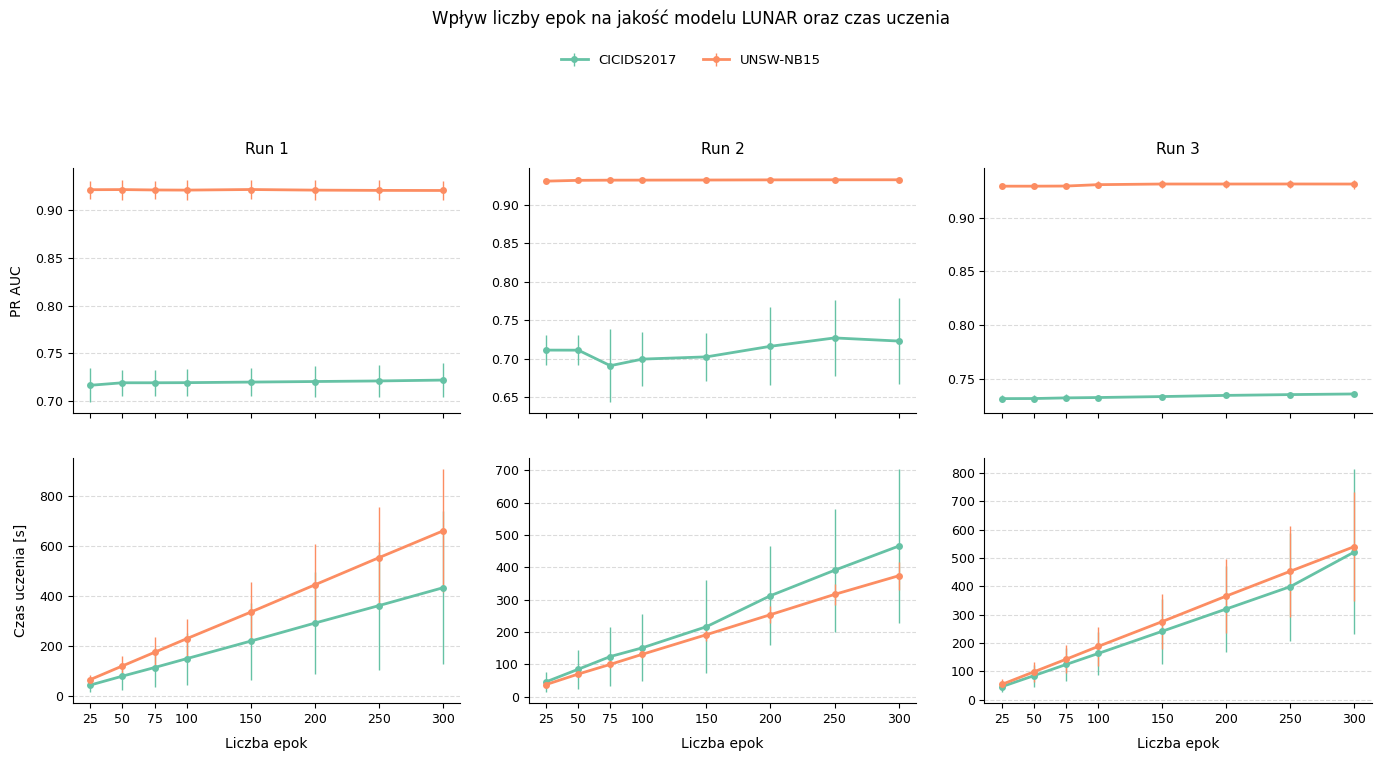

In [60]:
EPOCHS_PLOT_METRICS = [
    'AUC_PR',
    'runtime_train',
]

EPOCHS_PLOT_TITLES = [
    'Jakość detekcji (PR AUC)',
    'Czas uczenia',
]

EPOCHS_PLOT_YLABELS = [
    'PR AUC',
    'Czas uczenia [s]',
]


if epochs.empty:
    print(
        'UWAGA: brak danych dla modelu '
        'LUNAR_Epochs_v2.'
    )

elif 'Liczba epok' not in epochs.columns:
    raise KeyError(
        'Brakuje kolumny "Liczba epok". '
        'Uruchom najpierw blok przygotowania danych '
        'dla analizy liczby epok.'
    )

else:
    epoch_summary = (
        epochs
        .groupby(
            [
                'dataset_name',
                'run_index',
                'Liczba epok',
            ],
            dropna=False,
        )[
            [
                'AUC_PR',
                'runtime_train',
            ]
        ]
        .agg(
            ['mean', 'std', 'count']
        )
        .reset_index()
    )

    available_runs = sorted(
        epoch_summary['run_index']
        .dropna()
        .astype(int)
        .unique()
    )

    if not available_runs:
        raise ValueError(
            'Nie znaleziono wartości run_index '
            'dla analizy liczby epok.'
        )

    fig, axes = plt.subplots(
        nrows=2,
        ncols=len(available_runs),
        figsize=(14.5, 8),
        sharex='col',
    )

    if len(available_runs) == 1:
        axes = np.array(axes).reshape(2, 1)

    legend_handles = []
    legend_labels = []

    for col_idx, run_index in enumerate(
        available_runs
    ):
        for row_idx, (
            metric,
            title_str,
            y_label,
        ) in enumerate(
            zip(
                EPOCHS_PLOT_METRICS,
                EPOCHS_PLOT_TITLES,
                EPOCHS_PLOT_YLABELS,
            )
        ):
            ax = axes[row_idx, col_idx]

            for ds_idx, ds in enumerate(DATASETS):
                q = epoch_summary[
                    epoch_summary['dataset_name']
                    .eq(ds)
                    &
                    epoch_summary['run_index']
                    .eq(run_index)
                ].copy()

                if q.empty:
                    continue

                q = q.sort_values(
                    'Liczba epok'
                )

                mean_values = q[
                    (metric, 'mean')
                ].to_numpy()

                std_values = (
                    q[(metric, 'std')]
                    .fillna(0)
                    .to_numpy()
                )

                line = ax.errorbar(
                    q['Liczba epok'],
                    mean_values,
                    yerr=std_values,
                    color=COLORS[ds_idx],
                    label=DATASET_LABELS[ds],
                    marker='o',
                    markersize=5,
                    markeredgewidth=0,
                    linestyle='-',
                    linewidth=2.0,
                    elinewidth=1.0,
                    capsize=3,
                    capthick=1.0,
                    zorder=3,
                )

                if (
                    row_idx == 0
                    and DATASET_LABELS[ds]
                    not in legend_labels
                ):
                    legend_handles.append(line)
                    legend_labels.append(
                        DATASET_LABELS[ds]
                    )

            if row_idx == 0:
                ax.set_title(
                    f'Run {int(run_index)}',
                    fontsize=11,
                    pad=10,
                )

            if col_idx == 0:
                ax.set_ylabel(
                    y_label,
                    fontsize=10,
                    labelpad=8,
                )

            if row_idx == 1:
                ax.set_xlabel(
                    'Liczba epok',
                    fontsize=10,
                    labelpad=8,
                )

            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(0.8)
            ax.spines['bottom'].set_linewidth(0.8)

            ax.yaxis.grid(
                True,
                linestyle='--',
                alpha=0.45,
                zorder=0,
            )

            ax.set_axisbelow(True)

            ax.tick_params(
                axis='both',
                labelsize=9,
            )

            available_epochs = sorted(
                q['Liczba epok']
                .dropna()
                .astype(int)
                .unique()
            )

            ax.set_xticks(
                available_epochs
            )

    fig.legend(
        legend_handles,
        legend_labels,
        loc='upper center',
        ncol=len(legend_labels),
        frameon=False,
        facecolor='white',
        fontsize=9.5,
        bbox_to_anchor=(0.5, 0.955),
    )

    fig.suptitle(
        (
            'Wpływ liczby epok na jakość modelu LUNAR '
            'oraz czas uczenia'
        ),
        fontsize=12,
        y=0.995,
    )


    fig.tight_layout(
        rect=(0.02, 0.05, 0.98, 0.89),
        h_pad=2.9,
        w_pad=2.2,
    )

    savefig(
        fig,
        'fig-lunar-epochs',
    )

    plt.show()

#### Odporność - wykresy

In [67]:
robust = df_std[df_std['model_type'].map(norm).eq(norm('Robustness_Analysis'))].copy()

def scenario(row):
    if 'hyperparameters.noise' in row and pd.notna(row['hyperparameters.noise']) and row['hyperparameters.noise'] > 0:
        return 'Szum', row['hyperparameters.noise']
    if 'hyperparameters.feature_dropout' in row and pd.notna(row['hyperparameters.feature_dropout']) and row['hyperparameters.feature_dropout'] > 0:
        return 'Dropout cech', row['hyperparameters.feature_dropout']
    return 'Nierównowaga', row.get('hyperparameters.imbalance_factor_test', np.nan)

if not robust.empty:
    robust[['Scenariusz', 'Poziom']] = robust.apply(lambda r: pd.Series(scenario(r)), axis=1)
    summary = robust.groupby(['dataset_name', 'fusion_strategy', 'Scenariusz', 'Poziom'])[
        ['AUC_PR', 'F1', 'Precision', 'Recall', 'ConfusionMatrix_FP']].agg(['mean', 'std']).reset_index()
    summary.columns = ['_'.join(c).strip('_') for c in summary.columns]
else:
    summary = pd.DataFrame()
    print("UWAGA: brak wierszy Robustness_Analysis w df_std - tabela będzie pusta.")


def esc_text(s):
    s = str(s)
    replacements = [
        ("\\", r"\textbackslash{}"),
        ("&", r"\&"), ("%", r"\%"), ("$", r"\$"), ("#", r"\#"),
        ("_", r"\_"), ("{", r"\{"), ("}", r"\}"),
        ("~", r"\textasciitilde{}"), ("^", r"\textasciicircum{}"),
    ]
    for old, new in replacements:
        s = s.replace(old, new)
    return s

METRIC_LABELS = {
    'AUC_PR': 'PR AUC',
    'F1': 'F1',
    'Precision': 'Precision',
    'Recall': 'Recall',
    'ConfusionMatrix_FP': 'Liczba fałszywych alarmów (FP)',
}


METRIC_FILE_SUFFIX = {
    'AUC_PR': 'auc-pr',
    'F1': 'f1',
    'Precision': 'precision',
    'Recall': 'recall',
    'ConfusionMatrix_FP': 'fp',
}


DATASET_MARKERS = {
    'CICIDS2017': 'o',
    'UNSW_NB15': 's',
    'UNSW-NB15': 's',
}


DATASET_LINESTYLES = {
    'CICIDS2017': '-',
    'UNSW_NB15': '--',
    'UNSW-NB15': '--',
}


def display_robustness_method(
    model_type,
    fusion_strategy,
):

    if (
        pd.notna(fusion_strategy)
        and str(fusion_strategy).strip()
        and norm(fusion_strategy) not in {
            norm('none'),
            norm('brak'),
            norm('nan'),
            norm('null'),
        }
    ):
        return str(fusion_strategy)

    if (
        pd.notna(model_type)
        and str(model_type).strip()
    ):
        return str(model_type)

    return 'Model bazowy'


def plot_robustness_scenario(
    label,
    stem,
    metrics,
    source=None,
):

    if source is None:
        source = robust

    required_columns = {
        'Scenariusz',
        'dataset_name',
        'model_type',
        'fusion_strategy',
        'Poziom',
        'run_index',
        'seed',
    }

    missing_columns = required_columns - set(
        source.columns
    )

    if missing_columns:
        raise KeyError(
            'Brakuje wymaganych kolumn: '
            + ', '.join(sorted(missing_columns))
        )

    q = source[
        source['Scenariusz'].eq(label)
    ].copy()

    if q.empty:
        print(
            f'Brak danych dla scenariusza: {label}'
        )
        return

    q['Nazwa metody'] = q.apply(
        lambda row: display_robustness_method(
            row['model_type'],
            row['fusion_strategy'],
        ),
        axis=1,
    )

    available_runs = sorted(
        q['run_index']
        .dropna()
        .astype(int)
        .unique()
    )

    if not available_runs:
        raise ValueError(
            f'Brak wartości run_index '
            f'dla scenariusza: {label}'
        )

    all_methods = sorted(
        q['Nazwa metody']
        .dropna()
        .unique()
    )

    method_colors = {
        method: COLORS[
            idx % len(COLORS)
        ]
        for idx, method in enumerate(all_methods)
    }

    for metric in metrics:
        if metric not in q.columns:
            print(
                f'Brak kolumny {metric} '
                f'dla scenariusza: {label}'
            )
            continue

        summary = (
            q.groupby(
                [
                    'dataset_name',
                    'Nazwa metody',
                    'run_index',
                    'Poziom',
                ],
                dropna=False,
            )[metric]
            .agg(
                ['mean', 'std', 'count']
            )
            .reset_index()
            .rename(
                columns={
                    'mean': 'średnia',
                    'std': 'odchylenie_std',
                    'count': 'n_seedów',
                }
            )
        )

        fig, axes = plt.subplots(
            1,
            len(available_runs),
            figsize=(
                5.0 * len(available_runs),
                6.0,
            ),
            sharey=False,
        )

        if len(available_runs) == 1:
            axes = [axes]

        legend_handles = []
        legend_labels = []

        metric_label = METRIC_LABELS.get(
            metric,
            metric,
        )

        for ax, run_index in zip(
            axes,
            available_runs,
        ):
            run_summary = summary[
                summary['run_index'].eq(run_index)
            ].copy()

            all_y_values = []

            for ds in DATASETS:
                for method in all_methods:
                    z = run_summary[
                        run_summary['dataset_name'].eq(ds)
                        &
                        run_summary['Nazwa metody'].eq(method)
                    ].copy()

                    if z.empty:
                        continue

                    z = z.sort_values('Poziom')

                    mean_values = z['średnia'].to_numpy()

                    std_values = (
                        z['odchylenie_std']
                        .fillna(0)
                        .to_numpy()
                    )

                    all_y_values.extend(mean_values)

                    marker = DATASET_MARKERS.get(
                        ds,
                        'o',
                    )

                    linestyle = DATASET_LINESTYLES.get(
                        ds,
                        '-',
                    )

                    curve_label = (
                        f'{DATASET_LABELS.get(ds, ds)}'
                        f' — {method}'
                    )

                    line = ax.errorbar(
                        z['Poziom'],
                        mean_values,
                        yerr=std_values,
                        color=method_colors[method],
                        marker=marker,
                        linestyle=linestyle,
                        linewidth=2.0,
                        markersize=5.5,
                        markeredgewidth=0,
                        elinewidth=1.0,
                        capsize=3,
                        capthick=1.0,
                        label=curve_label,
                        zorder=3,
                    )

                    if curve_label not in legend_labels:
                        legend_handles.append(line)
                        legend_labels.append(curve_label)

            ax.set_title(
                f'Run {int(run_index)}',
                fontsize=11,
                pad=10,
            )

            ax.set_xlabel(
                'Poziom zaburzenia',
                fontsize=10,
                labelpad=8,
            )

            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(0.8)
            ax.spines['bottom'].set_linewidth(0.8)

            ax.yaxis.grid(
                True,
                linestyle='--',
                alpha=0.45,
                zorder=0,
            )

            ax.set_axisbelow(True)

            ax.tick_params(
                axis='both',
                labelsize=9,
            )

            if metric in [
                'AUC_PR',
                'F1',
                'Precision',
                'Recall',
            ]:
                ax.set_ylim(-0.02, 1.05)

            elif all_y_values:
                y_min = min(all_y_values)
                y_max = max(all_y_values)

                y_range = (
                    y_max - y_min
                    if y_max != y_min
                    else max(1.0, y_max * 0.1)
                )

                ax.set_ylim(
                    max(0, y_min - 0.08 * y_range),
                    y_max + 0.18 * y_range,
                )

        axes[0].set_ylabel(
            metric_label,
            fontsize=10,
            labelpad=8,
        )

        fig.suptitle(
            f'{metric_label} — scenariusz: {label}',
            fontsize=12,
            y=0.995,
        )

        fig.legend(
            legend_handles,
            legend_labels,
            loc='upper center',
            bbox_to_anchor=(0.5, 0.935),
            ncol=min(3, len(legend_labels)),
            frameon=False,
            facecolor='white',
            fontsize=8.5,
        )

        suffix = METRIC_FILE_SUFFIX.get(
            metric,
            metric.lower(),
        )

        output_name = (
            f'{stem}-{suffix}'
        )

        fig.tight_layout(
            rect=(0.02, 0.07, 0.98, 0.84),
            w_pad=2.1,
        )

        savefig(
            fig,
            output_name,
        )

        plt.show()

Zapisano: figrobustness-imbalance-final-auc-pr.pdf oraz figrobustness-imbalance-final-auc-pr.png


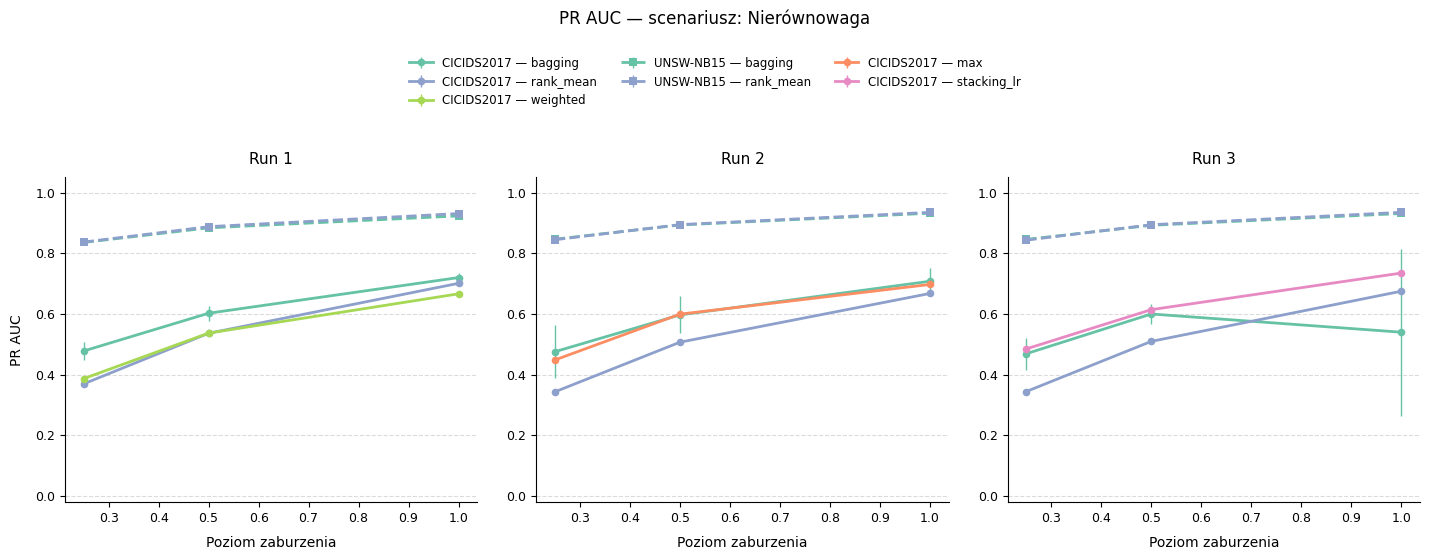

Zapisano: figrobustness-imbalance-final-f1.pdf oraz figrobustness-imbalance-final-f1.png


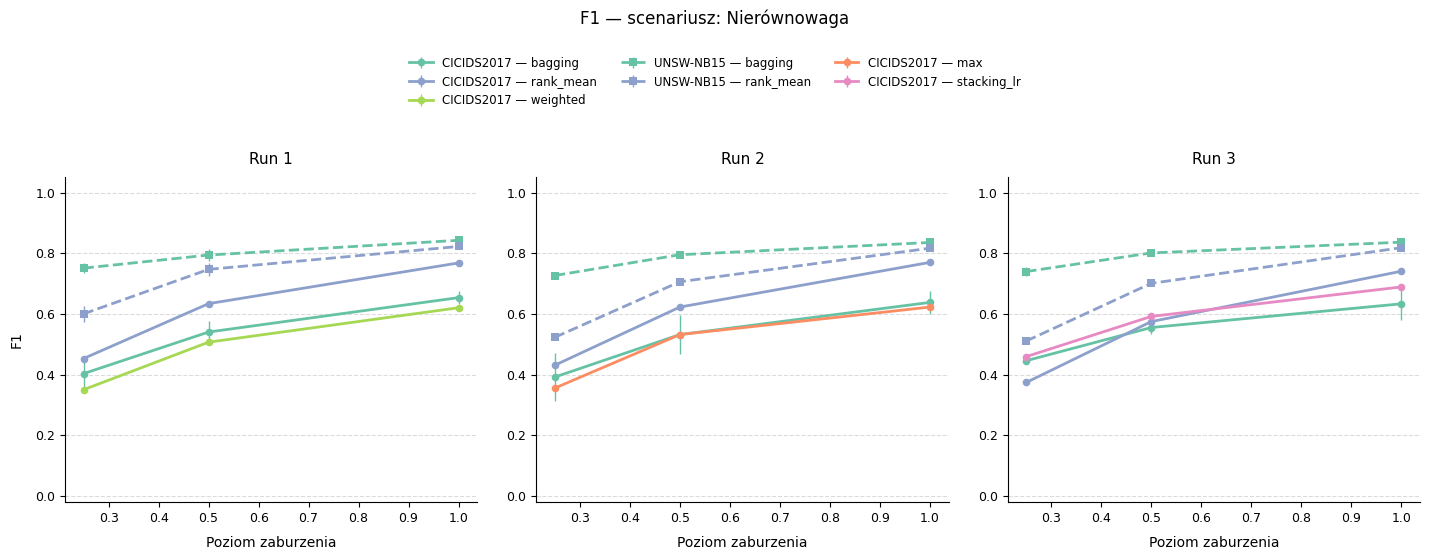

In [68]:
plot_robustness_scenario(
    'Nierównowaga',
    'figrobustness-imbalance-final',
    [
        'AUC_PR',
        'F1',
    ],
)

Zapisano: figrobustness-noise-final-auc-pr.pdf oraz figrobustness-noise-final-auc-pr.png


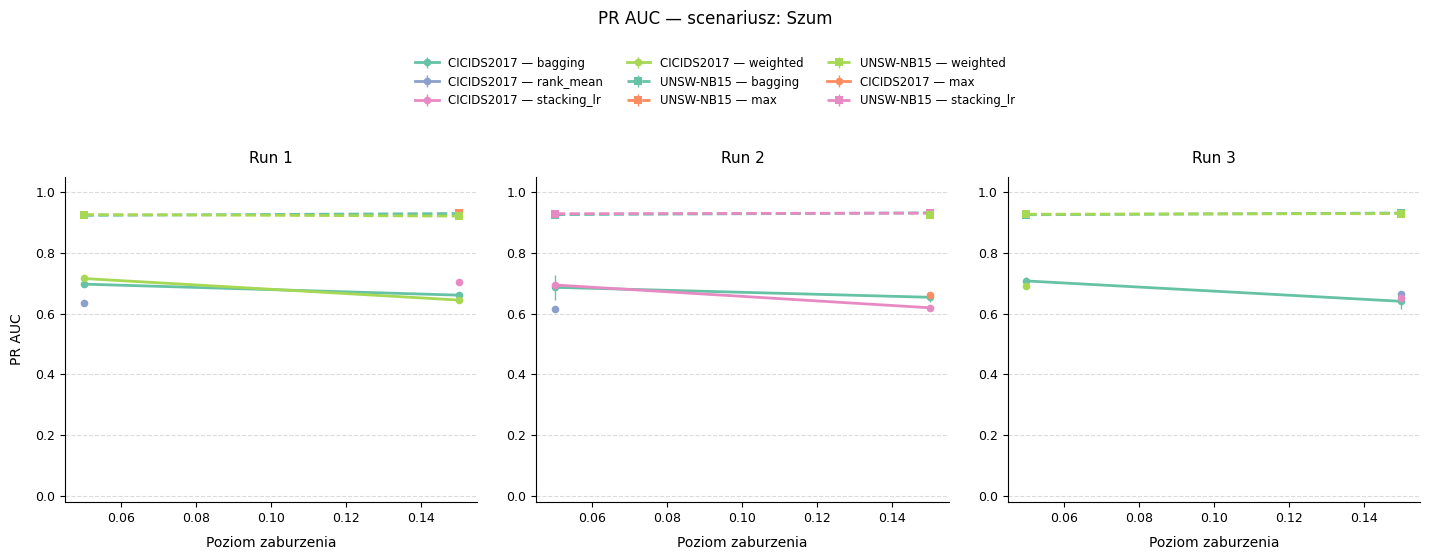

Zapisano: figrobustness-noise-final-f1.pdf oraz figrobustness-noise-final-f1.png


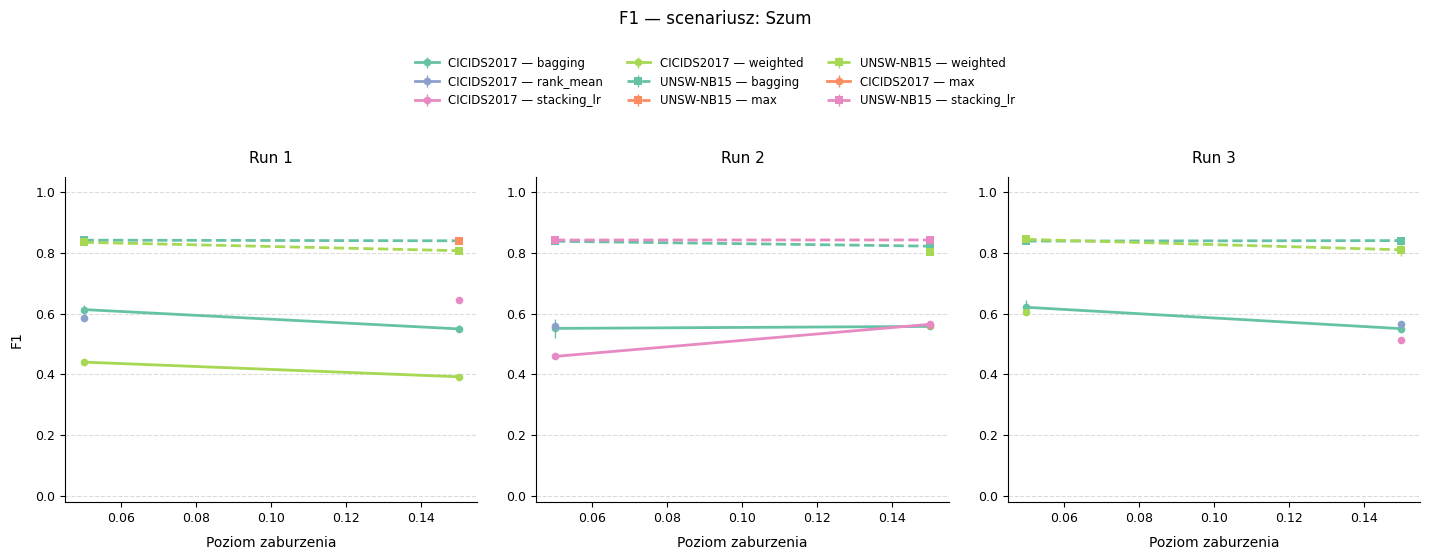

Zapisano: figrobustness-noise-final-precision.pdf oraz figrobustness-noise-final-precision.png


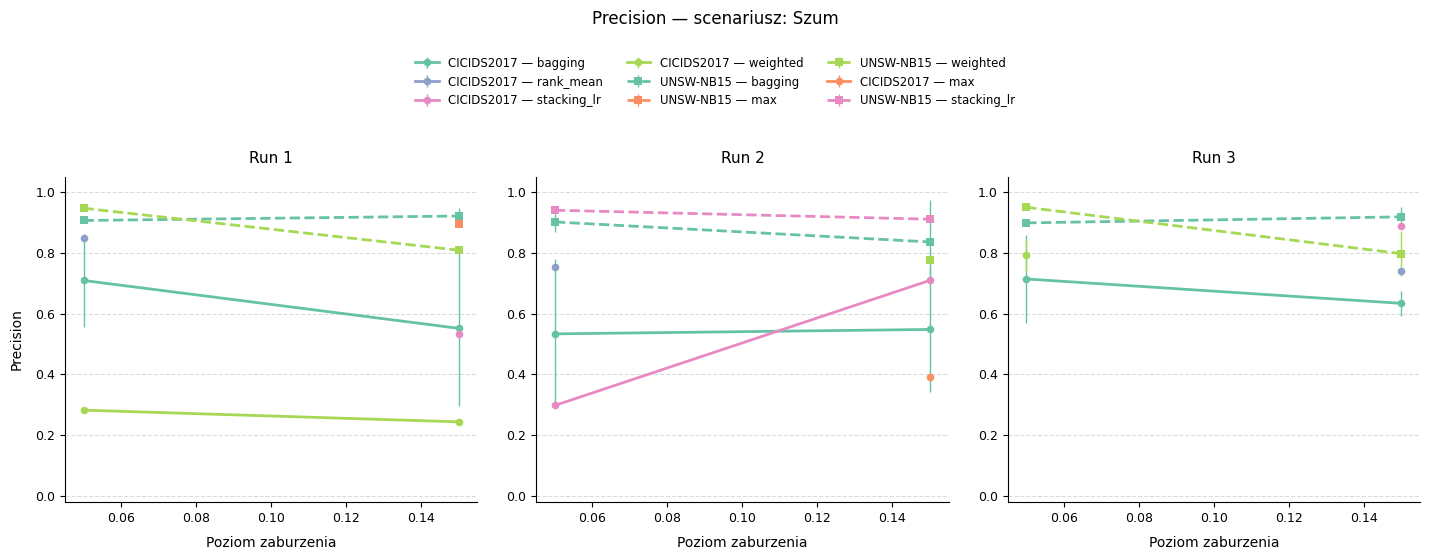

Zapisano: figrobustness-noise-final-recall.pdf oraz figrobustness-noise-final-recall.png


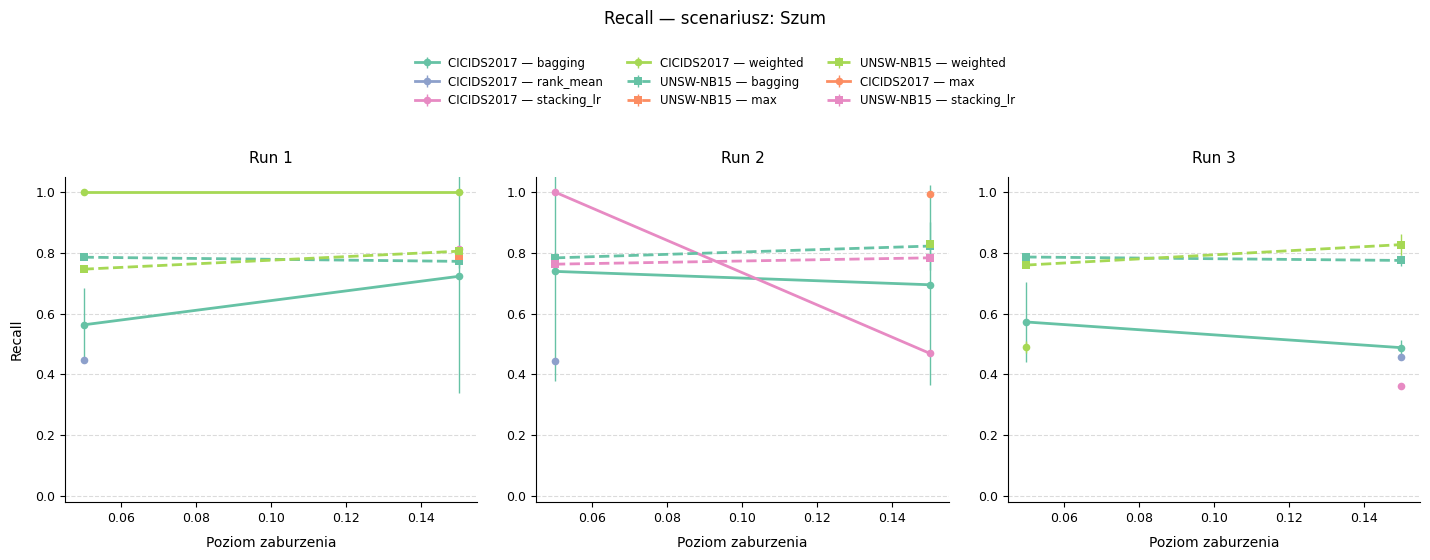

In [69]:
plot_robustness_scenario(
    'Szum',
    'figrobustness-noise-final',
    [
        'AUC_PR',
        'F1',
        'Precision',
        'Recall',
    ],
)

Zapisano: figrobustness-feature-dropout-final-auc-pr.pdf oraz figrobustness-feature-dropout-final-auc-pr.png


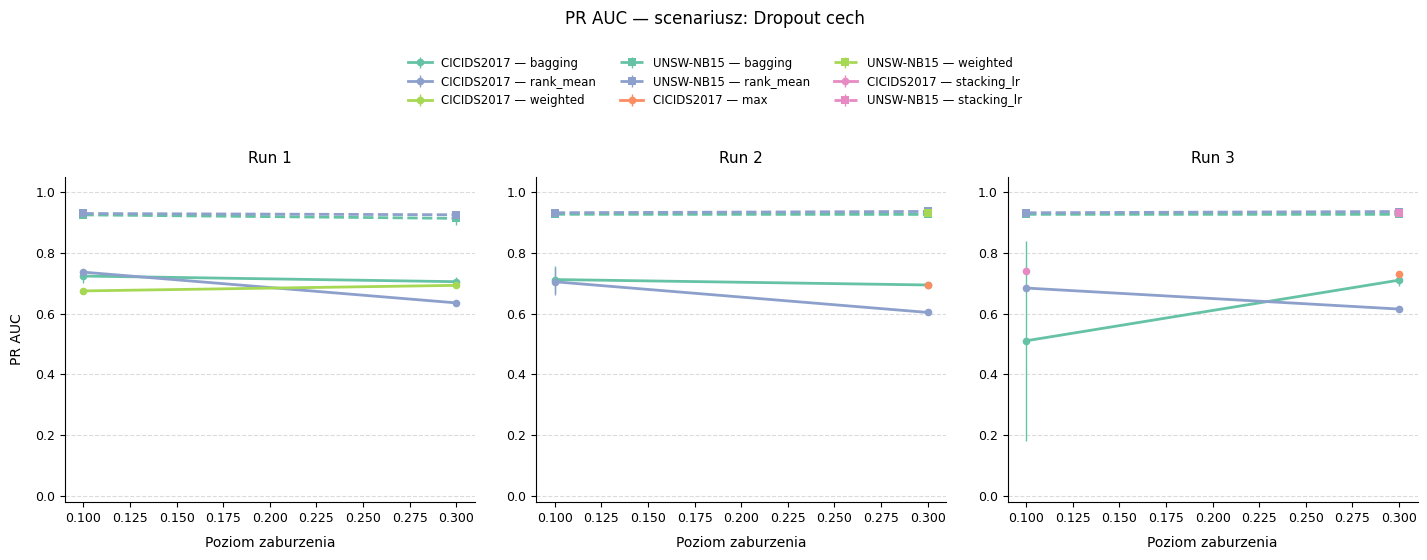

Zapisano: figrobustness-feature-dropout-final-f1.pdf oraz figrobustness-feature-dropout-final-f1.png


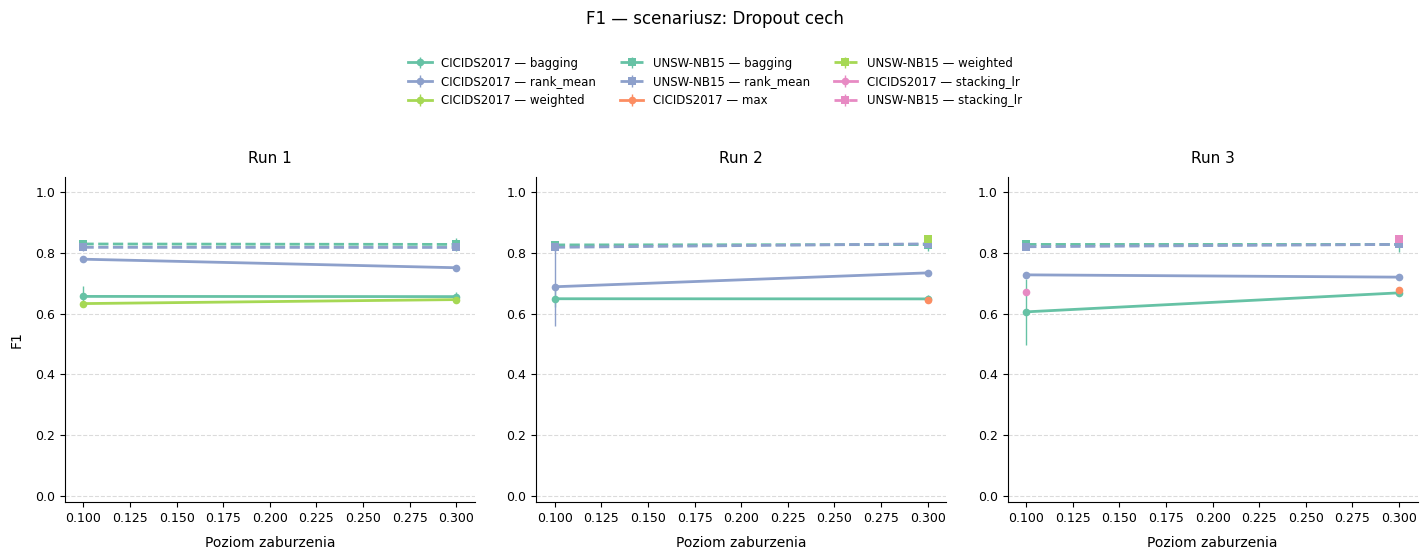

In [70]:
plot_robustness_scenario(
    'Dropout cech',
    'figrobustness-feature-dropout-final',
    [
        'AUC_PR',
        'F1',
    ],
)

#### czas treningu/inferencji modeli pojedynczych


In [73]:
SOLO_RUNTIME_METRICS = [
    'runtime_train',
    'runtime_inference',
]


def metric_stats_between_seeds(
    sub,
    metric,
    allowed_seeds=(29, 81),
):

    if sub.empty or metric not in sub.columns:
        return np.nan, np.nan, 0

    seed_values = sub.copy()

    if 'seed' not in seed_values.columns:
        raise KeyError(
            'Brakuje kolumny "seed", wymaganej do obliczenia '
            'średniej i odchylenia standardowego między seedami.'
        )

    seed_values['seed_num'] = pd.to_numeric(
        seed_values['seed'],
        errors='coerce',
    )

    seed_values = seed_values[
        seed_values['seed_num'].isin(allowed_seeds)
    ].copy()

    seed_values[metric] = pd.to_numeric(
        seed_values[metric],
        errors='coerce',
    )

    seed_means = (
        seed_values
        .dropna(subset=[metric])
        .groupby('seed_num')[metric]
        .mean()
    )

    n_seeds = len(seed_means)

    if n_seeds == 0:
        return np.nan, np.nan, 0

    metric_mean = seed_means.mean()

    metric_std = (
        seed_means.std(ddof=1)
        if n_seeds > 1
        else np.nan
    )

    return metric_mean, metric_std, n_seeds


rows = []

for ds in DATASETS:
    for model, fusion, label in SOLO:
        sub = select(
            df_std_clean,
            ds,
            model,
            fusion,
        ).copy()

        if sub.empty:
            print(
                f'UWAGA: brak danych dla '
                f'{DATASET_LABELS[ds]} — {label}'
            )
            continue

        if 'run_index' not in sub.columns:
            raise KeyError(
                'Brakuje kolumny "run_index" w df_std_clean.'
            )

        available_runs = sorted(
            pd.to_numeric(
                sub['run_index'],
                errors='coerce',
            )
            .dropna()
            .astype(int)
            .unique()
        )

        for run_index in available_runs:
            run_sub = sub[
                pd.to_numeric(
                    sub['run_index'],
                    errors='coerce',
                ).eq(run_index)
            ].copy()

            train_mean, train_std, n_train = (
                metric_stats_between_seeds(
                    run_sub,
                    'runtime_train',
                )
            )

            inference_mean, inference_std, n_inference = (
                metric_stats_between_seeds(
                    run_sub,
                    'runtime_inference',
                )
            )

            n_seeds = min(
                n_train,
                n_inference,
            )

            rows.append(
                {
                    'Zbiór': DATASET_LABELS[ds],
                    'Model': label,
                    'Run': int(run_index),
                    'Czas treningu [s]': pm(
                        train_mean,
                        train_std,
                        nd=1,
                    ),
                    'Czas inferencji [s]': pm(
                        inference_mean,
                        inference_std,
                        nd=1,
                    ),
                }
            )

model_order = {
    label: idx
    for idx, (_, _, label) in enumerate(SOLO)
}

dataset_order = {
    DATASET_LABELS[ds]: idx
    for idx, ds in enumerate(DATASETS)
}

rows = sorted(
    rows,
    key=lambda row: (
        dataset_order.get(row['Zbiór'], 999),
        model_order.get(row['Model'], 999),
        row['Run'],
    ),
)

export_table(
    rows,
    'tab_solo_runtime_by_run_final',
    caption=(
        'Czas treningu i~inferencji modeli pojedynczych. '
        'Dla każdego zbioru, modelu oraz numeru '
        '\\textit{run\\_index} wartości podano jako średnia '
        '$\\pm$ odchylenie standardowe między seedami '
        '$29$ i~$81$.'
    ),
    label='tab:solo-runtime-by-run-final',
)


,Zbiór,Model,Run,Czas treningu [s],Czas inferencji [s]
0,CICIDS2017,Isolation Forest,1,0.7 ± 0.1,1.4 ± 0.3
1,CICIDS2017,Isolation Forest,2,0.6 ± 0.1,1.3 ± 0.3
2,CICIDS2017,Isolation Forest,3,0.6 ± 0.1,1.2 ± 0.4
3,CICIDS2017,LOF,1,7.6 ± 8.4,14.2 ± 15.5
4,CICIDS2017,LOF,2,10.3 ± 0.6,20.0 ± 0.3
5,CICIDS2017,LOF,3,5.5 ± 5.9,10.9 ± 11.6
6,CICIDS2017,One-Class SVM,1,0.8 ± 0.0,1.7 ± 0.0
7,CICIDS2017,One-Class SVM,2,0.8 ± 0.0,1.7 ± 0.1
8,CICIDS2017,One-Class SVM,3,0.8 ± 0.0,1.8 ± 0.0
9,CICIDS2017,LUNAR,1,232.7 ± 56.6,9.6 ± 2.9


\begin{table}[H]
\centering
\caption{Czas treningu i~inferencji modeli pojedynczych. Dla każdego zbioru, modelu oraz numeru \textit{run\_index} wartości podano jako średnia $\pm$ odchylenie standardowe między seedami $29$ i~$81$.}
\label{tab:solo-runtime-by-run-final}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lllcc}
\hline
Zbiór & Model & Run & Czas treningu [s] & Czas inferencji [s] \\
\hline
CICIDS2017 & Isolation Forest & 1 & $0{,}7 \pm 0{,}1$ & $1{,}4 \pm 0{,}3$ \\
CICIDS2017 & Isolation Forest & 2 & $0{,}6 \pm 0{,}1$ & $1{,}3 \pm 0{,}3$ \\
CICIDS2017 & Isolation Forest & 3 & $0{,}6 \pm 0{,}1$ & $1{,}2 \pm 0{,}4$ \\
CICIDS2017 & LOF & 1 & $7{,}6 \pm 8{,}4$ & $14{,}2 \pm 15{,}5$ \\
CICIDS2017 & LOF & 2 & $10{,}3 \pm 0{,}6$ & $20{,}0 \pm 0{,}3$ \\
CICIDS2017 & LOF & 3 & $5{,}5 \pm 5{,}9$ & $10{,}9 \pm 11{,}6$ \\
CICIDS2017 & One-Class SVM & 1 & $0{,}8 \pm 0{,}0$ & $1{,}7 \pm 0{,}0$ \\
CICIDS2017 & One-Class SVM & 2 & $0{,}8 \pm 0{,}0$ & $1{,}7 \pm 0{,}1$ \\
CICIDS2017 & One-Class S

,Zbiór,Model,Run,Czas treningu [s],Czas inferencji [s]
0,CICIDS2017,Isolation Forest,1,0.7 ± 0.1,1.4 ± 0.3
1,CICIDS2017,Isolation Forest,2,0.6 ± 0.1,1.3 ± 0.3
2,CICIDS2017,Isolation Forest,3,0.6 ± 0.1,1.2 ± 0.4
3,CICIDS2017,LOF,1,7.6 ± 8.4,14.2 ± 15.5
4,CICIDS2017,LOF,2,10.3 ± 0.6,20.0 ± 0.3
5,CICIDS2017,LOF,3,5.5 ± 5.9,10.9 ± 11.6
6,CICIDS2017,One-Class SVM,1,0.8 ± 0.0,1.7 ± 0.0
7,CICIDS2017,One-Class SVM,2,0.8 ± 0.0,1.7 ± 0.1
8,CICIDS2017,One-Class SVM,3,0.8 ± 0.0,1.8 ± 0.0
9,CICIDS2017,LUNAR,1,232.7 ± 56.6,9.6 ± 2.9


#### TO USE? koszt vs jakosc - F1 vs czas treningu

In [75]:
from matplotlib.lines import Line2D
import math


MODEL_DISPLAY_NAMES = {
    'IsolationForest': 'Isolation Forest',
    'OneClassSVM': 'One-Class SVM',
    'LOF': 'LOF',
    'LUNAR': 'LUNAR',
    'LUNAR_Epochs': 'LUNAR',
    'LUNAR_Epochs_v2': 'LUNAR',
    'LUNAR_Self_Ensemble': 'LUNAR: self-ensemble',
    'LUNAR_plus_BestBaseline': 'LUNAR + najlepszy model bazowy',
    'Ensemble_with_LUNAR': 'Ensemble z LUNAR',
    'Ensemble_without_LUNAR': 'Ensemble bez LUNAR',
    'Robustness_Analysis': 'Analiza odporności',
    'Fusion_Level_Comparison': 'Porównanie poziomów fuzji',
}


def is_missing_fusion(fusion):
    """
    Zwraca True, gdy fusion_strategy oznacza brak fuzji.
    """
    if pd.isna(fusion):
        return True

    return norm(str(fusion)) in {
        '',
        norm('none'),
        norm('nan'),
        norm('null'),
        norm('brak'),
    }


def shorten_fusion_name(fusion):
    if is_missing_fusion(fusion):
        return None

    fusion = str(fusion)

    replacements = {
        'feature_level_X_plus_lunar_plus_baseline':
            'Fuzja cech: X + LUNAR + baseline',

        'feature_level_X_plus_lunar':
            'Fuzja cech: X + LUNAR',

        'feature_level_X_only':
            'Fuzja cech: X',

        'feature_level_fully':
            'Fuzja cech: pełna',

        'decision_level_AND':
            'Fuzja decyzji: AND',

        'decision_level_OR':
            'Fuzja decyzji: OR',

        'decision_level_weighted':
            'Fuzja decyzji: ważona',

        'score_level':
            'Fuzja wyników',

        'rank_mean':
            'Średnia rang',

        'stacking_lr':
            'Stacking: regresja logistyczna',

        'stacking_rf':
            'Stacking: Random Forest',

        'stacking':
            'Stacking',

        'voting':
            'Voting',

        'bagging':
            'Bagging',

        'boosting':
            'Boosting',

        'max':
            'Maksimum',
    }

    if fusion in replacements:
        return replacements[fusion]

    # Awaryjnie: czytelniejsza wersja technicznej nazwy.
    return (
        fusion
        .replace('_plus_', ' + ')
        .replace('feature_level_', 'Fuzja cech: ')
        .replace('decision_level_', 'Fuzja decyzji: ')
        .replace('score_level', 'Fuzja wyników')
        .replace('_', ' ')
    )


def display_configuration_name(
    model_type,
    fusion_strategy,
):

    model_name = MODEL_DISPLAY_NAMES.get(
        str(model_type),
        str(model_type),
    )

    fusion_name = shorten_fusion_name(
        fusion_strategy
    )

    if fusion_name is None:
        return model_name


    if norm(model_type) == norm(
        'Fusion_Level_Comparison'
    ):
        return fusion_name

    return f'{model_name}: {fusion_name}'


def scatter_cost_vs_quality(
    source=None,
    dataset=None,
    run_index=None,
    title='Koszt treningu vs jakość (F1)',
    stem='fig-cost-vs-quality',
):

    if source is None:
        source = df_std_clean

    required_columns = {
        'dataset_name',
        'model_type',
        'fusion_strategy',
        'run_index',
        'seed',
        'F1',
        'runtime_train',
    }

    missing_columns = required_columns - set(
        source.columns
    )

    if missing_columns:
        raise KeyError(
            'Brakuje wymaganych kolumn: '
            + ', '.join(sorted(missing_columns))
        )

    if dataset is None:
        raise ValueError(
            'Podaj dataset=..., np. dataset="CICIDS2017". '
            'Wykres zbiorczy dla obu zbiorów byłby zbyt gęsty.'
        )

    if run_index is None:
        raise ValueError(
            'Podaj run_index=1, run_index=2 albo run_index=3. '
            'Nie agregujemy automatycznie wyników po run_index.'
        )

    sub = source[
        source['dataset_name'].eq(dataset)
        &
        source['run_index'].eq(run_index)
    ].copy()

    if sub.empty:
        print(
            f'Brak danych dla zbioru {dataset} '
            f'oraz Run {run_index}.'
        )
        return pd.DataFrame()

    # Jeden punkt = średnia tylko między seedami.
    grouped = (
        sub
        .groupby(
            [
                'model_type',
                'fusion_strategy',
            ],
            dropna=False,
        )
        .agg(
            F1_mean=(
                'F1',
                'mean',
            ),
            F1_std=(
                'F1',
                'std',
            ),
            runtime_train_mean=(
                'runtime_train',
                'mean',
            ),
            runtime_train_std=(
                'runtime_train',
                'std',
            ),
            n_seedow=(
                'seed',
                'nunique',
            ),
        )
        .reset_index()
    )

    grouped = grouped.dropna(
        subset=[
            'F1_mean',
            'runtime_train_mean',
        ]
    )

    grouped = grouped[
        grouped['runtime_train_mean'].gt(0)
    ].copy()

    grouped['Nazwa konfiguracji'] = grouped.apply(
        lambda row: display_configuration_name(
            row['model_type'],
            row['fusion_strategy'],
        ),
        axis=1,
    )

    grouped = grouped.sort_values(
        [
            'runtime_train_mean',
            'F1_mean',
        ]
    ).reset_index(
        drop=True
    )

    if grouped.empty:
        print(
            f'Brak poprawnych danych po agregacji dla '
            f'{DATASET_LABELS.get(dataset, dataset)} '
            f'i Run {run_index}.'
        )
        return grouped

    unique_models = list(
        grouped['model_type']
        .dropna()
        .unique()
    )

    color_map = {
        model: COLORS[
            idx % len(COLORS)
        ]
        for idx, model in enumerate(unique_models)
    }

    unique_fusions = list(
        grouped['fusion_strategy']
        .fillna('__BRAK_FUZJI__')
        .unique()
    )

    marker_cycle = [
        'o',
        's',
        '^',
        'D',
        'P',
        'X',
        'v',
        '<',
        '>',
        'h',
        '*',
    ]

    marker_map = {
        fusion: marker_cycle[
            idx % len(marker_cycle)
        ]
        for idx, fusion in enumerate(unique_fusions)
    }

    n_entries = len(grouped)

    n_legend_columns = min(
        4,
        max(1, n_entries),
    )

    n_legend_rows = math.ceil(
        n_entries / n_legend_columns
    )

    figure_height = max(
        7.2,
        6.0 + 0.24 * n_legend_rows,
    )

    legend_bottom_space = min(
        0.42,
        0.08 + 0.045 * n_legend_rows,
    )

    fig, ax = plt.subplots(
        figsize=(11.5, figure_height)
    )

    legend_handles = []
    legend_labels = []

    for _, row in grouped.iterrows():
        fusion_key = (
            row['fusion_strategy']
            if pd.notna(row['fusion_strategy'])
            else '__BRAK_FUZJI__'
        )

        point_color = color_map[
            row['model_type']
        ]

        point_marker = marker_map[
            fusion_key
        ]

        ax.scatter(
            row['runtime_train_mean'],
            row['F1_mean'],
            s=88,
            color=point_color,
            marker=point_marker,
            edgecolor='#404040',
            linewidth=0.65,
            alpha=0.9,
            zorder=3,
        )

        configuration_label = row[
            'Nazwa konfiguracji'
        ]

        legend_handles.append(
            Line2D(
                [],
                [],
                linestyle='None',
                marker=point_marker,
                markersize=7.5,
                markerfacecolor=point_color,
                markeredgecolor='#404040',
                markeredgewidth=0.65,
            )
        )

        legend_labels.append(
            configuration_label
        )

    ax.set_xscale('log')

    ax.set_xlabel(
        'Średni czas treningu [s] (skala log)',
        fontsize=11,
        labelpad=8,
    )

    ax.set_ylabel(
        'F1 (próg standardowy)',
        fontsize=11,
        labelpad=8,
    )

    ax.set_title(
        (
            f'{title} — '
            f'{DATASET_LABELS.get(dataset, dataset)}, '
            f'Run {int(run_index)}'
        ),
        fontsize=12,
        pad=12,
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)

    ax.yaxis.grid(
        True,
        linestyle='--',
        alpha=0.4,
        zorder=0,
    )

    ax.xaxis.grid(
        True,
        which='major',
        linestyle=':',
        alpha=0.35,
        zorder=0,
    )

    ax.set_axisbelow(True)

    fig.legend(
        legend_handles,
        legend_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.01),
        ncol=n_legend_columns,
        frameon=True,
        facecolor='white',
        edgecolor='#D0D0D0',
        fontsize=7.5,
        handletextpad=0.45,
        columnspacing=1.2,
    )

    fig.tight_layout(
        rect=(
            0.03,
            legend_bottom_space,
            0.98,
            0.96,
        )
    )

    dataset_suffix = DATASET_SUFFIX.get(
        dataset,
        norm(dataset),
    )

    output_name = (
        f'{stem}-'
        f'{dataset_suffix}-'
        f'run{int(run_index)}'
    )

    savefig(
        fig,
        output_name,
    )

    plt.show()

    return grouped

Zapisano: fig-cost-vs-quality-main-cicids-run1.pdf oraz fig-cost-vs-quality-main-cicids-run1.png


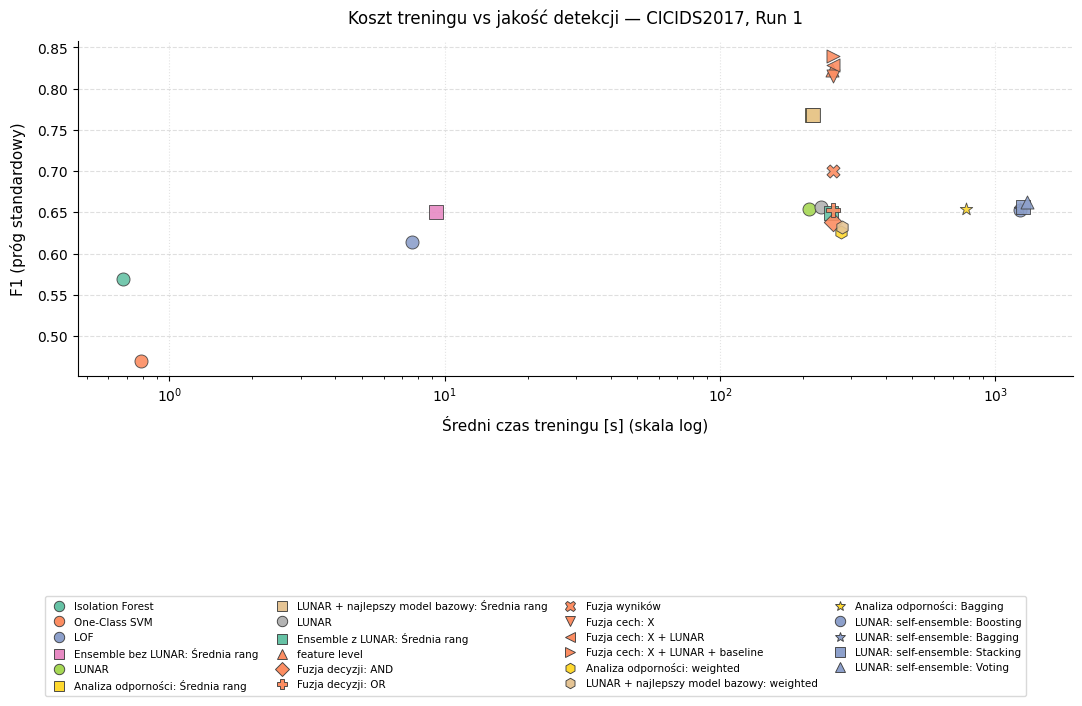

Zapisano: fig-cost-vs-quality-main-unsw-run1.pdf oraz fig-cost-vs-quality-main-unsw-run1.png


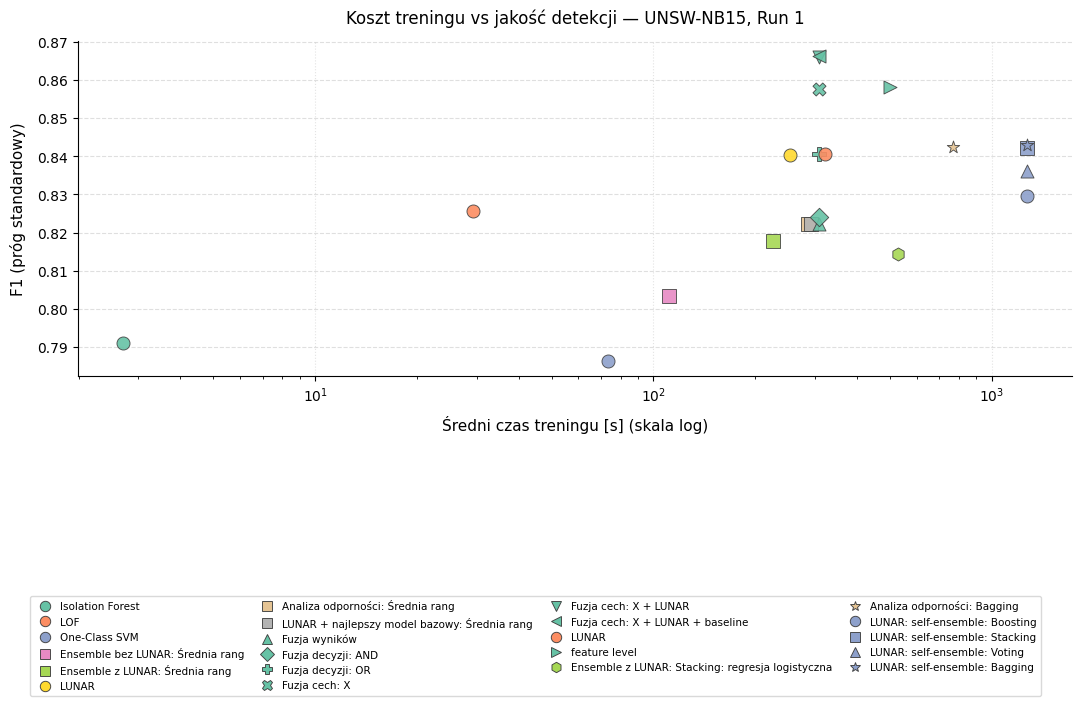

In [78]:
for _ds in DATASETS:
    _ = scatter_cost_vs_quality(
        source=df_std_clean,
        dataset=_ds,
        run_index=1,
        title='Koszt treningu vs jakość detekcji',
        stem='fig-cost-vs-quality-main',
    )